## Import libraries and dataframes and define paths

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import pandas as pd
import sys
import os
from plots import *
import warnings
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import seaborn as sns
from scipy import stats

attr_path = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\avr_attrs'
spont_attr_path = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\avr_attrs_spont'
r2_scores_path = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\r2_all'
spectral_r2_scores_path = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\spectral_R2_analysis_all'

df = pd.read_csv('tables/units_info.csv')
units_all = pd.read_csv(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\units.csv')
borders   = pd.read_csv('tables/layer_4_borders.csv')
visp_depths = pd.read_csv('tables/VISp_depths.csv')
all_ses = visp_depths['session'].unique().tolist()

print(units_all.head())
print(borders.head())
print(visp_depths.head())
chans2keep = 16
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]

figures_folder = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\models\figures'

# channels = pd.read_csv(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\visual-behavior-neuropixels-0.4.0\project_metadata\channels.csv')

      unit_id  ecephys_channel_id  ecephys_probe_id  ecephys_session_id  \
0  1157005856          1157001834        1046469925          1046166369   
1  1157005853          1157001834        1046469925          1046166369   
2  1157005720          1157001786        1046469925          1046166369   
3  1157006074          1157001929        1046469925          1046166369   
4  1157006072          1157001929        1046469925          1046166369   

   amplitude_cutoff  anterior_posterior_ccf_coordinate  \
0          0.500000                             8453.0   
1          0.323927                             8453.0   
2          0.044133                             8575.0   
3          0.000583                             8212.0   
4          0.500000                             8212.0   

   dorsal_ventral_ccf_coordinate  left_right_ccf_coordinate  cumulative_drift  \
0                         3353.0                     6719.0            140.32   
1                         3353.0      

## Define middle layers borders

In [ ]:
for i, row in borders.iterrows():
    session = row['session']
    
    if session in visp_depths['session']  .unique():
        ses_chans = visp_depths[visp_depths['session'] == session]
        upper_border_index = np.where(ses_chans['depths'] == row['upper'])[0][0]
        lower_border_index = np.where(ses_chans['depths'] == row['lower'])[0][0]
        
        num_channels = len(ses_chans)
        
        # CORRECTED: 
        # Most superficial channel (highest index) = upper_border + 5
        # Deepest channel (lowest index) = upper_border - 10
        most_superficial_index = np.min((num_channels - 1, upper_border_index + 5))
        deepest_index = np.max((0, upper_border_index - 10))
        
        # For array slicing: first_channel should be the LOWER index (deeper)
        first_channel_index = deepest_index  # This is upper_border - 10
        last_channel_index = most_superficial_index  # This is upper_border + 5
        
        # Calculate start_index for alignment
        start_index = 0 if upper_border_index - 10 >= 0 else 10 - upper_border_index
        
        # Update borders table
        borders.at[i, 'upper_border_index'] = int(upper_border_index)
        borders.at[i, 'lower_border_index'] = int(lower_border_index)
        borders.at[i, 'first_channel_index'] = int(first_channel_index)  # Deepest (lower index)
        borders.at[i, 'last_channel_index'] = int(last_channel_index)    # Most superficial (higher index)
        borders.at[i, 'start_index'] = int(start_index)
  
cols = borders.columns.tolist()
for col in cols:
    borders[col] = borders[col].astype('Int64')
    
print(borders.head())
# get the average numer of channels between the upper and lower borders
print('Average number of channels between upper and lower borders:',
      int(np.ceil(np.mean(borders['upper_border_index'] - borders['lower_border_index']))))



      session  upper  lower  upper_border_index  lower_border_index  \
0  1047969464    870    999                  11                   9   
1  1048189115    878   1082                  12                   8   
2  1049273528   1022   1126                  16                  14   
3  1049514117    953   1142                  18                  14   
4  1051155866    726    925                  18                  13   

   first_channel_index  last_channel_index  start_index  
0                    1                  15            0  
1                    2                  17            0  
2                    6                  21            0  
3                    8                  22            0  
4                    8                  23            0  
Average number of channels between upper and lower borders: 3


## Trim the attribution matrices according to the bordes and save in a dictionary where the keys are the session numbers

In [109]:
avr_attr_trimmed = {}
avr_attr_spont_trimmed = {}

for i, row in borders.iterrows():
    session = row['session']
    if session in visp_depths['session'].unique():
        # load the attribution matrix
        attr_file       = Path(attr_path) / f'{session}_attribution_scores_relative_mean.npy'
        attr_file_spont = Path(spont_attr_path) / f'{session}_attribution_scores_mean.npy'

        if attr_file.exists():
            attr       = np.load(attr_file)
            attr_spont = np.load(attr_file_spont)
            
            # Handle potential size mismatch
            num_chans_attr = attr.shape[0]
            num_chans_tbl = len(visp_depths[visp_depths['session'] == session])
            if num_chans_attr > num_chans_tbl:
                diff = num_chans_attr - num_chans_tbl
                attr = attr[:-diff, :, :]
                attr_spont = attr_spont[:-diff, :, :]
                
            # Get indices (CORRECTED - no +1)
            start_index = row['start_index']
            first_channel_index = row['first_channel_index']
            last_channel_index = row['last_channel_index']  # Remove the +1
            
            # Calculate actual number of channels to copy (inclusive range)
            available_channels = attr.shape[0]
            channels_to_copy = last_channel_index - first_channel_index + 1  # +1 for inclusive
            
            # Ensure we don't exceed source array bounds
            if first_channel_index + channels_to_copy > available_channels:
                channels_to_copy = available_channels - first_channel_index
                
            # Ensure we don't exceed target array bounds  
            if start_index + channels_to_copy > chans2keep:
                channels_to_copy = chans2keep - start_index
            
            # Initialize output arrays
            trimmed = np.full((chans2keep, len(bands)+1, attr.shape[2]), np.nan)
            trimmed_spont = np.full((chans2keep, len(bands)+1, attr_spont.shape[2]), np.nan)
            
            # Copy the data with bounds checking
            if channels_to_copy > 0:
                trimmed[start_index:start_index + channels_to_copy, :, :] = \
                    attr[first_channel_index:first_channel_index + channels_to_copy, :, :]
                trimmed_spont[start_index:start_index + channels_to_copy, :, :] = \
                    attr_spont[first_channel_index:first_channel_index + channels_to_copy, :, :]
            
            avr_attr_trimmed[session] = trimmed
            avr_attr_spont_trimmed[session] = trimmed_spont

## Load the r2 scores and trim them according to the borders like the attribution scores

In [108]:
r2_scores = {}
r2_scores_spontaneous = {}
r2_scores_passive = {}

for i, row in borders.iterrows():
    session = row['session']
    if session in visp_depths['session'].unique():
        r2_file = Path(r2_scores_path) / f'{session}_r2_scores.npy'
        r2_file_spont = Path(r2_scores_path) / f'{session}_r2_scores_spont.npy'
        r2_file_passive = Path(r2_scores_path) / f'{session}_r2_scores_passive.npy'
        
        if r2_file.exists():
            r2 = np.load(r2_file)
            r2_spont = np.load(r2_file_spont)
            r2_passive = np.load(r2_file_passive)
            num_chans_r2 = r2.shape[0]
            num_chans_tbl = len(visp_depths[visp_depths['session'] == session])
            if num_chans_r2 > num_chans_tbl:
                diff = num_chans_r2 - num_chans_tbl
                # trim the last diff channels
                r2 = r2[:-diff, :]
                r2_spont = r2_spont[:-diff, :]
                r2_passive = r2_passive[:-diff, :]
            start_index = row['start_index']
            first_channel_index = row['first_channel_index']
            last_channel_index  = row['last_channel_index'] + 1
            trimmed = np.full((chans2keep, len(bands)+1), np.nan)
            trimmed_spont = np.full((chans2keep, len(bands)+1), np.nan)
            trimmed_passive = np.full((chans2keep, len(bands)+1), np.nan)
            m = np.min((last_channel_index, r2[first_channel_index:last_channel_index, :].shape[0]))
            trimmed[start_index:start_index + m,:] = r2[first_channel_index:last_channel_index, :]
            trimmed_spont[start_index:start_index + m,:] = r2_spont[first_channel_index:last_channel_index, :]
            trimmed_passive[start_index:start_index + m,:] = r2_passive[first_channel_index:last_channel_index, :]
            r2_scores[session] = trimmed
            r2_scores_spontaneous[session] = trimmed_spont
            r2_scores_passive[session] = trimmed_passive

## load the spectral r2 scores, saved in csv files with colummns channel_0, channel_1, channel_2 etc and index as frequency bands + broadband


In [ ]:
spectral_r2_scores = {}
spectral_r2_cortex = {}
spectral_r2_cortex_no_visp = {}
spectral_r2_hpc = {}
spectral_r2_subcortical = {}

for i, row in borders.iterrows():
    session = row['session']
    if session in visp_depths['session'].unique():
        spectral_r2_file = Path(spectral_r2_scores_path, f'session_{session}_r2_results_full_model.csv')
        spectral_r2_cortex_file = Path(spectral_r2_scores_path, f'session_{session}_r2_results_cortex.csv')
        spectral_r2_cortex_no_visp_file = Path(spectral_r2_scores_path, f'session_{session}_r2_results_cortex_no_visp.csv')
        spectral_r2_hpc_file = Path(spectral_r2_scores_path, f'session_{session}_r2_results_hpc.csv')
        spectral_r2_subcortical_file = Path(spectral_r2_scores_path, f'session_{session}_r2_results_subcortical.csv')
        
        if spectral_r2_file.exists():
            spectral_r2_df = pd.read_csv(spectral_r2_file, index_col=0)
            spectral_r2_cortex_df = pd.read_csv(spectral_r2_cortex_file, index_col=0)
            spectral_r2_cortex_no_visp_df = pd.read_csv(spectral_r2_cortex_no_visp_file, index_col=0)
            spectral_r2_hpc_df = pd.read_csv(spectral_r2_hpc_file, index_col=0)
            spectral_r2_subcortical_df = pd.read_csv(spectral_r2_subcortical_file, index_col=0)
            
            # Handle potential size mismatch
            num_chans_spectral = spectral_r2_df.shape[1]
            num_chans_tbl = len(visp_depths[visp_depths['session'] == session])
            if num_chans_spectral > num_chans_tbl:
                diff = num_chans_spectral - num_chans_tbl
                spectral_r2_df = spectral_r2_df.iloc[:, :-diff]
                spectral_r2_cortex_df = spectral_r2_cortex_df.iloc[:, :-diff]
                spectral_r2_cortex_no_visp_df = spectral_r2_cortex_no_visp_df.iloc[:, :-diff]
                spectral_r2_hpc_df = spectral_r2_hpc_df.iloc[:, :-diff]
                spectral_r2_subcortical_df = spectral_r2_subcortical_df.iloc[:, :-diff]
            
            # Get indices (CORRECTED - no +1)
            start_index = row['start_index']
            first_channel_index = row['first_channel_index']
            last_channel_index = row['last_channel_index']  
            
            # Calculate actual number of channels to copy
            available_channels = spectral_r2_df.shape[1]
            channels_to_copy = last_channel_index - first_channel_index +1
            
            # Ensure we don't exceed source array bounds
            if first_channel_index + channels_to_copy > available_channels:
                channels_to_copy = available_channels - first_channel_index
                
            # Ensure we don't exceed target array bounds  
            if start_index + channels_to_copy > chans2keep:
                channels_to_copy = chans2keep - start_index
            
            # Initialize output arrays
            trimmed = np.full((7, chans2keep), np.nan)
            trimmed_cortex = np.full((7, chans2keep), np.nan)
            trimmed_cortex_no_visp = np.full((7, chans2keep), np.nan)
            trimmed_hpc = np.full((7, chans2keep), np.nan)
            trimmed_subcortical = np.full((7, chans2keep), np.nan)
            
            # Copy the data with bounds checking
            if channels_to_copy > 0:
                trimmed[:, start_index:start_index + channels_to_copy] = \
                    spectral_r2_df.iloc[:, first_channel_index:first_channel_index + channels_to_copy].values
                trimmed_cortex[:, start_index:start_index + channels_to_copy] = \
                    spectral_r2_cortex_df.iloc[:, first_channel_index:first_channel_index + channels_to_copy].values
                trimmed_cortex_no_visp[:, start_index:start_index + channels_to_copy] = \
                    spectral_r2_cortex_no_visp_df.iloc[:, first_channel_index:first_channel_index + channels_to_copy].values
                trimmed_hpc[:, start_index:start_index + channels_to_copy] = \
                    spectral_r2_hpc_df.iloc[:, first_channel_index:first_channel_index + channels_to_copy].values
                trimmed_subcortical[:, start_index:start_index + channels_to_copy] = \
                    spectral_r2_subcortical_df.iloc[:, first_channel_index:first_channel_index + channels_to_copy].values
            
            spectral_r2_scores[session] = trimmed
            spectral_r2_cortex[session] = trimmed_cortex
            spectral_r2_cortex_no_visp[session] = trimmed_cortex_no_visp
            spectral_r2_hpc[session] = trimmed_hpc
            spectral_r2_subcortical[session] = trimmed_subcortical

C:\Users\SB13FLPC018\AppData\Local\Temp\ipykernel_3680\4159179166.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\SB13FLPC018\AppData\Local\Temp\ipykernel_3680\4159179166.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45, ha='right')


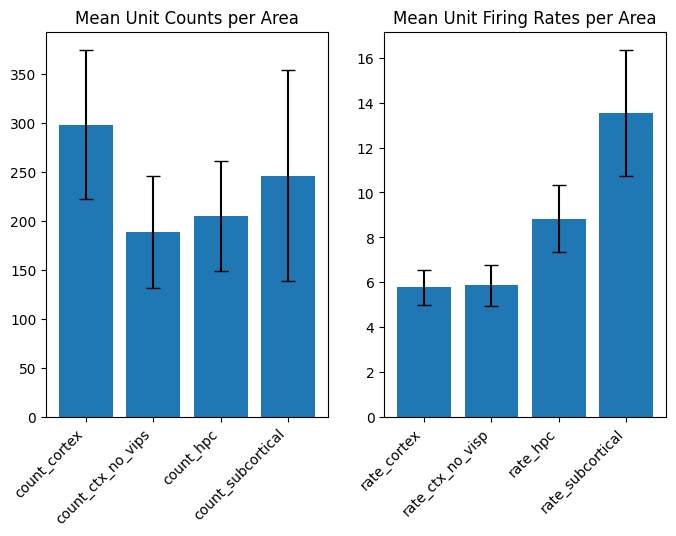

In [150]:
# for each session, load the unit count and avg firing rate per area
# initizlize a dataframe with sessions as index, and columns: count_cortex, count_ctx_no_vips, count_hpc,
#  count_subcortical, rate_cortex, rate__ctx_no_vips rate_hpc, rate_subcortical
area_unit_stats = pd.DataFrame(columns=[
    'count_cortex', 'count_ctx_no_vips', 'count_hpc', 'count_subcortical',
    'rate_cortex', 'rate_ctx_no_visp', 'rate_hpc', 'rate_subcortical'
], index=all_ses)

for session in all_ses:
    ses_df_path = Path(spectral_r2_scores_path, f'session_{session}_units_counts_and_rates.csv')
    if ses_df_path.exists():
        ses_df = pd.read_csv(ses_df_path, index_col=0)
        area_unit_stats.at[session, 'count_cortex'] = ses_df.loc['cortex', 'num_units']
        area_unit_stats.at[session, 'count_ctx_no_vips'] = ses_df.loc['cortex_no_visp', 'num_units']
        area_unit_stats.at[session, 'count_hpc'] = ses_df.loc['hippocampus', 'num_units']
        area_unit_stats.at[session, 'count_subcortical'] = ses_df.loc['subcortical', 'num_units']
        area_unit_stats.at[session, 'rate_cortex'] = ses_df.loc['cortex', 'mean_firing_rate']
        area_unit_stats.at[session, 'rate_ctx_no_visp'] = ses_df.loc['cortex_no_visp', 'mean_firing_rate']
        area_unit_stats.at[session, 'rate_hpc'] = ses_df.loc['hippocampus', 'mean_firing_rate']
        area_unit_stats.at[session, 'rate_subcortical'] = ses_df.loc['subcortical', 'mean_firing_rate']
        
# print(area_unit_stats.head())

# compute the mean count and rate per area across sessions
mean_area_unit_stats = area_unit_stats.mean() # type: ignore
std_area_unit_stats = area_unit_stats.std()
# print(mean_area_unit_stats)
# print(std_area_unit_stats)

# plot the mean and std of unit counts and rates per area as a bar plot with error bars
fig, axs = plt.subplots(1, 2, figsize=(8, 5))
axs[0].bar(mean_area_unit_stats.index[:4], mean_area_unit_stats.values[:4], yerr=std_area_unit_stats.values[:4], capsize=5)
axs[0].set_title('Mean Unit Counts per Area')
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45, ha='right')
axs[1].bar(mean_area_unit_stats.index[4:], mean_area_unit_stats.values[4:], yerr=std_area_unit_stats.values[4:], capsize=5)
axs[1].set_title('Mean Unit Firing Rates per Area')
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45, ha='right')
plt.show()
    

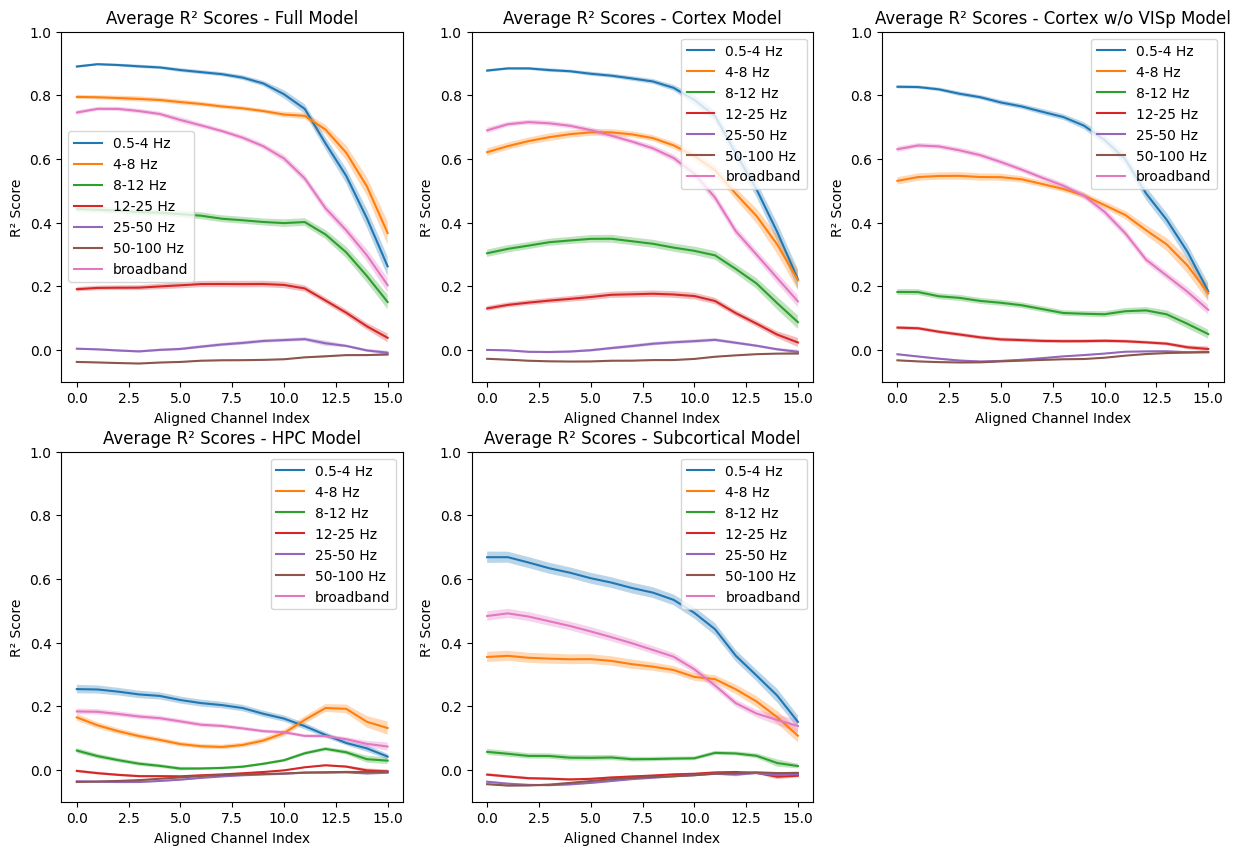

In [107]:
r2_full_all = np.zeros((len(spectral_r2_scores), 7,chans2keep))
for i, r2 in enumerate(spectral_r2_scores.items()):
    r2_full_all[i,:,:] = r2[1]
r2_avg = np.nanmean(r2_full_all, axis=0)
r2_avg_se = stats.sem(r2_full_all, axis=0, nan_policy='omit')

r2_cortex_all = np.zeros((len(spectral_r2_cortex), 7,chans2keep))
for i, r2 in enumerate(spectral_r2_cortex.items()):
    r2_cortex_all[i,:,:] = r2[1]
r2_cortex_avg = np.nanmean(r2_cortex_all, axis=0)
r2_cortex_avg_se = stats.sem(r2_cortex_all, axis=0, nan_policy='omit')

r2_cortex_no_visp_all = np.zeros((len(spectral_r2_cortex_no_visp), 7,chans2keep))
for i, r2 in enumerate(spectral_r2_cortex_no_visp.items()):
    r2_cortex_no_visp_all[i,:,:] = r2[1]
r2_cortex_no_visp_avg = np.nanmean(r2_cortex_no_visp_all, axis=0)
r2_cortex_no_visp_avg_se = stats.sem(r2_cortex_no_visp_all, axis=0, nan_policy='omit')

r2_hpc_all = np.zeros((len(spectral_r2_hpc), 7,chans2keep))
for i, r2 in enumerate(spectral_r2_hpc.items()):
    r2_hpc_all[i,:,:] = r2[1]
r2_hpc_avg = np.nanmean(r2_hpc_all, axis=0)
r2_hpc_avg_se = stats.sem(r2_hpc_all, axis=0, nan_policy='omit')

r2_subcortical_all = np.zeros((len(spectral_r2_subcortical), 7,chans2keep))
for i, r2 in enumerate(spectral_r2_subcortical.items()):
    r2_subcortical_all[i,:,:] = r2[1]
r2_subcortical_avg = np.nanmean(r2_subcortical_all, axis=0)
r2_subcortical_avg_se = stats.sem(r2_subcortical_all, axis=0, nan_policy='omit')

# for each model (full, cortex, cortex w/o visp, hpc, subcortical), plot the average r2 scores for each frequency band (0.5-4 Hz, 4-8 Hz, 8-12 Hz
#12-25 Hz, 25-50 Hz, 50-100 Hz, broadband) the shape of the r2_avg is (7, chans2keep)
frequency_band_names = ['0.5-4 Hz', '4-8 Hz', '8-12 Hz', '12-25 Hz', '25-50 Hz', '50-100 Hz', 'broadband']
channel_indices = np.arange(chans2keep)
models = ['Full Model', 'Cortex Model', 'Cortex w/o VISp Model', 'HPC Model', 'Subcortical Model']
plt.figure(figsize=(15,10))
for i in range(len(models)):
    plt.subplot(2,3,i+1)
    if models[i] == 'Full Model':
        r2_avg_plot = r2_avg
        r2_se_plot = r2_avg_se
    elif models[i] == 'Cortex Model':
        r2_avg_plot = r2_cortex_avg
        r2_se_plot = r2_cortex_avg_se
    elif models[i] == 'Cortex w/o VISp Model':
        r2_avg_plot = r2_cortex_no_visp_avg
        r2_se_plot = r2_cortex_no_visp_avg_se
    elif models[i] == 'HPC Model':
        r2_avg_plot = r2_hpc_avg
        r2_se_plot = r2_hpc_avg_se
    elif models[i] == 'Subcortical Model':
        r2_avg_plot = r2_subcortical_avg
        r2_se_plot = r2_subcortical_avg_se
        
    for j in range(r2_avg_plot.shape[0]):
        plt.plot(channel_indices, r2_avg_plot[j,:], label=frequency_band_names[j])
        plt.fill_between(channel_indices, 
                         r2_avg_plot[j,:] - r2_se_plot[j,:],
                         r2_avg_plot[j,:] + r2_se_plot[j,:],
                         alpha=0.3)
    plt.title(f'Average R² Scores - {models[i]}')
    plt.xlabel('Aligned Channel Index')
    plt.ylabel('R² Score')
    plt.ylim(-0.1, 1)
    plt.legend()


## Average r2 scores across all sessions


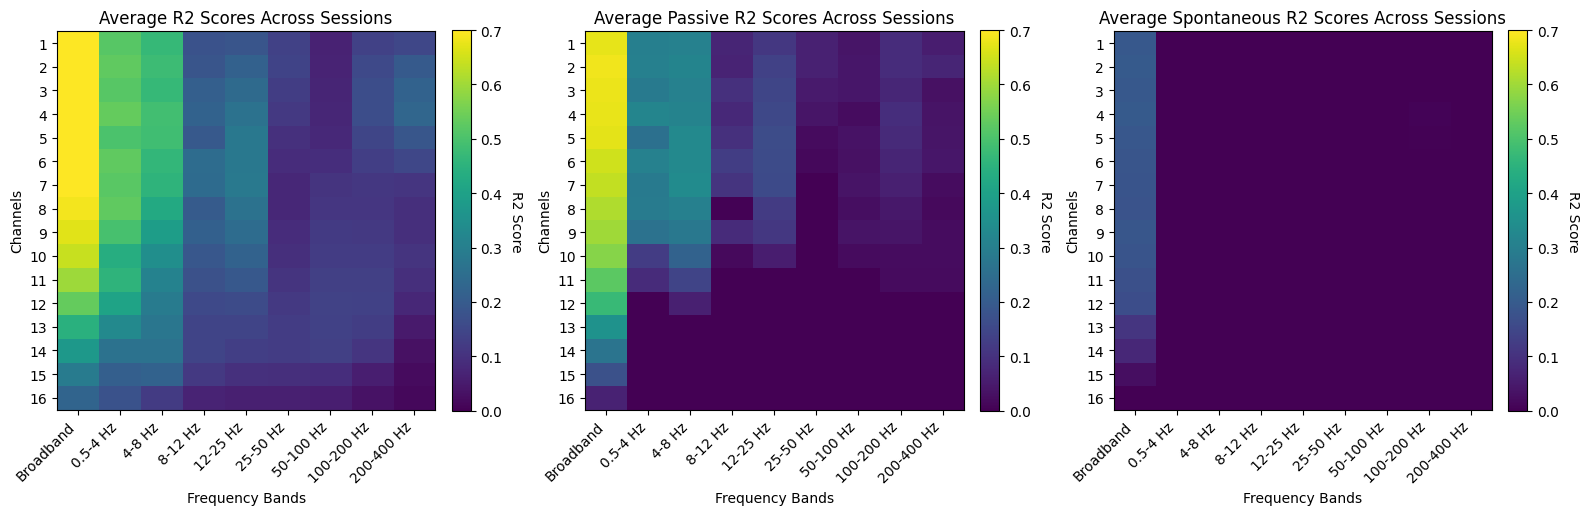

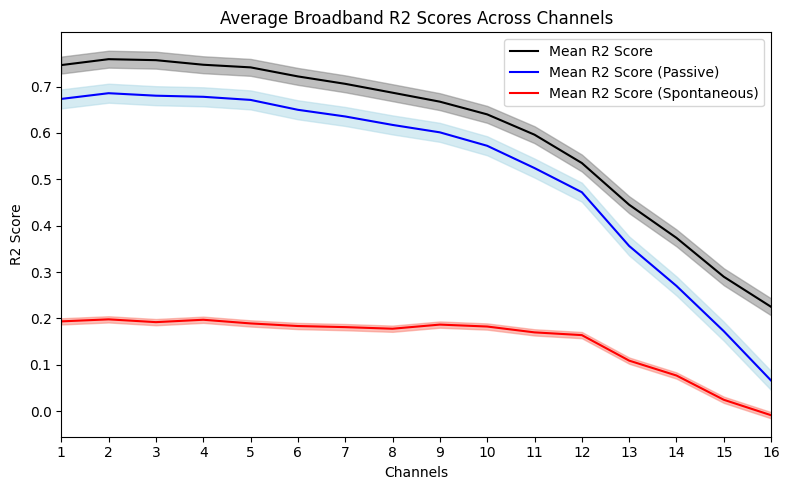

In [110]:
r2_avg = np.zeros((len(r2_scores) ,chans2keep, len(bands)+1))
for i, r2 in enumerate(r2_scores.items()):
    r2_avg[i,:,:] = r2[1]
r2_avg = np.nanmean(r2_avg, axis=0)

r2_passive_avg = np.zeros((len(r2_scores_passive) ,chans2keep, len(bands)+1))
for i, r2 in enumerate(r2_scores_passive.items()):
    r2_passive_avg[i,:,:] = r2[1]
r2_passive_avg = np.nanmean(r2_passive_avg, axis=0)

r2_spont_avg = np.zeros((len(r2_scores_spontaneous) ,chans2keep, len(bands)+1))
for i, r2 in enumerate(r2_scores_spontaneous.items()):
    r2_spont_avg[i,:,:] = r2[1]
r2_spont_avg = np.nanmean(r2_spont_avg, axis=0)

# plot the average r2 scores
fig, ax = plt.subplots(1, 3, figsize=(16, 10))
ax[0].imshow(r2_avg, aspect='auto', cmap='viridis', vmin=0, vmax=.7)
ax[0].set_title('Average R2 Scores Across Sessions')
ax[0].set_xlabel('Frequency Bands')
ax[0].set_ylabel('Channels')
ax[0].set_xticks(np.arange(len(bands)+1))
ax[0].set_xticklabels(['Broadband'] + [f'{band[0]}-{band[1]} Hz' for band in bands], rotation=45, ha='right')
ax[0].set_yticks(np.arange(chans2keep))
ax[0].set_yticklabels(np.arange(1, chans2keep + 1), rotation=0)
ax[0].set_aspect(1.0/ax[0].get_data_ratio(), adjustable='box')
cbar = plt.colorbar(ax[0].images[0], ax=ax[0], orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('R2 Score', rotation=270, labelpad=15)

ax[1].imshow(r2_passive_avg, aspect='auto', cmap='viridis', vmin=0, vmax=.7)
ax[1].set_title('Average Passive R2 Scores Across Sessions')
ax[1].set_xlabel('Frequency Bands')
ax[1].set_ylabel('Channels')
ax[1].set_xticks(np.arange(len(bands)+1))
ax[1].set_xticklabels(['Broadband'] + [f'{band[0]}-{band[1]} Hz' for band in bands], rotation=45, ha='right')
ax[1].set_yticks(np.arange(chans2keep))
ax[1].set_yticklabels(np.arange(1, chans2keep + 1), rotation=0)
ax[1].set_aspect(1.0/ax[1].get_data_ratio(), adjustable='box')
cbar = plt.colorbar(ax[1].images[0], ax=ax[1], orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('R2 Score', rotation=270, labelpad=15)

ax[2].imshow(r2_spont_avg, aspect='auto', cmap='viridis', vmin=0, vmax=.7)
ax[2].set_title('Average Spontaneous R2 Scores Across Sessions')
ax[2].set_xlabel('Frequency Bands')
ax[2].set_ylabel('Channels')
ax[2].set_xticks(np.arange(len(bands)+1))
ax[2].set_xticklabels(['Broadband'] + [f'{band[0]}-{band[1]} Hz' for band in bands], rotation=45, ha='right')
ax[2].set_yticks(np.arange(chans2keep))
ax[2].set_yticklabels(np.arange(1, chans2keep + 1), rotation=0)
ax[2].set_aspect(1.0/ax[2].get_data_ratio(), adjustable='box')
cbar = plt.colorbar(ax[2].images[0], ax=ax[2], orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('R2 Score', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

# add a plot for just the broadband r2 scores across channels with mean and std shading
mean_r2_broadband = r2_avg[:,0]
sem_r2_broadband = np.nanstd(r2_avg[:,0], axis=0) / np.sqrt(len(r2_scores))
mean_r2_passive = r2_passive_avg[:,0]
sem_r2_passive = np.nanstd(r2_passive_avg[:,0], axis=0) / np.sqrt(len(r2_scores_passive))
mean_r2_spont = r2_spont_avg[:,0]
sem_r2_spont = np.nanstd(r2_spont_avg[:,0], axis=0) / np.sqrt(len(r2_scores_spontaneous))


fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(1, chans2keep + 1), mean_r2_broadband, 'k-', label='Mean R2 Score')
ax.fill_between(np.arange(1, chans2keep + 1),
                mean_r2_broadband - sem_r2_broadband,
                mean_r2_broadband + sem_r2_broadband,
                color='gray', alpha=0.5)

ax.plot(np.arange(1, chans2keep + 1), mean_r2_passive, 'b-', label='Mean R2 Score (Passive)')
ax.fill_between(np.arange(1, chans2keep + 1),
                mean_r2_passive - sem_r2_passive,
                mean_r2_passive + sem_r2_passive,
                color='lightblue', alpha=0.5)
ax.plot(np.arange(1, chans2keep + 1), mean_r2_spont, 'r-', label='Mean R2 Score (Spontaneous)')
ax.fill_between(np.arange(1, chans2keep + 1),
                mean_r2_spont - sem_r2_spont,
                mean_r2_spont + sem_r2_spont,
                color='salmon', alpha=0.5)
ax.set_xlim(1, chans2keep)
ax.set_title('Average Broadband R2 Scores Across Channels')
ax.set_xlabel('Channels')
ax.set_ylabel('R2 Score')
ax.set_xticks(np.arange(1, chans2keep + 1))
ax.set_yticks(np.arange(0, 0.8, 0.1))
ax.legend()
plt.tight_layout()
plt.savefig(Path(figures_folder) / 'average_broadband_r2_scores_across_channels.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Import, trim and plot ablation experiments R^2 results

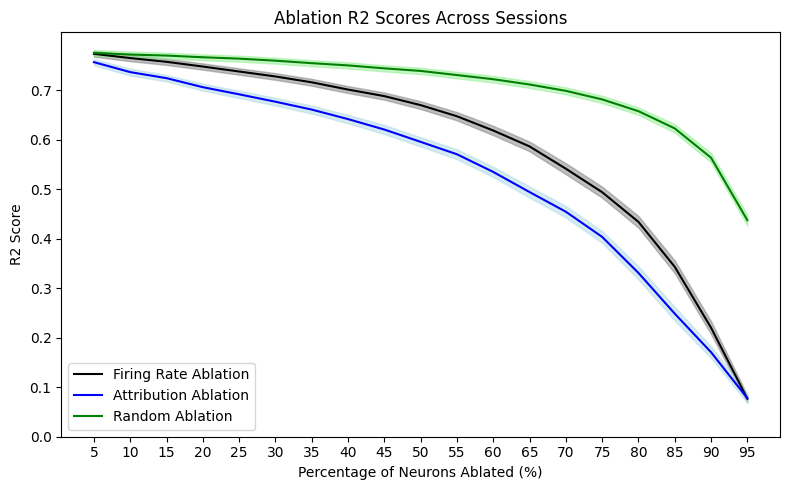

In [6]:
# do the same for the r2 scores after ablation experiments with 3 different types: firing rate, attribution, random
# load the r2 scores and trim them according to the borders like the attribution scores
# note that this was done only for one channel and band so no trimming is needed
# we only need to average the r2_scores rand
steps = np.arange(5,100,5)

# collect per-session vectors in lists, then stack into arrays
r2_scores_fr = []
r2_scores_attr = []
r2_scores_rand = []

for i, row in borders.iterrows():
    session = row['session']
    if session in visp_depths['session'].unique():
        r2_file_fr = Path(r2_scores_path) / f'{session}_r2_scores_fr.npy'
        r2_file_attr = Path(r2_scores_path) / f'{session}_r2_scores_attr.npy'
        r2_file_rand = Path(r2_scores_path) / f'{session}_r2_scores_rand.npy'

        if r2_file_fr.exists():
            r2 = np.load(r2_file_fr)
            r2_attr = np.load(r2_file_attr)
            r2_rand = np.load(r2_file_rand)
            r2_rand = np.mean(r2_rand, axis=1)  # average across random permutations

            # ensure 1D arrays before appending
            r2_scores_fr.append(np.asarray(r2).squeeze().reshape(-1))
            r2_scores_attr.append(np.asarray(r2_attr).squeeze().reshape(-1))
            r2_scores_rand.append(np.asarray(r2_rand).squeeze().reshape(-1))

# convert lists to 2D arrays: shape (n_sessions, len(steps))
def stack_or_empty(lst, n_steps):
    if len(lst) == 0:
        return np.empty((0, n_steps))
    return np.vstack([np.asarray(x).reshape(1, -1) for x in lst])

r2_scores_fr_arr = stack_or_empty(r2_scores_fr, len(steps))
r2_scores_attr_arr = stack_or_empty(r2_scores_attr, len(steps))
r2_scores_rand_arr = stack_or_empty(r2_scores_rand, len(steps))

# get the mean and standard error across sessions and plot
if r2_scores_fr_arr.shape[0] > 0:
    r2_fr_mean = np.mean(r2_scores_fr_arr, axis=0)
    r2_fr_sem = np.std(r2_scores_fr_arr, axis=0) / np.sqrt(r2_scores_fr_arr.shape[0])
else:
    r2_fr_mean = np.full(len(steps), np.nan)
    r2_fr_sem = np.full(len(steps), np.nan)

if r2_scores_attr_arr.shape[0] > 0:
    r2_attr_mean = np.mean(r2_scores_attr_arr, axis=0)
    r2_attr_sem = np.std(r2_scores_attr_arr, axis=0) / np.sqrt(r2_scores_attr_arr.shape[0])
else:
    r2_attr_mean = np.full(len(steps), np.nan)
    r2_attr_sem = np.full(len(steps), np.nan)

if r2_scores_rand_arr.shape[0] > 0:
    r2_rand_mean = np.mean(r2_scores_rand_arr, axis=0)
    r2_rand_sem = np.std(r2_scores_rand_arr, axis=0) / np.sqrt(r2_scores_rand_arr.shape[0])
else:
    r2_rand_mean = np.full(len(steps), np.nan)
    r2_rand_sem = np.full(len(steps), np.nan)


# plot 
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(steps, r2_fr_mean, 'k-', label='Firing Rate Ablation')
ax.fill_between(steps,
                r2_fr_mean - r2_fr_sem,
                r2_fr_mean + r2_fr_sem,
                color='gray', alpha=0.5)    
ax.plot(steps, r2_attr_mean, 'b-', label='Attribution Ablation')
ax.fill_between(steps,
                r2_attr_mean - r2_attr_sem,
                r2_attr_mean + r2_attr_sem,
                color='lightblue', alpha=0.5)
ax.plot(steps, r2_rand_mean, 'g-', label='Random Ablation')
ax.fill_between(steps,
                r2_rand_mean - r2_rand_sem,
                r2_rand_mean + r2_rand_sem,
                color='lightgreen', alpha=0.5)
ax.set_title('Ablation R2 Scores Across Sessions')
ax.set_xlabel('Percentage of Neurons Ablated (%)')
ax.set_ylabel('R2 Score')
ax.set_xticks(steps)
ax.set_yticks(np.arange(0, 0.8, 0.1))
ax.legend()
plt.tight_layout()
plt.savefig(Path(figures_folder) / 'ablation_r2_scores_across_sessions.pdf', format='pdf', dpi=300, bbox_inches='tight')  
plt.show()

## Add the mean attribution to the dataframe, remove areas with few neurons and rename areas

In [111]:
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
# merge the structure_acrunym column from the units_all dataframe into the df dataframe using the unit_id column in df and the unit_id column in units_all
df = df.merge(units_all[['unit_id', 'structure_acronym']], on='unit_id', how='left')

# remove rows from df that of units that are not in list(avr_attr_trimmed.keys()) ie the sessions we have attribution scores for
df = df[df['session_id'].isin(avr_attr_trimmed.keys())]

# loop through the sessions and for each channel from 0-15 and each band from 0-8 add the atttribution scores to the units_all dataframe
for session, attr in avr_attr_trimmed.items():
    attr_spont = avr_attr_spont_trimmed[session]
    for chan in range(chans2keep):
        for band in range(len(bands)+1):
            df.loc[df['session_id'] == session, f'attr_{chan}_{band}'] = attr[chan, band, :]
            df.loc[df['session_id'] == session, f'attr_spont_{chan}_{band}'] = attr_spont[chan, band, :]
            
            
# where the structure_acronym is either LGd or LGv, set to LG
df.loc[df['structure_acronym'].isin(['LGd', 'LGv']), 'structure_acronym'] = 'LG'
# where the structure_acronym is either MGv, MGd or MGm, set to MG
df.loc[df['structure_acronym'].isin(['MGv', 'MGd', 'MGm']), 'structure_acronym'] = 'MG'
# where the structure_acronym is either SCig or SCiw, set to SC
df.loc[df['structure_acronym'].isin(['SCig', 'SCiw']), 'structure_acronym'] = 'SC'

unique_areas = df['structure_acronym'].unique()
# remove from unique_areas 'root', 'CA2','RR', 'VISrll', 'RN', 'FF', 'grey', 'PRE', 'HY', 'IGL', 'DT', 'SSp', 'VPLpc', 'SPFp', 'HPF', 'VIS'
areas2remove = ['root', 'CA2', 'RR', 'VISrll', 'RN', 'FF', 'grey', 'PRE',
                                                              'HY', 'IGL', 'DT', 'SSp', 'VPLpc', 'SPFp', 'HPF', 
                                                              'VIS','SNr','SNc', 'PP', 'TH']

unique_areas = [area for area in unique_areas if area not in areas2remove]
unique_areas = sorted(unique_areas)
print(f'Unique areas: {unique_areas}')

# create a 3D numpy array to hold the grand mean for each area, channel and band
grand_mean       = np.zeros((len(unique_areas),len(bands)+1, chans2keep))
grand_mean_spont = np.zeros_like(grand_mean)
# loop through the unique areas and for each area, channel and band, calculate the grand mean
for i, area in enumerate(unique_areas):
    for chan in range(chans2keep):
        for band in range(len(bands)+1):
            # get the mean of the attribution scores for the area, channel and band, ignoring NaN values
            all_vals = df.loc[df['structure_acronym'] == area, f'attr_{chan}_{band}'].values
            all_vals = np.abs(all_vals)
            grand_mean[i, band, chan] = np.nanmean(all_vals)
            
            all_vals_spont = df.loc[df['structure_acronym'] == area, f'attr_spont_{chan}_{band}'].values
            all_vals_spont = np.abs(all_vals_spont)
            grand_mean_spont[i, band, chan] = np.nanmean(all_vals_spont)
            
            
area_count = dict(zip(unique_areas, np.zeros(len(unique_areas))))
# for each session if it includes an area, increment the count for that area
sessions = list(avr_attr_trimmed.keys())
for session in sessions:
    areas = df.loc[df['session_id'] == session, 'structure_acronym'].unique()
    for area in areas:
        if area in area_count:
            area_count[area] += 1

print(f'Area count: {area_count}')

# make a dataframe with areas as columns, sessions as index and the count of sessions for each area
unit_counts = pd.DataFrame(index=sessions, columns=unique_areas)
for session in sessions:
    areas = df.loc[df['session_id'] == session, 'structure_acronym'].unique()
    for area in areas:
        if area in unique_areas:
            unit_counts.at[session, area] = len(df.loc[(df['session_id'] == session) & (df['structure_acronym'] == area)])
            
unit_counts.head()

Unique areas: ['APN', 'CA1', 'CA3', 'DG', 'Eth', 'LG', 'LP', 'LT', 'MB', 'MG', 'MRN', 'NB', 'NOT', 'PIL', 'POL', 'POST', 'PPT', 'PoT', 'ProS', 'SC', 'SGN', 'SUB', 'VISal', 'VISam', 'VISl', 'VISp', 'VISpm', 'VISrl', 'ZI']
Area count: {'APN': 78.0, 'CA1': 87.0, 'CA3': 79.0, 'DG': 86.0, 'Eth': 11.0, 'LG': 46.0, 'LP': 67.0, 'LT': 9.0, 'MB': 74.0, 'MG': 72.0, 'MRN': 60.0, 'NB': 28.0, 'NOT': 40.0, 'PIL': 39.0, 'POL': 45.0, 'POST': 52.0, 'PPT': 14.0, 'PoT': 52.0, 'ProS': 42.0, 'SC': 34.0, 'SGN': 58.0, 'SUB': 56.0, 'VISal': 85.0, 'VISam': 84.0, 'VISl': 82.0, 'VISp': 87.0, 'VISpm': 87.0, 'VISrl': 84.0, 'ZI': 16.0}
Area count: {'APN': 78.0, 'CA1': 87.0, 'CA3': 79.0, 'DG': 86.0, 'Eth': 11.0, 'LG': 46.0, 'LP': 67.0, 'LT': 9.0, 'MB': 74.0, 'MG': 72.0, 'MRN': 60.0, 'NB': 28.0, 'NOT': 40.0, 'PIL': 39.0, 'POL': 45.0, 'POST': 52.0, 'PPT': 14.0, 'PoT': 52.0, 'ProS': 42.0, 'SC': 34.0, 'SGN': 58.0, 'SUB': 56.0, 'VISal': 85.0, 'VISam': 84.0, 'VISl': 82.0, 'VISp': 87.0, 'VISpm': 87.0, 'VISrl': 84.0, 'ZI': 1

,APN,CA1,CA3,DG,Eth,LG,LP,LT,MB,MG,...,SC,SGN,SUB,VISal,VISam,VISl,VISp,VISpm,VISrl,ZI
1047969464,45,150,26,21,NaN,14,NaN,NaN,22,65,...,NaN,NaN,33,67,58,65,21,49,65,33
1048189115,45,121,29,20,NaN,16,NaN,NaN,17,62,...,18,NaN,NaN,43,67,35,49,44,45,19
1049273528,61,97,11,19,NaN,NaN,NaN,5,48,74,...,NaN,NaN,7,32,51,15,81,38,40,NaN
1049514117,43,110,2,58,NaN,NaN,21,NaN,24,65,...,NaN,16,NaN,56,70,5,78,35,46,NaN
1051155866,66,139,9,23,NaN,3,1,NaN,9,NaN,...,13,32,11,21,23,24,75,59,31,9


## For each area, calculate the avergae attribution score for in each session for each channel and band


In [ ]:
warnings.filterwarnings("ignore", category=RuntimeWarning)
area_attr = {}
area_attr_spont = {}
# for each session if it includes an area, increment the count for that area
sessions = list(avr_attr_trimmed.keys())
for session in sessions:
    areas = df.loc[df['session_id'] == session, 'structure_acronym'].unique()
    for area in areas:
        if area in unique_areas:
            if area not in area_attr.keys():
                area_attr[area] = np.full((chans2keep, len(bands)+1, len(sessions)), np.nan)
                area_attr_spont[area] = np.full((chans2keep, len(bands)+1, len(sessions)), np.nan)
            # get the attribution scores for the area, channel and band
            for chan in range(chans2keep):
                for band in range(len(bands)+1):
                    all_vals = df.loc[(df['session_id'] == session) & (df['structure_acronym'] == area), [f'attr_{chan}_{band}']].values
                    all_vals = np.abs(all_vals)
                    if all_vals.size > 0:
                        area_attr[area][chan, band, sessions.index(session)] = np.nanmean(all_vals)
                    all_vals_spont = df.loc[(df['session_id'] == session) & (df['structure_acronym'] == area), [f'attr_spont_{chan}_{band}']].values
                    all_vals_spont = np.abs(all_vals_spont)
                    if all_vals_spont.size > 0:
                        area_attr_spont[area][chan, band, sessions.index(session)] = np.nanmean(all_vals_spont)

# create a 3D numpy array to hold the grand mean for each area, channel and band, only for sessions with more than 10 units in the area                        
grand_mean_sessions = np.zeros((len(unique_areas), len(bands)+1, chans2keep))
# for each area, calculate the grand mean for each channel and band
for i, area in enumerate(unique_areas):
    for chan in range(chans2keep):
        for band in range(len(bands)+1):
            # make a mask for sessions with more than 10 units in the area
            mask = unit_counts[area] > 10 
            # get the mean of the attribution scores for the area, channel and band, ignoring NaN values
            grand_mean_sessions[i, band, chan] = np.nanmean(area_attr[area][chan, band, mask])

# Plot the distribution of attribution scores for NOT, VISp and CA1 for channel 6 broadband

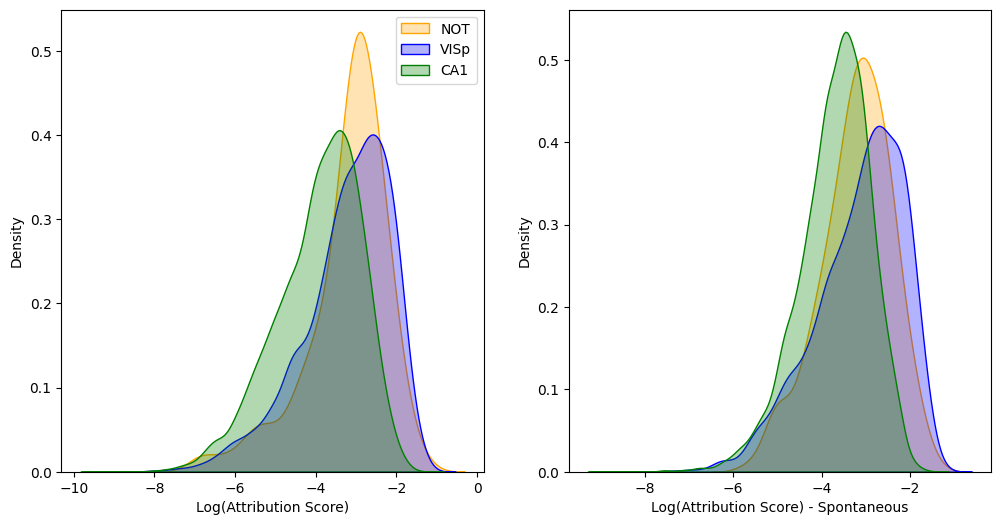

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

bandi = 0
chani = 6

# NOT
all_vals = df.loc[(df['structure_acronym'] == 'NOT'), [f'attr_{chani}_{bandi}']].values.ravel()
all_vals = all_vals[~np.isnan(all_vals) & ~np.isinf(all_vals)]
all_vals = np.abs(all_vals)
all_vals = all_vals[all_vals > 0]  # Remove zeros and negatives
sns.kdeplot(ax=ax[0], x=np.log10(all_vals), alpha=0.3, label='NOT', fill=True, color='orange')


all_vals_spont = df.loc[(df['structure_acronym'] == 'NOT'), [f'attr_spont_{chani}_{bandi}']].values.ravel()
all_vals_spont = all_vals_spont[~np.isnan(all_vals_spont) & ~np.isinf(all_vals_spont)]
all_vals_spont = np.abs(all_vals_spont)
all_vals_spont = all_vals_spont[all_vals_spont > 0]  # Remove zeros and negatives
sns.kdeplot(ax=ax[1], x=np.log10(all_vals_spont), alpha=0.3, label='NOT', fill=True, color='orange')

# VISp
all_vals = df.loc[(df['structure_acronym'] == 'VISp'), [f'attr_{chani}_{bandi}']].values.ravel()
all_vals = all_vals[~np.isnan(all_vals) & ~np.isinf(all_vals)]
all_vals = np.abs(all_vals)
all_vals = all_vals[all_vals > 0]  # Remove zeros and negatives
sns.kdeplot(ax=ax[0], x=np.log10(all_vals), alpha=0.3, label='VISp', fill=True, color='blue')

all_vals_spont = df.loc[(df['structure_acronym'] == 'VISp'), [f'attr_spont_{chani}_{bandi}']].values.ravel()
all_vals_spont = all_vals_spont[~np.isnan(all_vals_spont) & ~np.isinf(all_vals_spont)]
all_vals_spont = np.abs(all_vals_spont)
all_vals_spont = all_vals_spont[all_vals_spont > 0]  # Remove zeros and negatives
sns.kdeplot(ax=ax[1], x=np.log10(all_vals_spont), alpha=0.3, label='VISp', fill=True, color='blue')
# CA1
all_vals = df.loc[(df['structure_acronym'] == 'CA1'), [f'attr_{chani}_{bandi}']].values.ravel()
all_vals = all_vals[~np.isnan(all_vals) & ~np.isinf(all_vals)]
all_vals = np.abs(all_vals)
all_vals = all_vals[all_vals > 0]  # Remove zeros and negatives
sns.kdeplot(ax=ax[0], x=np.log10(all_vals), alpha=0.3, label='CA1', fill=True, color='green')

all_vals_spont = df.loc[(df['structure_acronym'] == 'CA1'), [f'attr_spont_{chani}_{bandi}']].values.ravel()
all_vals_spont = all_vals_spont[~np.isnan(all_vals_spont) & ~np.isinf(all_vals_spont)]
all_vals_spont = np.abs(all_vals_spont)
all_vals_spont = all_vals_spont[all_vals_spont > 0]  # Remove zeros and negatives
sns.kdeplot(ax=ax[1], x=np.log10(all_vals_spont), alpha=0.3, label='CA1', fill=True, color='green')

ax[0].set_xlabel('Log(Attribution Score)')
ax[0].set_ylabel('Density')
ax[0].legend()

ax[1].set_xlabel('Log(Attribution Score) - Spontaneous')
ax[1].set_ylabel('Density')

# plt.savefig(Path(figures_folder) / 'attribution_score_distributions_NOT_VISp_CA1.pdf', 
#             format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Plot the grand mean for each band 


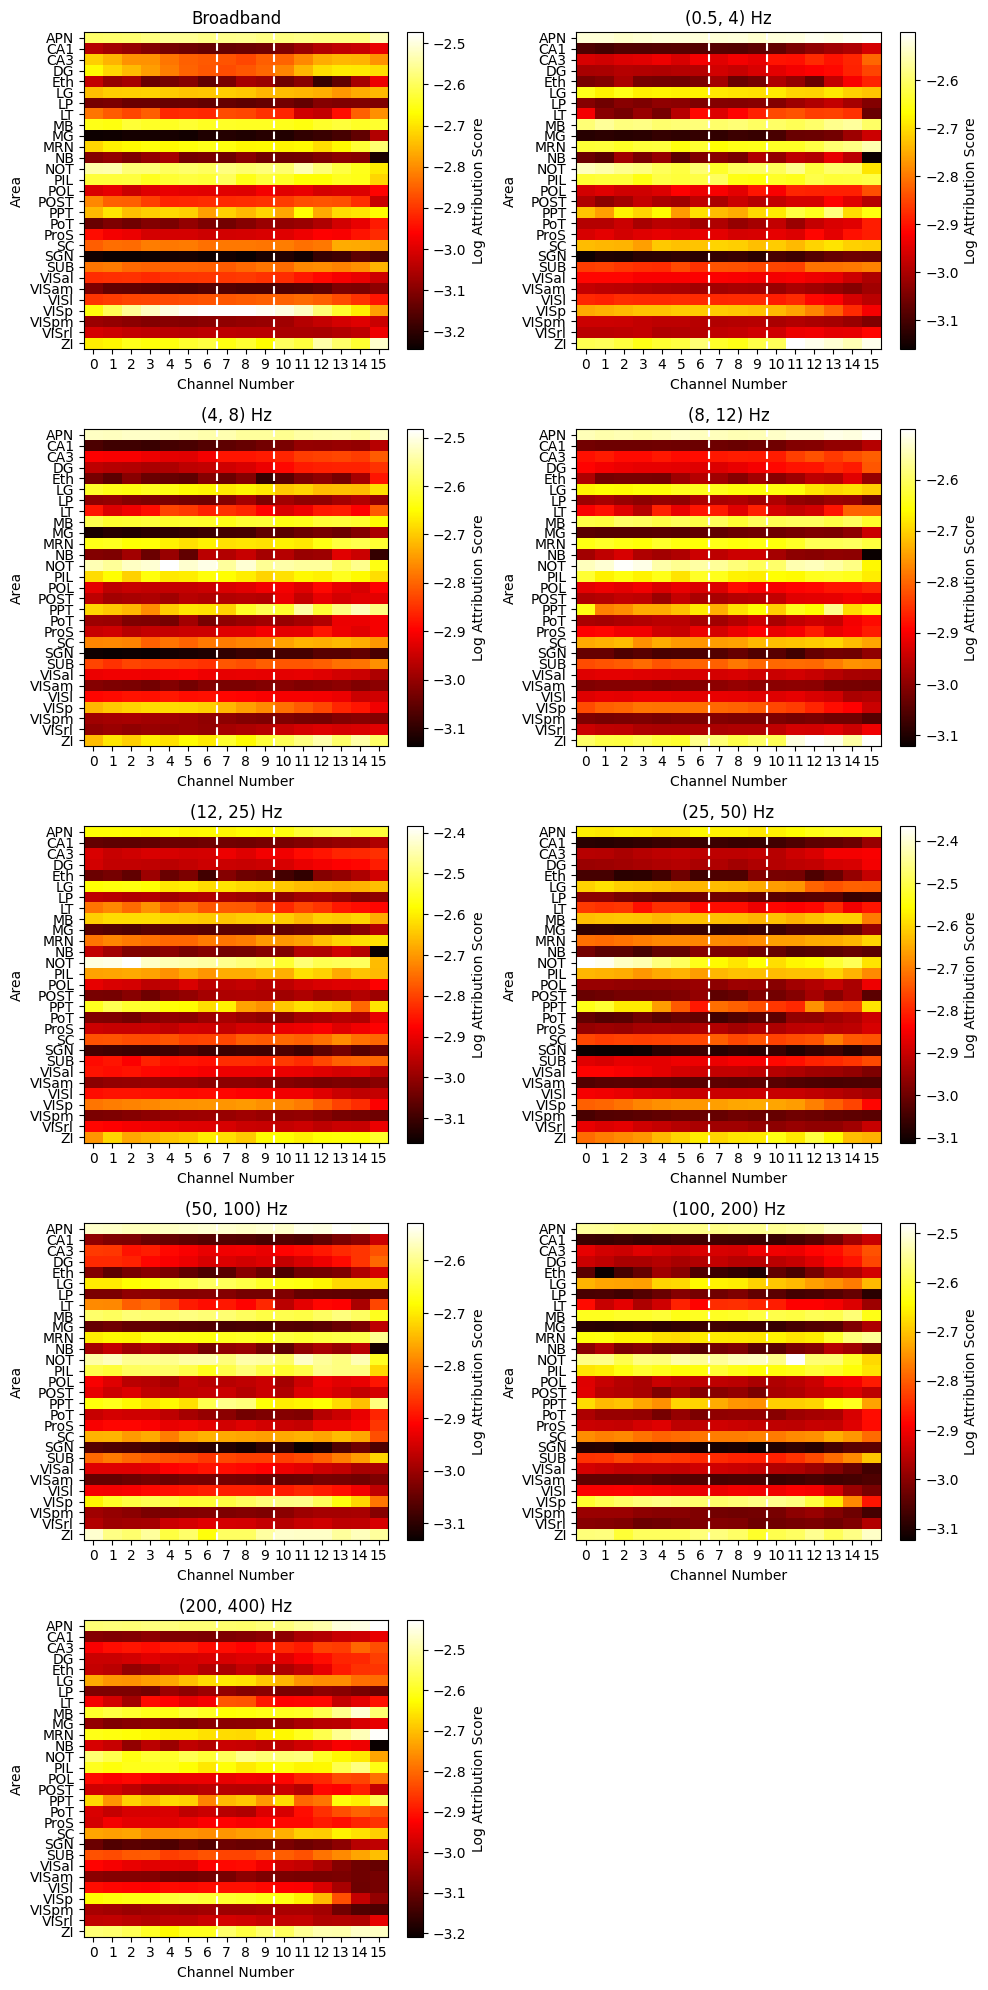

In [112]:
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
fig, ax = plt.subplots(int(np.ceil((len(bands)+1)/2)),2,figsize=(10,20))
for bandi in range(len(bands)+1):
    ax.flat[bandi].imshow(np.log10(grand_mean[:,bandi,:]) , aspect='auto', cmap='hot')
    ax.flat[bandi].set_xticks(range(16))
    ax.flat[bandi].set_yticks(range(len(unique_areas)))
    ax.flat[bandi].set_yticklabels(unique_areas)
    ax.flat[bandi].set_ylabel('Area')
    if bandi == 0:
        ax.flat[bandi].set_title('Broadband')
    else:
        ax.flat[bandi].set_title(str(bands[bandi-1]) + ' Hz')
        
    # plot vertical lines at 7.5 and 10.5 to separate deep, middle and superficial channels
    ax.flat[bandi].axvline(x=6.5, color='w', linestyle='--')
    ax.flat[bandi].axvline(x=9.5, color='w', linestyle='--')
    # add colorbar
    cbar = plt.colorbar(ax.flat[bandi].images[0], ax=ax.flat[bandi], orientation='vertical')
    cbar.set_label('Log Attribution Score')
    ax.flat[bandi].set_xlabel('Channel Number')
    
plt.tight_layout()
fig.delaxes(ax.flat[-1])
plt.savefig(Path(figures_folder) / 'grand_mean_attribution_scores_across_areas_channels_bands.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Plot the grand mean of spontaneous activity for each band 


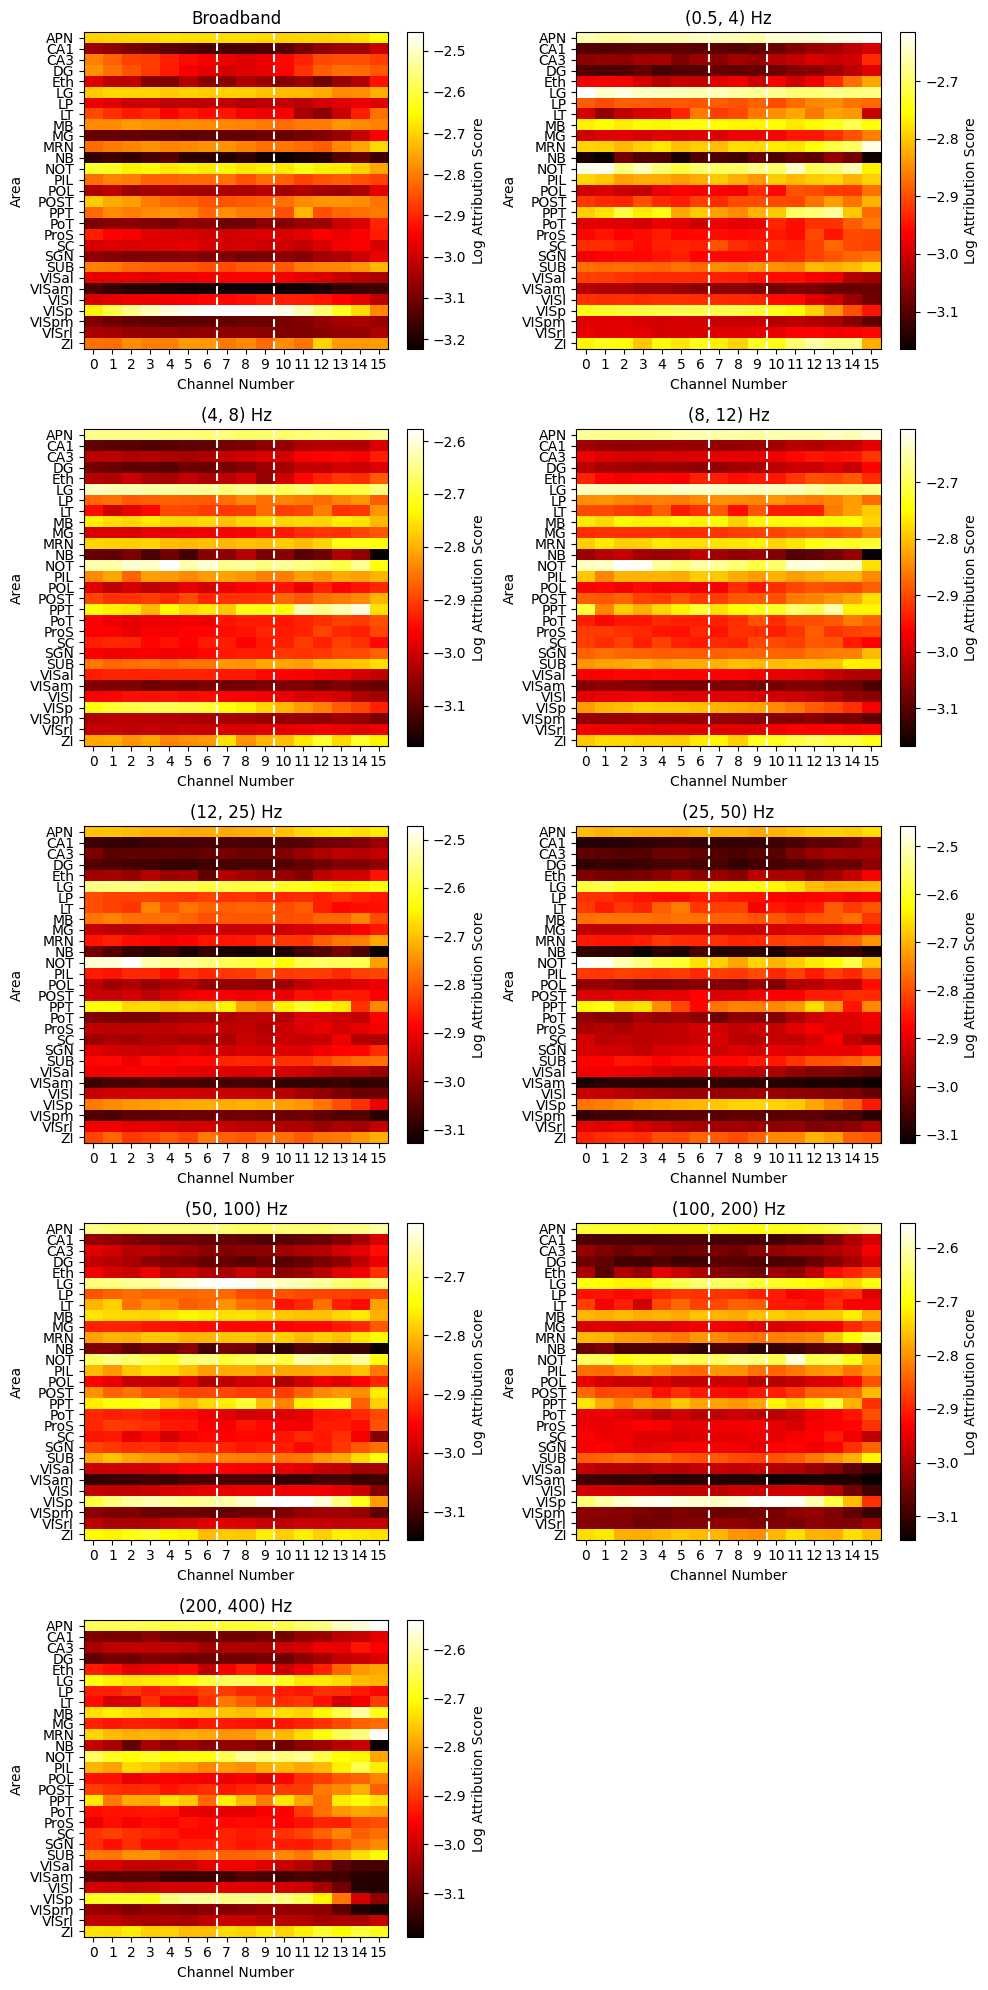

In [11]:
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
fig, ax = plt.subplots(int(np.ceil((len(bands)+1)/2)),2,figsize=(10,20))
for bandi in range(len(bands)+1):
    ax.flat[bandi].imshow(np.log10(grand_mean_spont[:,bandi,:]) , aspect='auto', cmap='hot')
    ax.flat[bandi].set_xticks(range(16))
    ax.flat[bandi].set_yticks(range(len(unique_areas)))
    ax.flat[bandi].set_yticklabels(unique_areas)
    ax.flat[bandi].set_ylabel('Area')
    if bandi == 0:
        ax.flat[bandi].set_title('Broadband')
    else:
        ax.flat[bandi].set_title(str(bands[bandi-1]) + ' Hz')
        
    # plot vertical lines at 7.5 and 10.5 to separate deep, middle and superficial channels
    ax.flat[bandi].axvline(x=6.5, color='w', linestyle='--')
    ax.flat[bandi].axvline(x=9.5, color='w', linestyle='--')
    # add colorbar
    cbar = plt.colorbar(ax.flat[bandi].images[0], ax=ax.flat[bandi], orientation='vertical')
    cbar.set_label('Log Attribution Score')
    ax.flat[bandi].set_xlabel('Channel Number')
    
plt.tight_layout()
fig.delaxes(ax.flat[-1])
# plt.savefig(Path(figures_folder) / 'grand_mean_attribution_scores_across_areas_channels_bands.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()


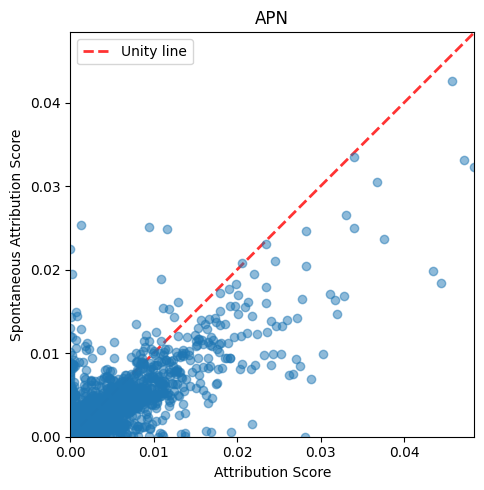

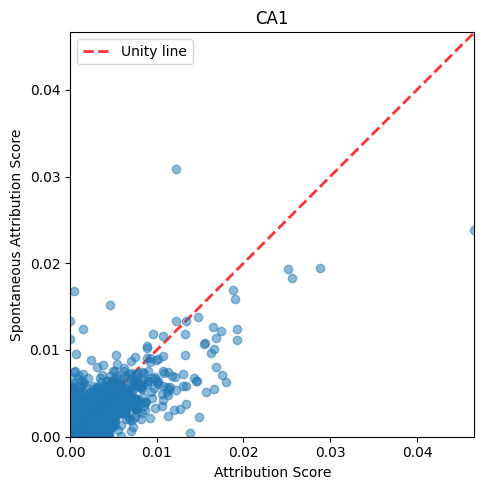

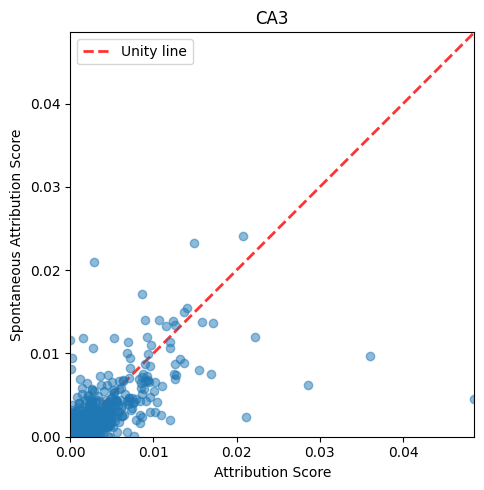

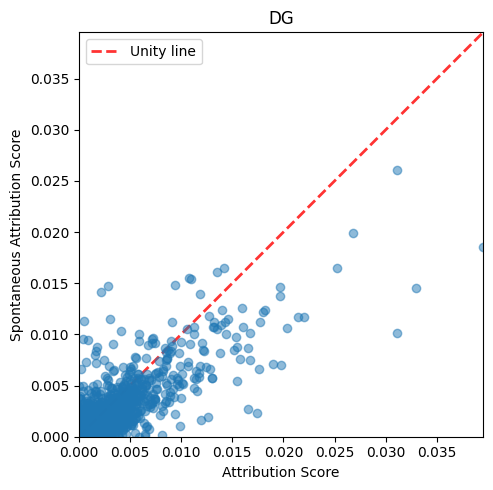

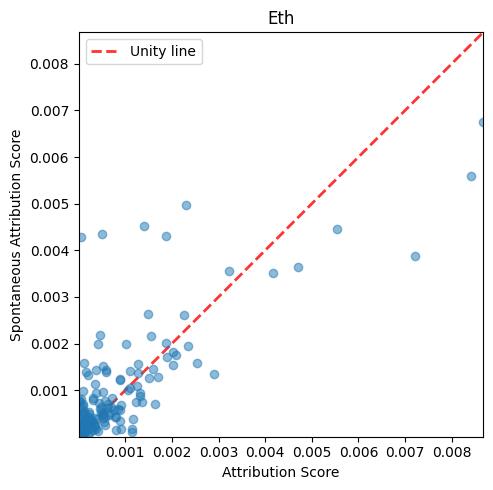

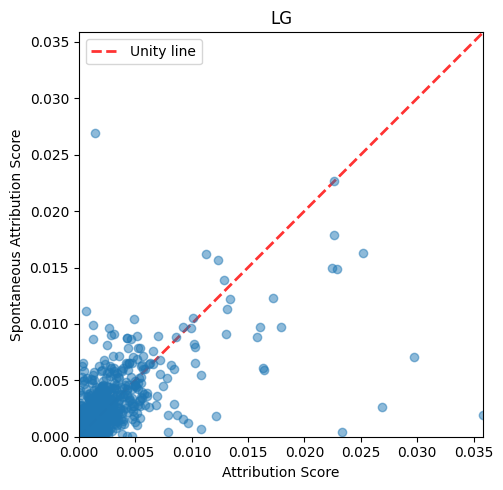

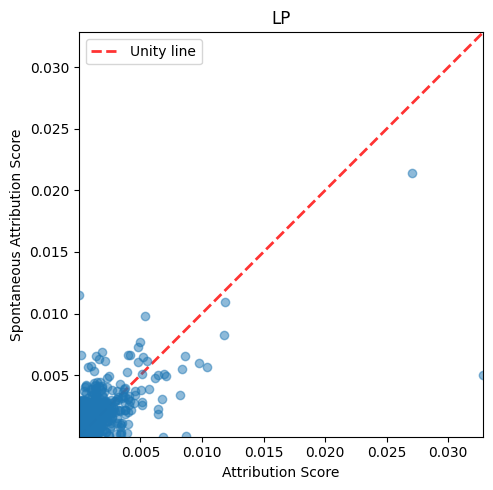

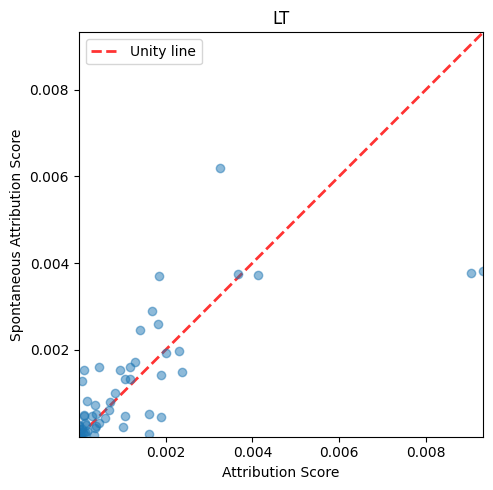

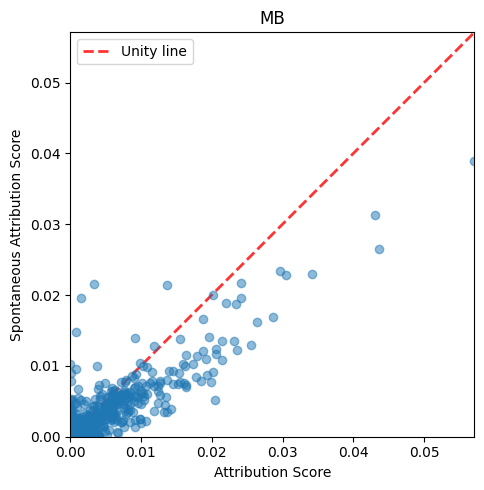

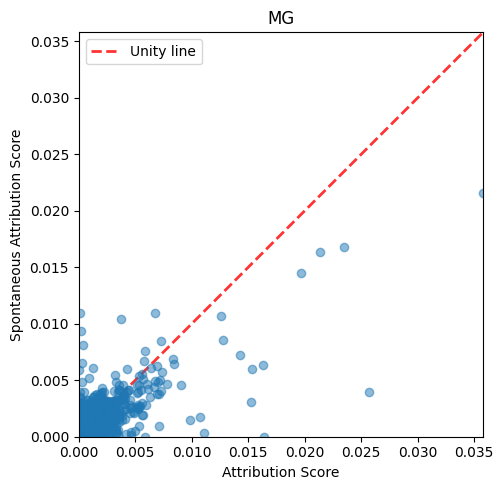

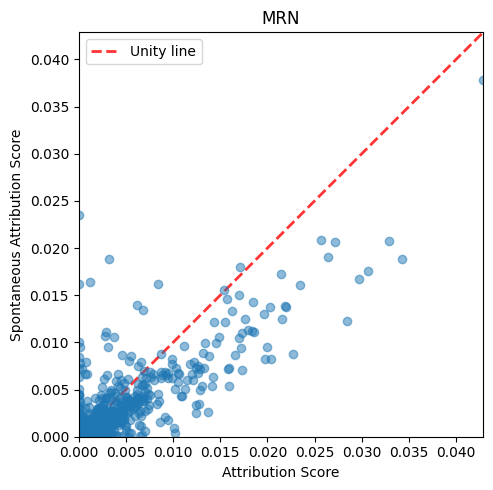

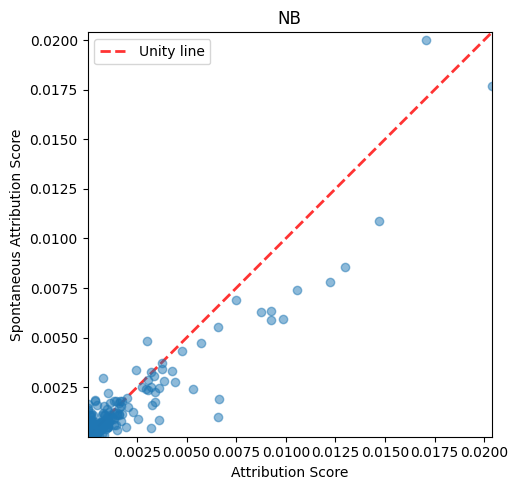

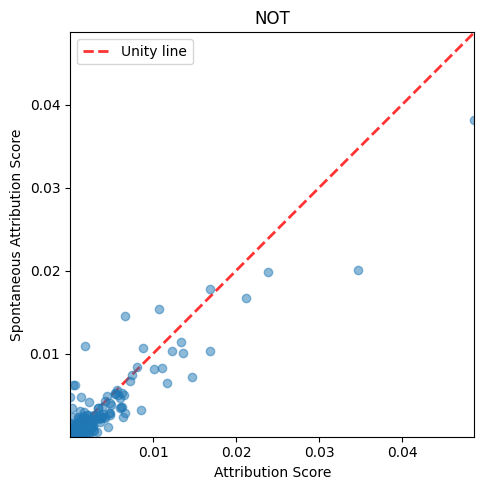

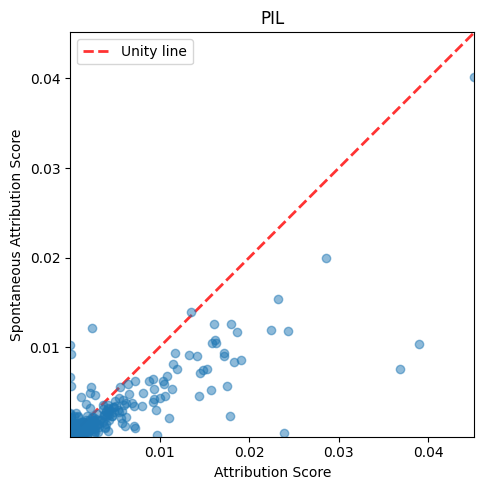

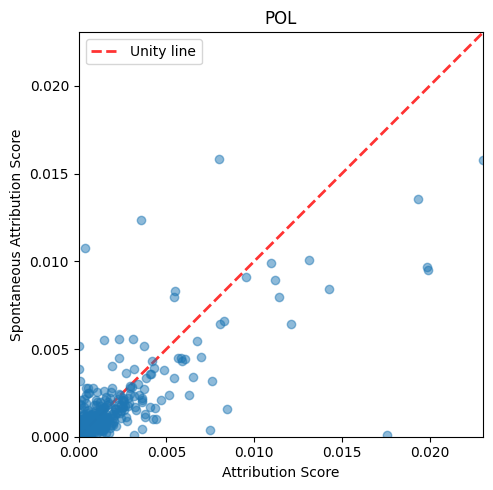

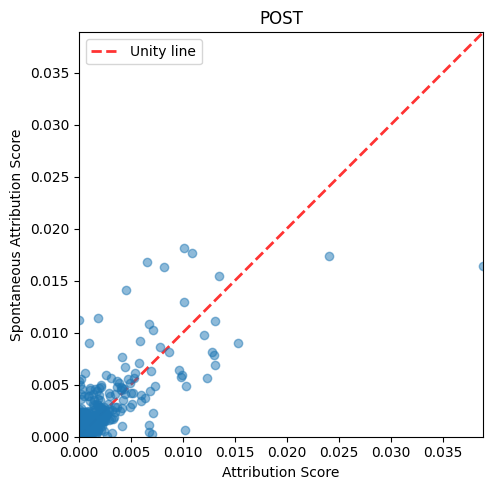

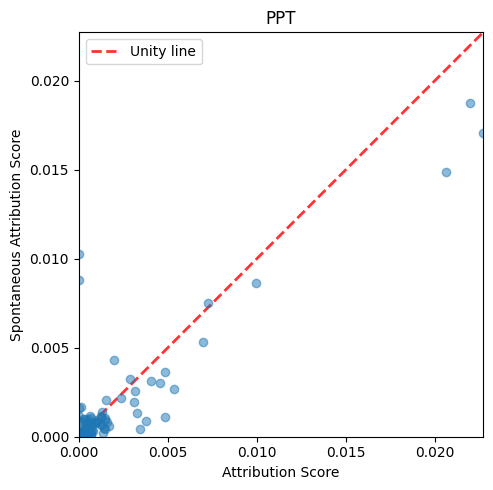

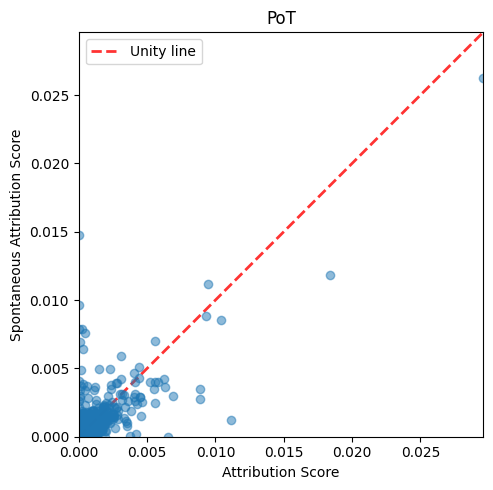

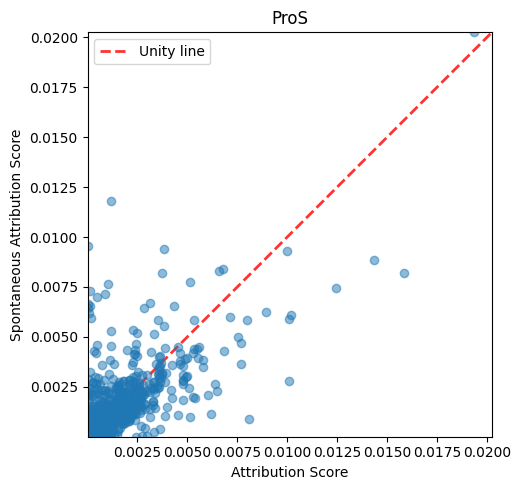

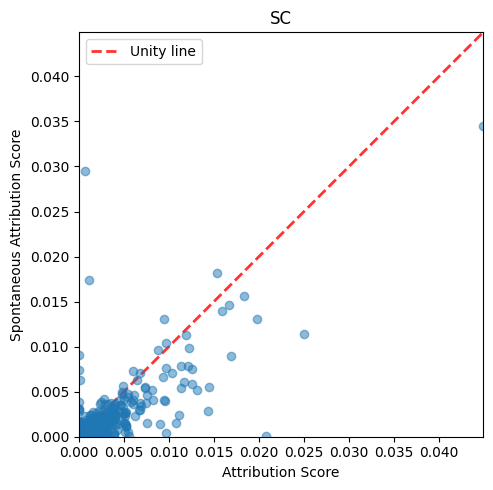

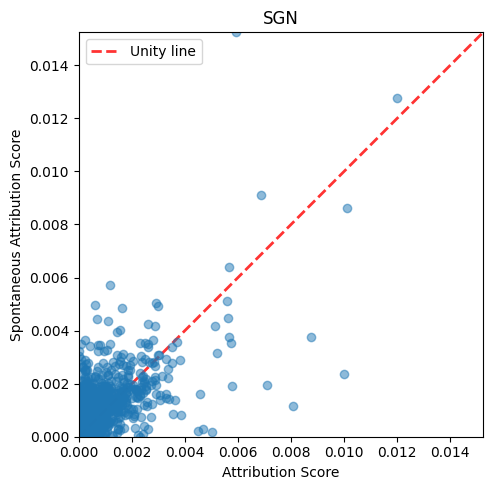

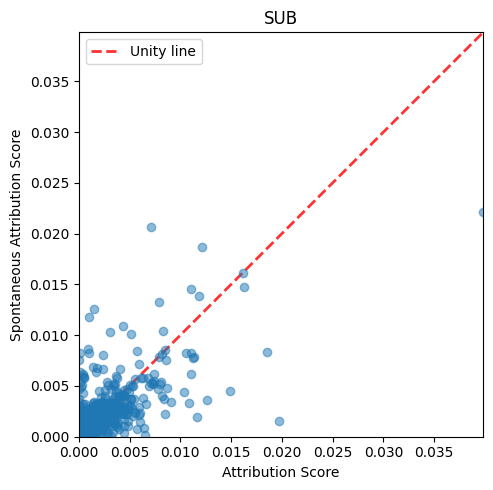

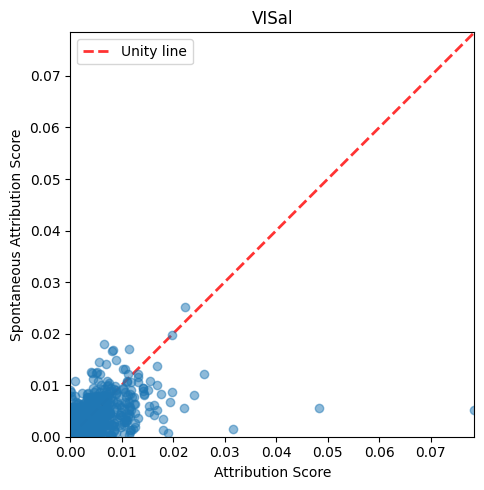

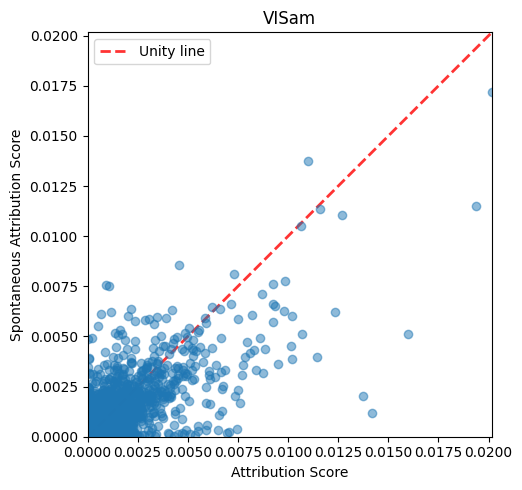

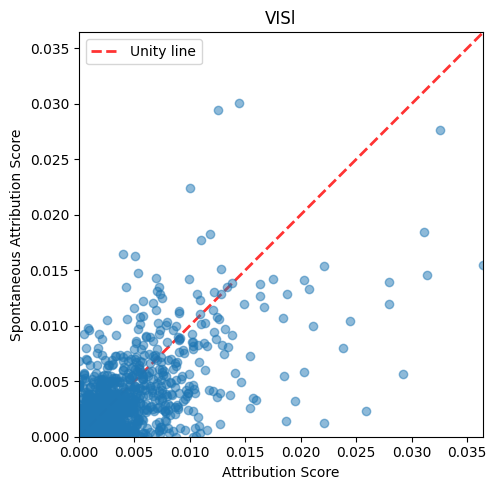

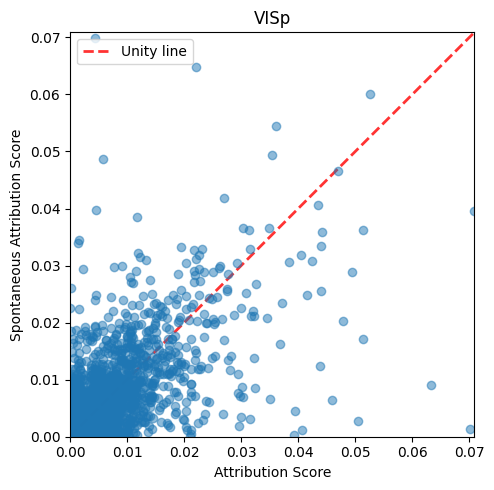

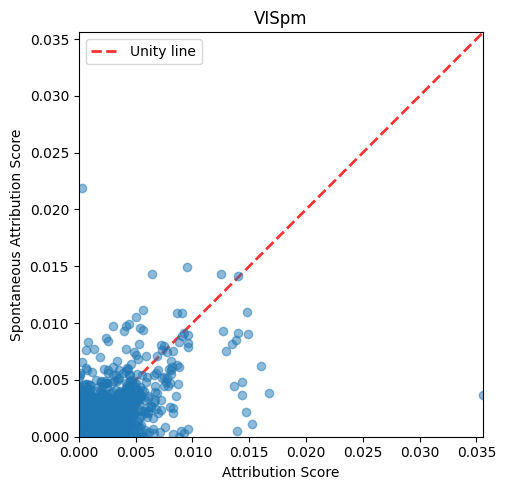

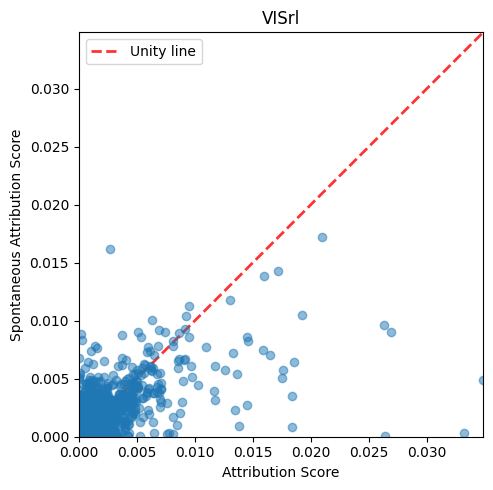

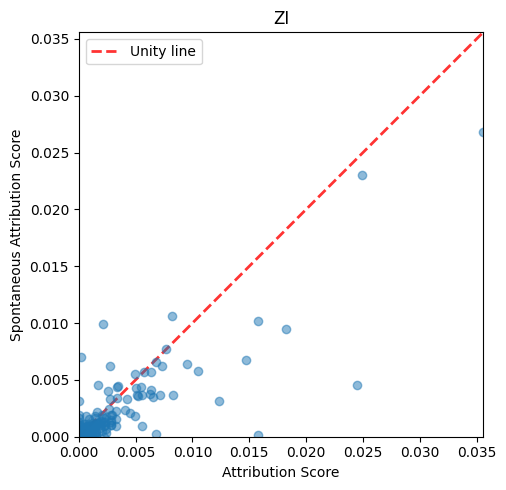

In [ ]:
# for each area, make a scatter plot of the attribution vs spontaneous attribution for the selected channel and band
chani =  6  
bandi = 0  # broadband

for i, area in enumerate(unique_areas):
    fig, ax = plt.subplots(figsize=(8,5))
    attr_vals = df.loc[df['structure_acronym'] == area, f'attr_{chani}_{bandi}'].values
    attr_spont_vals = df.loc[df['structure_acronym'] == area, f'attr_spont_{chani}_{bandi}'].values
    
    # Remove NaN values
    mask = ~np.isnan(attr_vals) & ~np.isnan(attr_spont_vals)
    attr_vals_clean = np.abs(attr_vals[mask])
    attr_spont_vals_clean = np.abs(attr_spont_vals[mask])

    if len(attr_vals_clean) == 0:
        continue
        
    ax.scatter(attr_vals_clean, attr_spont_vals_clean, alpha=0.5)
    ax.set_title(area)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_xlabel('Attribution Score')
    ax.set_ylabel('Spontaneous Attribution Score')
    
    # Unity line -     Method 1 (recommended)
    all_vals = np.concatenate((attr_vals_clean, attr_spont_vals_clean))
    lims = [np.min(all_vals), np.max(all_vals)]
    ax.plot(lims, lims, 'r--', alpha=0.8, zorder=0, linewidth=2, label='Unity line')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    
    ax.set_aspect('equal', adjustable='box')
    ax.legend()
    plt.tight_layout()
    plt.show()

# plt.savefig(Path(figures_folder) / 'attribution_vs_spontaneous_attribution_scatter_plots.pdf', format='pdf', dpi=300, bbox_inches='tight')

## plot the enhancement index active vs spontaneous

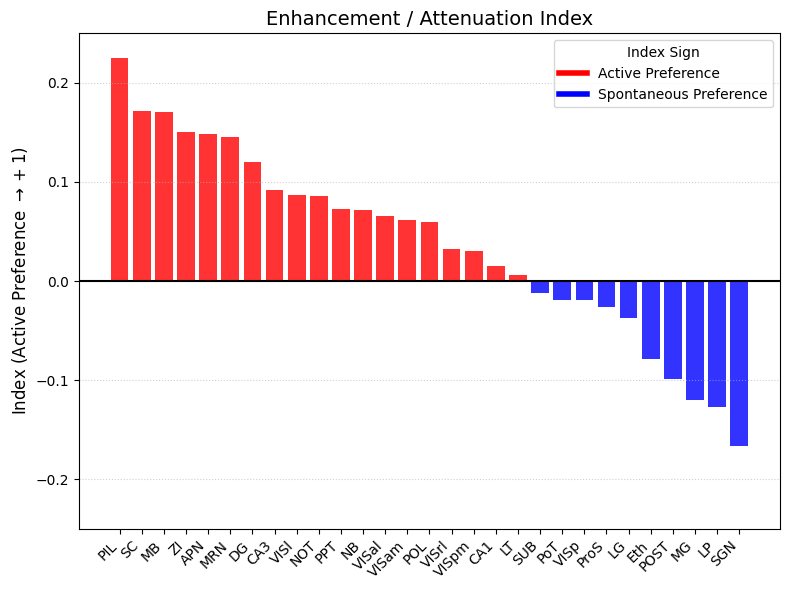

In [35]:
# --- Define the specific channel and band variables used in your DataFrame columns ---
chani = 5
bandi = 0
active_col = f'attr_{chani}_{bandi}'
spont_col = f'attr_spont_{chani}_{bandi}'
EPS = 1e-6

# --- CRITICAL CORRECTION: TAKE ABSOLUTE VALUE BEFORE GROUPING ---

# 1. Take the absolute value of the attribution scores in the DataFrame.
#    This ensures we compare the MAGNITUDE of influence.
df['abs_active'] = np.abs(df[active_col])
df['abs_spont'] = np.abs(df[spont_col])

# 2. Group the data by area and calculate the mean of the ABSOLUTE attribution scores.
area_means = df.groupby('structure_acronym')[['abs_active', 'abs_spont']].mean().reset_index()
area_means = area_means[area_means['structure_acronym'].isin(unique_areas)]


# --- REMAINING CALCULATION (Using the corrected absolute means) ---

# Method 1: Simple Ratio of Means (Active / Spontaneous)
area_means['Simple_Ratio'] = area_means['abs_active'] / (area_means['abs_spont'] + EPS)

# Method 2: Enhancement/Attenuation Index
area_means['Enhancement_Index'] = (area_means['abs_active'] - area_means['abs_spont']) / \
                                 (area_means['abs_active'] + area_means['abs_spont'] + EPS)

# --- Visualization Code Follows (Unchanged) ---

# Drop rows where attribution is essentially zero in both 
area_means.dropna(subset=['Enhancement_Index'], inplace=True)
area_means.sort_values(by='Enhancement_Index', inplace=True, ascending=False)
areas_sorted = area_means['structure_acronym'].values
N_areas = len(areas_sorted)

# --- Visualization: Paired Bar Charts (Ratio and Index) ---

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
x = np.arange(N_areas)

# # --- Chart 1: Simple Ratio of Means ---
# ax = axes[0]
# ax.bar(x, area_means['Simple_Ratio'], color='darkgreen', alpha=0.7)

# ax.axhline(1.0, color='r', linestyle='--', linewidth=1.5, label='Unity Line (Ratio=1)')
# ax.set_title('Ratio of Mean Attribution (Active / Spontaneous)', fontsize=14)
# ax.set_ylabel('Ratio of Means', fontsize=12)
# ax.set_xticks(x)
# ax.set_xticklabels(areas_sorted, rotation=45, ha='right')
# ax.legend()
# ax.set_yscale('log') # Use log scale for better visibility of large ratios
# ax.grid(axis='y', linestyle=':', alpha=0.6)

# --- Chart 2: Enhancement/Attenuation Index ---
ax = axes
colors = ['r' if idx > 0 else 'b' for idx in area_means['Enhancement_Index']]
ax.bar(x, area_means['Enhancement_Index'], color=colors, alpha=0.8)

ax.axhline(0, color='k', linestyle='-', linewidth=1.5, label='Unity Line (Index=0)')
ax.set_title('Enhancement / Attenuation Index', fontsize=14)
ax.set_ylabel('Index (Active Preference $\\rightarrow +1$)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(areas_sorted, rotation=45, ha='right')
ax.legend(handles=[plt.Line2D([0], [0], color='r', lw=4, label='Active Preference'),
                   plt.Line2D([0], [0], color='b', lw=4, label='Spontaneous Preference')],
           loc='upper right', title='Index Sign')
ax.set_ylim(-.25, .25)
ax.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


## Compare SST and VIP interneurons 


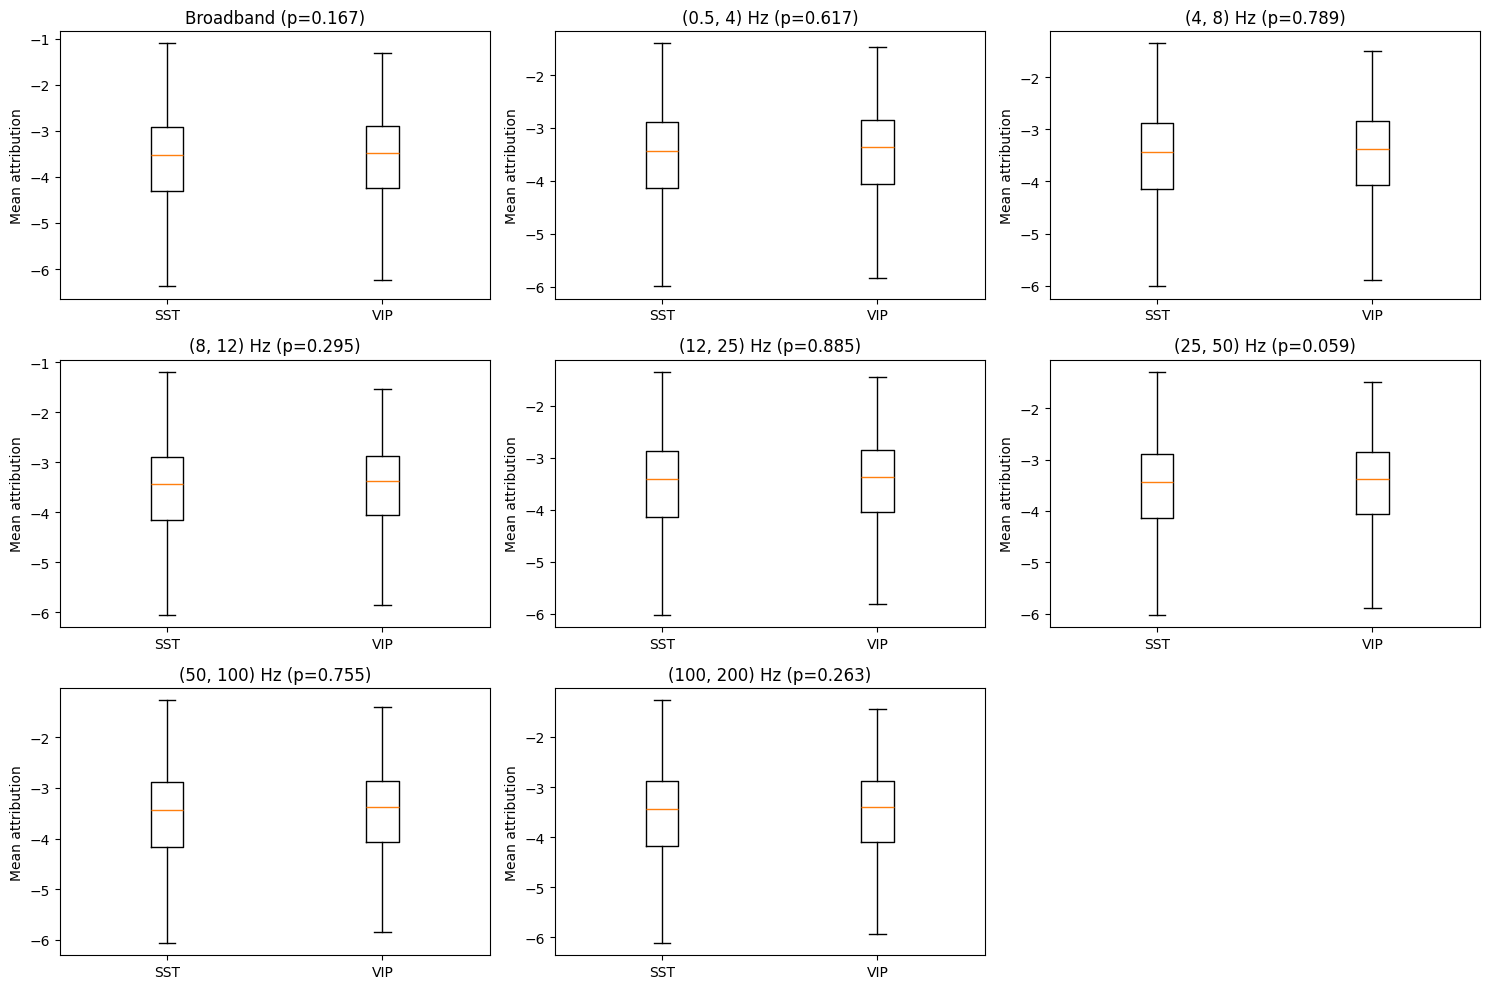

In [52]:
# Compare SST and VIP interneurons 
from scipy.stats import ranksums
vis_idx = df.unit_id[df['structure_acronym'].str.contains("VIS")]
sst = df.unit_id[df['genotype'].str.contains("Sst")]
vip = df.unit_id[df['genotype'].str.contains("Vip")]
sst  = np.intersect1d(sst, vis_idx)
vip = np.intersect1d(vip,  vis_idx)

chani = 6

# loop through the bands and get the attribution scores for the pyr and intn units

fig, ax = plt.subplots(3,3, figsize=(15,10))
eps = 1e-6

for bandi in range(len(bands)+1):
    # get the attribution scores for the pyr and intn units
    attr_sst = df.loc[df.unit_id.isin(sst), f'attr_{chani}_{bandi}'].values + eps
    attr_vip = df.loc[df.unit_id.isin(vip), f'attr_{chani}_{bandi}'].values + eps
    
    # remove NaN values
    attr_sst = attr_sst[~np.isnan(attr_sst)]
    attr_vip = attr_vip[~np.isnan(attr_vip)]
    
    # perform ranksum test
    stat, pval = ranksums(attr_sst, attr_vip)

    ax.flat[bandi].boxplot([np.log10(np.abs(attr_sst)), np.log10(np.abs(attr_vip))], showfliers=False)
    if bandi == 0:
        ax.flat[bandi].set_title('Broadband' + f' (p={pval:.3f})')
    else:
        ax.flat[bandi].set_title(str(bands[bandi-1]) + ' Hz' + f' (p={pval:.3f})')
    ax.flat[bandi].set_xticklabels(['SST', 'VIP'])
    ax.flat[bandi].set_ylabel('Mean attribution') 
    
plt.tight_layout()
fig.delaxes(ax.flat[-1])
plt.savefig(Path(figures_folder) / 'SST_vs_VIP_attribution_scores_channel_7.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Compare PYR vs INT

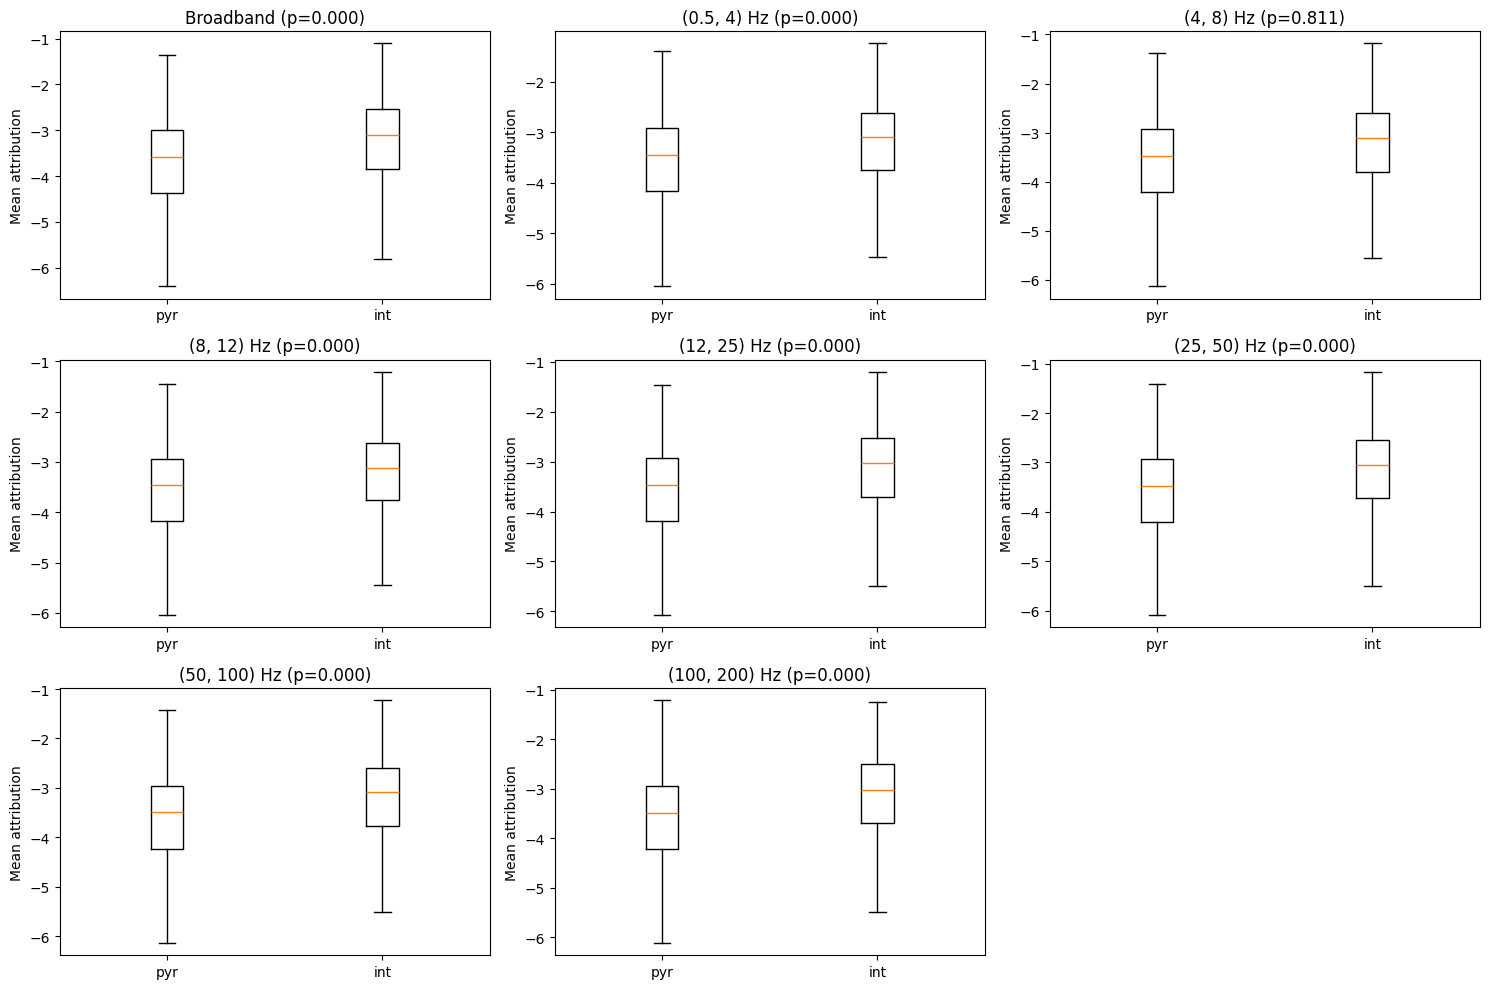

In [58]:
vis_idx = df.unit_id[df['structure_acronym'].str.contains("VIS")]
pyr  = np.intersect1d(df.unit_id[df.pyr == 1], vis_idx)
intn = np.intersect1d(df.unit_id[df.pyr == 0], vis_idx)

chani = 2

# loop through the bands and get the attribution scores for the pyr and intn units

fig, ax = plt.subplots(3,3, figsize=(15,10))
for bandi in range(len(bands)+1):
    # get the attribution scores for the pyr and intn units
    attr_pyt = df.loc[df.unit_id.isin(pyr), f'attr_{chani}_{bandi}'].values + eps
    attr_int = df.loc[df.unit_id.isin(intn), f'attr_{chani}_{bandi}'].values + eps
    
    # remove NaN values
    attr_pyt = attr_pyt[~np.isnan(attr_pyt)]
    attr_int = attr_int[~np.isnan(attr_int)]
    
    # perform ranksum test
    stat, pval = ranksums(attr_pyt, attr_int)
    
    ax.flat[bandi].boxplot([np.log10(np.abs(attr_pyt)), np.log10(np.abs(attr_int))], showfliers=False)
    if bandi == 0:
        ax.flat[bandi].set_title('Broadband' + f' (p={pval:.3f})')
    else:
        ax.flat[bandi].set_title(str(bands[bandi-1]) + ' Hz' + f' (p={pval:.3f})')
    ax.flat[bandi].set_xticklabels(['pyr', 'int'])
    ax.flat[bandi].set_ylabel('Mean attribution') 
    
plt.tight_layout()
fig.delaxes(ax.flat[-1])
plt.savefig(Path(figures_folder) / 'pyr_vs_intn_attribution_scores_channel_2.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

    

## Compare the different visual cortex functional clusters

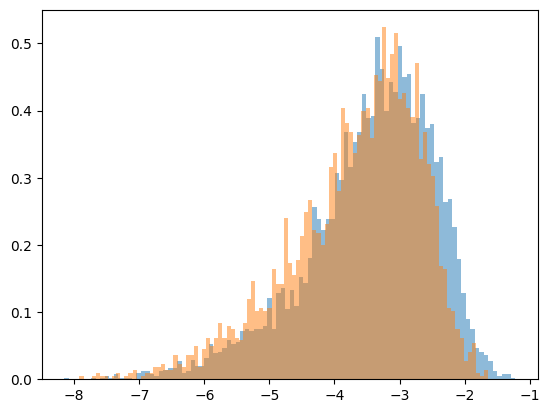

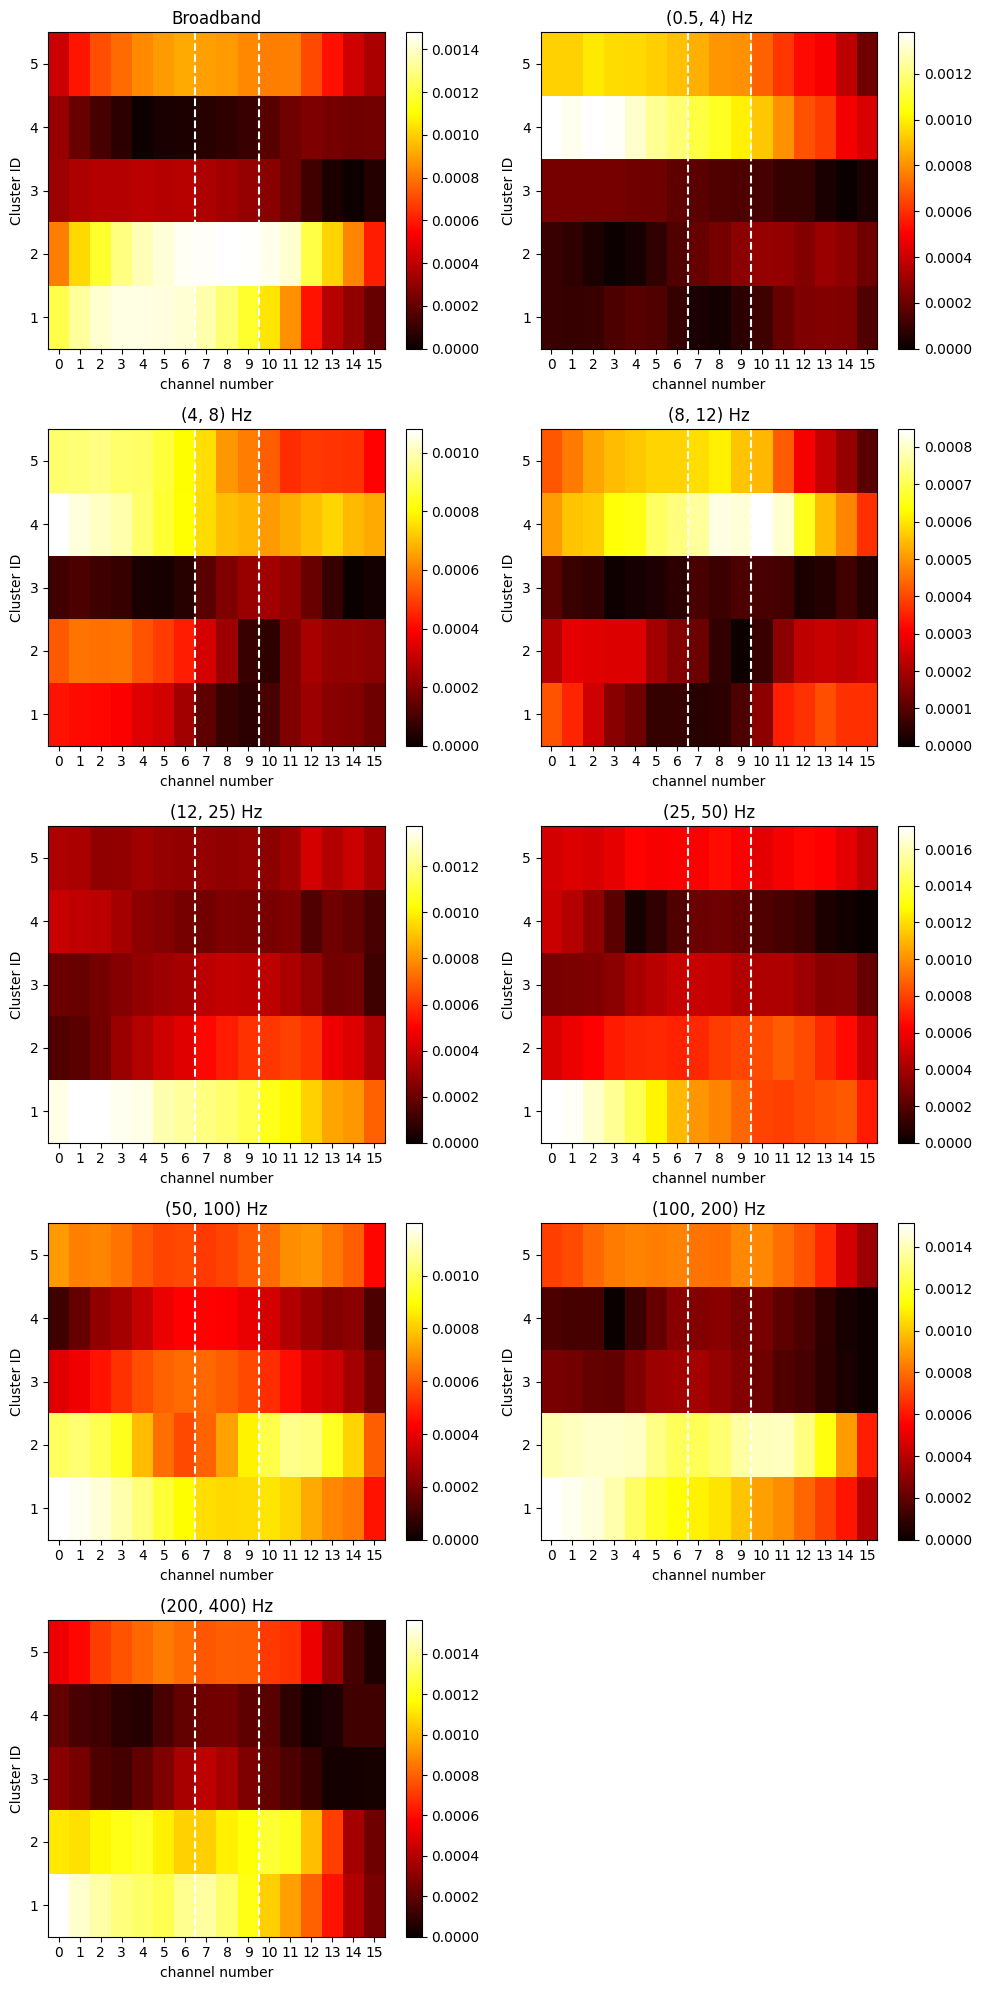

In [41]:
mean_attr_clusters = np.zeros((len(df['cluster_id'].unique()), len(bands)+1, chans2keep))

for clusteri in range(1,6):
    for bandi in range(len(bands)+1):
        for chani in range(chans2keep):
            # get the mean of the attribution scores for the cluster, channel and band, ignoring NaN values
            mean_attr_clusters[clusteri, bandi, chani] = df.loc[df['cluster_id'] == clusteri, f'attr_{chani}_{bandi}'].mean(skipna=True)
            

all_vals = df.loc[(df['cluster_id'] == 1), [f'attr_{0}_{0}']].values.ravel()
all_vals = all_vals[~np.isnan(all_vals) & ~np.isinf(all_vals)]
all_vals = np.abs(all_vals)
all_vals = all_vals[all_vals > 0]  # Remove zeros and negatives
plt.hist(np.log10(all_vals), bins=100, alpha=0.5, label='cluster 1', density=True)

all_vals = df.loc[(df['cluster_id'] == 4), [f'attr_{0}_{0}']].values.ravel()
all_vals = all_vals[~np.isnan(all_vals) & ~np.isinf(all_vals)]
all_vals = np.abs(all_vals)
all_vals = all_vals[all_vals > 0]  # Remove zeros and negatives
plt.hist(np.log10(all_vals), bins=100, alpha=0.5, label='cluster 4', density=True)

plt.show()

fig, ax = plt.subplots(int(np.ceil((len(bands)+1)/2)),2,figsize=(10,20)) 
for bandi in range(len(bands)+1):
    ax.flat[bandi].imshow( np.abs(mean_attr_clusters[:,bandi,:]) , aspect='auto',cmap='hot')
    # set the xticks to be the channel depths
    ax.flat[bandi].set_xticks(range(chans2keep))
    ax.flat[bandi].set_xlabel('channel number')
    ax.flat[bandi].set_ylim([.5,5.5])
    if bandi == 0:
        ax.flat[bandi].set_title('Broadband')
    else:
        ax.flat[bandi].set_title(str(bands[bandi-1]) + ' Hz')
    # set the yticks to be the cluster ids
    ax.flat[bandi].set_yticks(range(1,6,1))
    ax.flat[bandi].set_yticklabels(range(1,6,1))
    ax.flat[bandi].set_ylabel('Cluster ID')
    ax.flat[bandi].axvline(x=6.5, color='w', linestyle='--')
    ax.flat[bandi].axvline(x=9.5, color='w', linestyle='--')
    cbar = fig.colorbar(ax.flat[bandi].imshow(np.abs(mean_attr_clusters[:,bandi,:]), aspect='auto', cmap='hot'), ax=ax.flat[bandi])

plt.tight_layout()
fig.delaxes(ax.flat[-1])
plt.savefig(Path(figures_folder) / 'mean_attribution_scores_across_clusters_channels_bands.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Correlation with hierarchy score

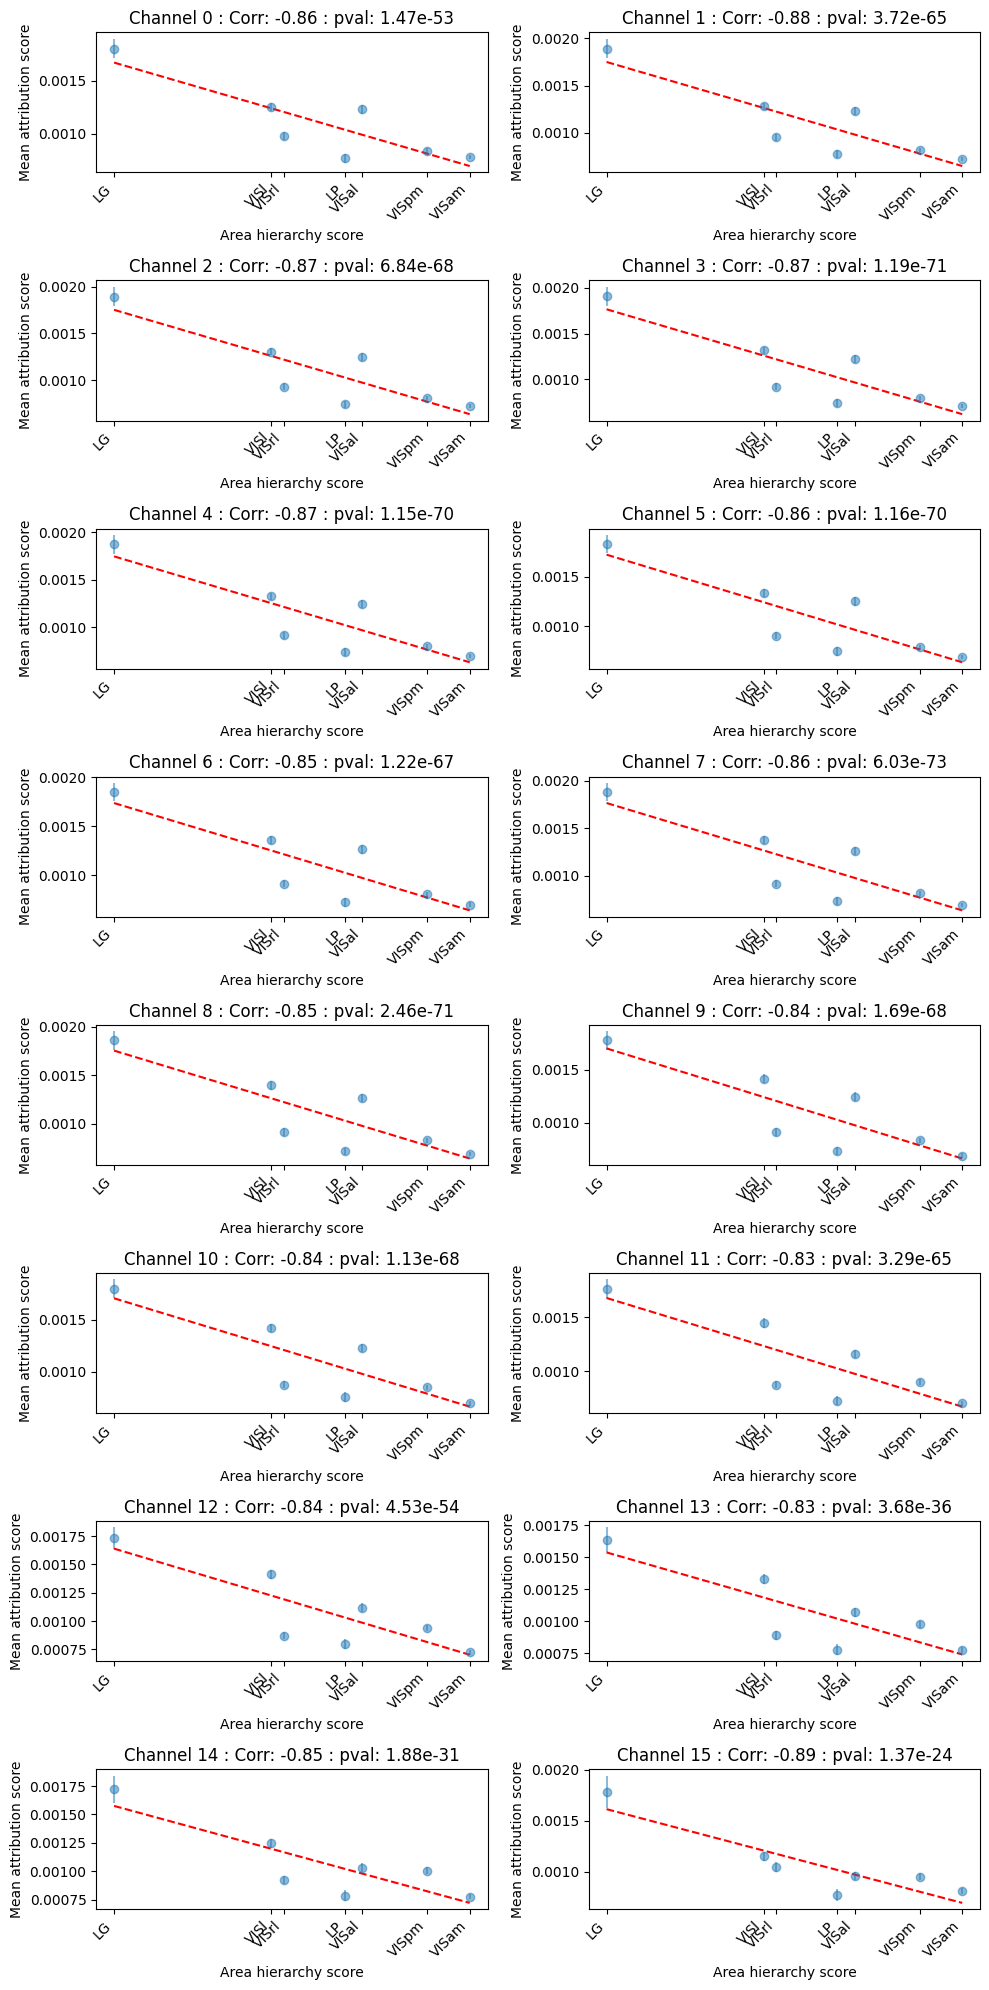

In [43]:
from scipy.stats import pearsonr

hierarchy_score = {'LG' : -0.515,
                #    'VISp' : -0.357,
                   'VISl' : -0.093,
                   'VISrl' : -0.059,
                   'LP' : 0.105,
                   'VISal' : 0.152,
                   'VISpm' : 0.327,
                   'VISam' : 0.441}

bandi = 0
# for each area in hierarchy_score, calculate the average attribution score plus the standard deviation
area_vals = {}
for area in hierarchy_score.keys():
    num_units_in_area = (df['structure_acronym'] == area).sum()
    area_vals[area] = np.zeros((chans2keep, num_units_in_area))
    for chani in range(chans2keep):
        area_vals[area][chani, :] = df.loc[df['structure_acronym'] == area, f'attr_{chani}_{bandi}'].values

# Compute mean and SEM for each area and channel
area_mean = np.zeros((chans2keep, len(hierarchy_score)))
area_sem  = np.zeros((chans2keep, len(hierarchy_score)))
for i, area in enumerate(hierarchy_score.keys()):
    for chani in range(chans2keep):
        vals = np.abs(area_vals[area][chani, :])
        area_mean[chani, i] = np.nanmean(vals)
        area_sem[chani, i]  = np.nanstd(vals) / np.sqrt(np.sum(~np.isnan(vals)))

fig, ax = plt.subplots(int(chans2keep/2), 2, figsize=(10, 20))
for chani in range(chans2keep):
    ax.flat[chani].errorbar(list(hierarchy_score.values()), area_mean[chani, :], 
                            yerr=area_sem[chani, :], fmt='o', alpha=0.5)
    # add a linear fit line
    slope, intercept = np.polyfit(list(hierarchy_score.values()), area_mean[chani, :], 1)
    x_fit = np.linspace(min(hierarchy_score.values()), max(hierarchy_score.values()), 100)
    y_fit = slope * x_fit + intercept
    # add a correlation coefficient to the plot using all the data points not just the mean, by concatenating the area_mean[chani, :] and hierarchy_score.values()
    vals = []
    scores = []
    for area in hierarchy_score.keys():
        tmp = np.abs(area_vals[area][chani, :])
        vals.append(tmp[~np.isnan(tmp)])
        scores.append(hierarchy_score[area] * np.ones(len(tmp[~np.isnan(tmp)])))
    corr , pval = pearsonr(np.concatenate(vals), np.concatenate(scores))
    # add a correlation of the mean
    mean_corr = np.corrcoef(area_mean[chani, :], list(hierarchy_score.values()))[0, 1]
    
    ax.flat[chani].plot(x_fit, y_fit, color='red', linestyle='--', label=f'R2: {r2_score(area_mean[chani, :], slope * np.array(list(hierarchy_score.values())) + intercept):.2f}')
    ax.flat[chani].set_xlabel('Area hierarchy score')
    ax.flat[chani].set_title(f'Channel {chani}' + f' : Corr: {mean_corr:.2f}' + f' : pval: {pval:.2e}')
    ax.flat[chani].set_xticks(list(hierarchy_score.values()), list(hierarchy_score.keys()), rotation=45, ha='right')
    ax.flat[chani].set_ylabel('Mean attribution score')
plt.tight_layout()
plt.savefig(Path(figures_folder) / 'attribution_scores_vs_hierarchy_score_across_channels.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Investigate correlations between attribution and various metrics

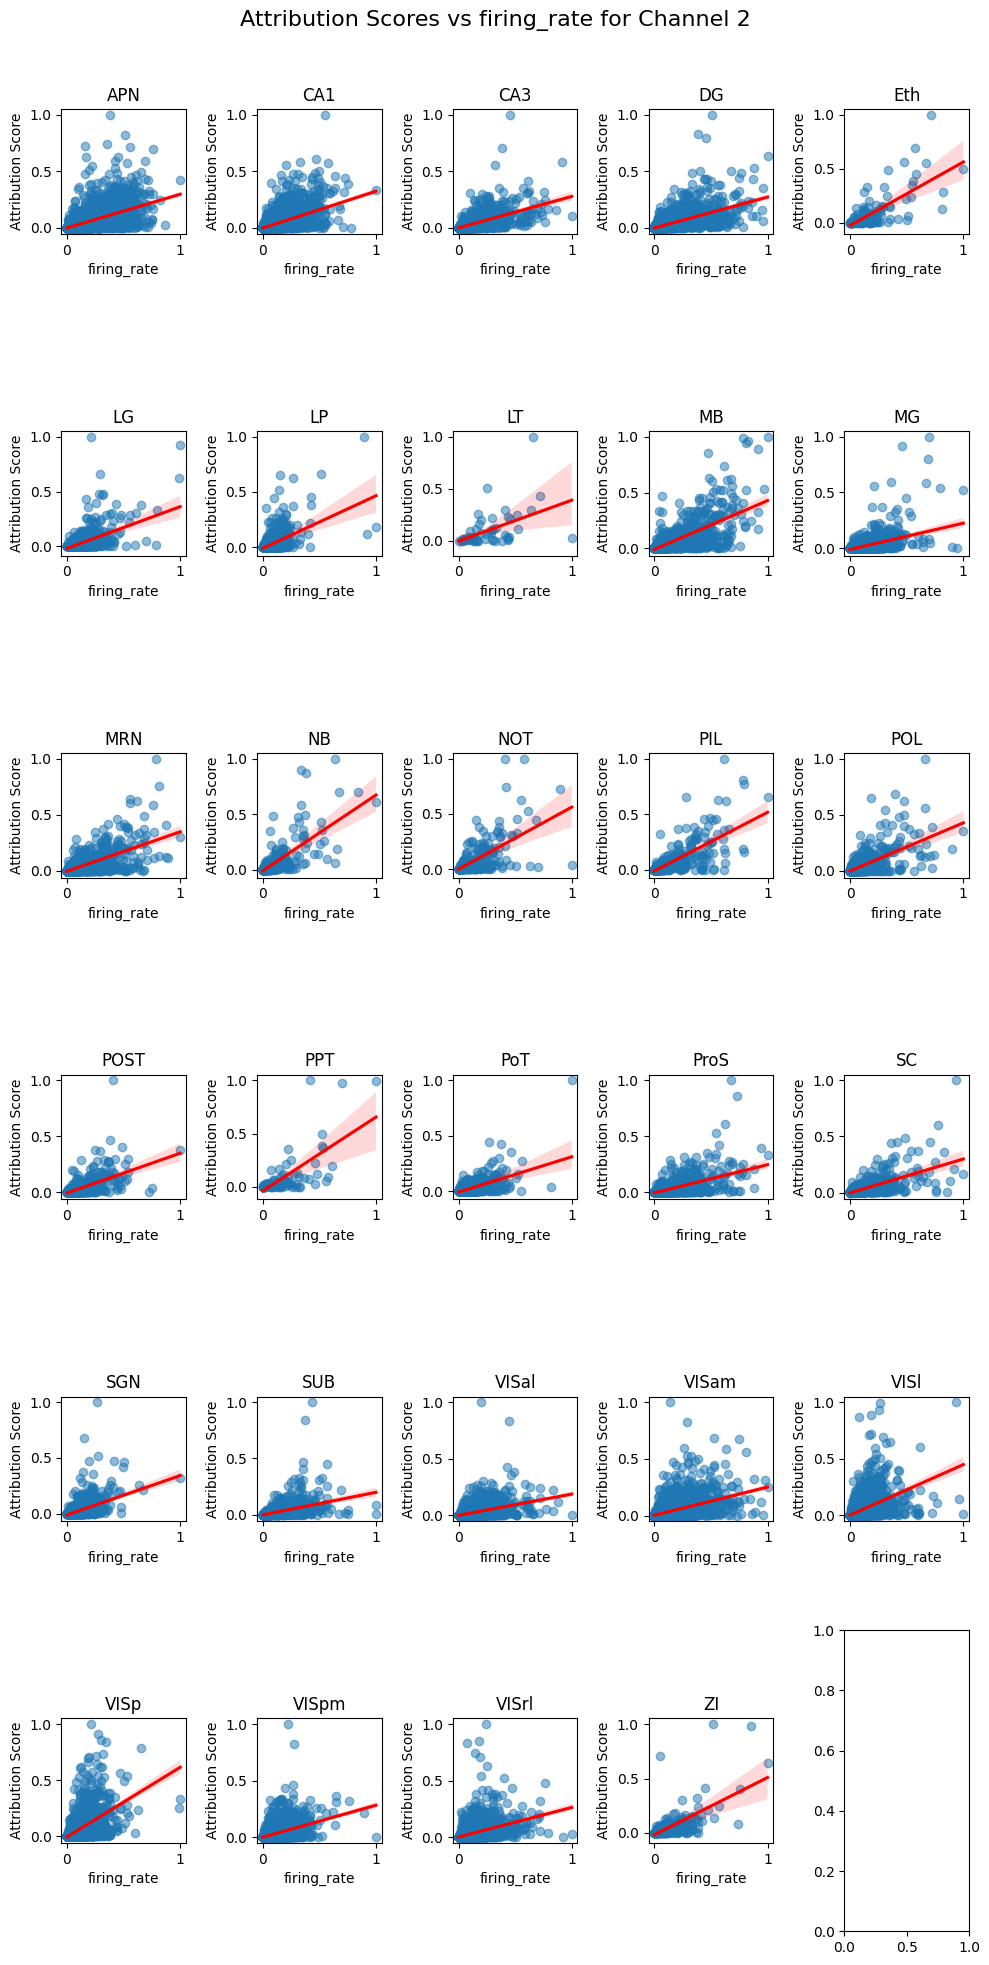

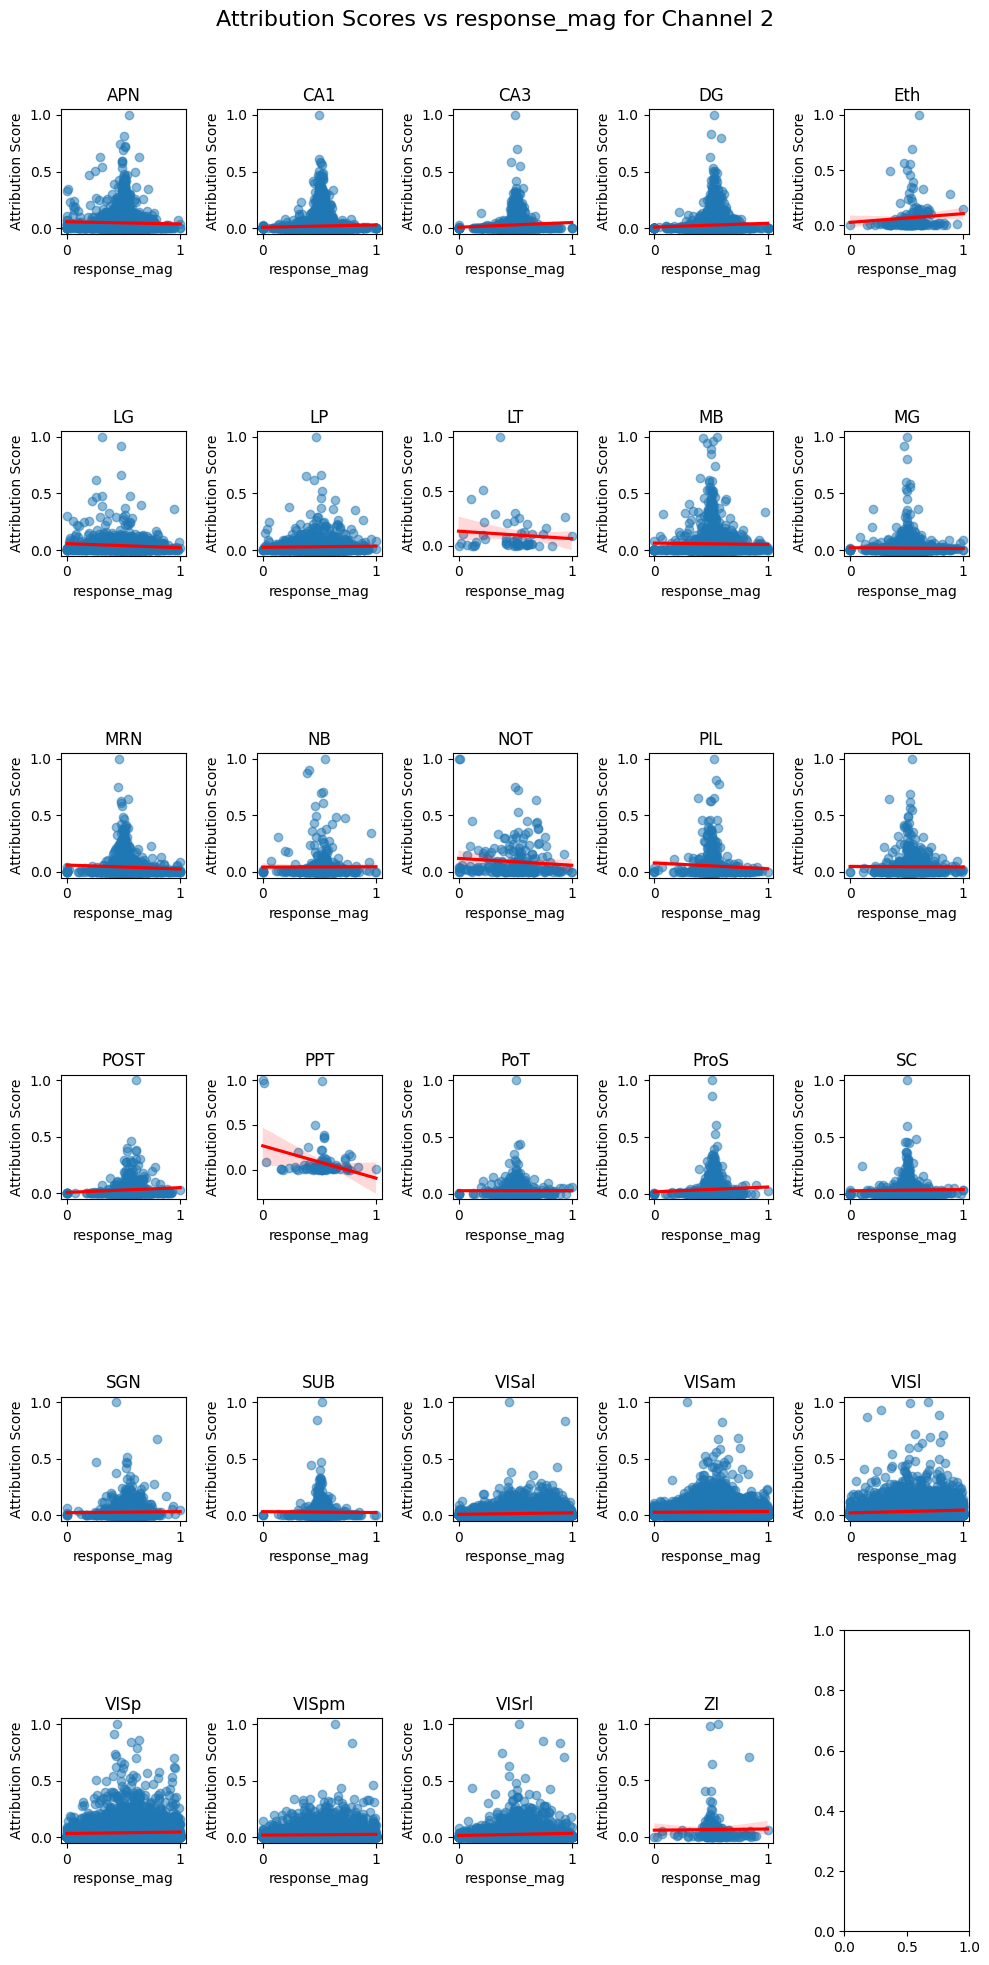

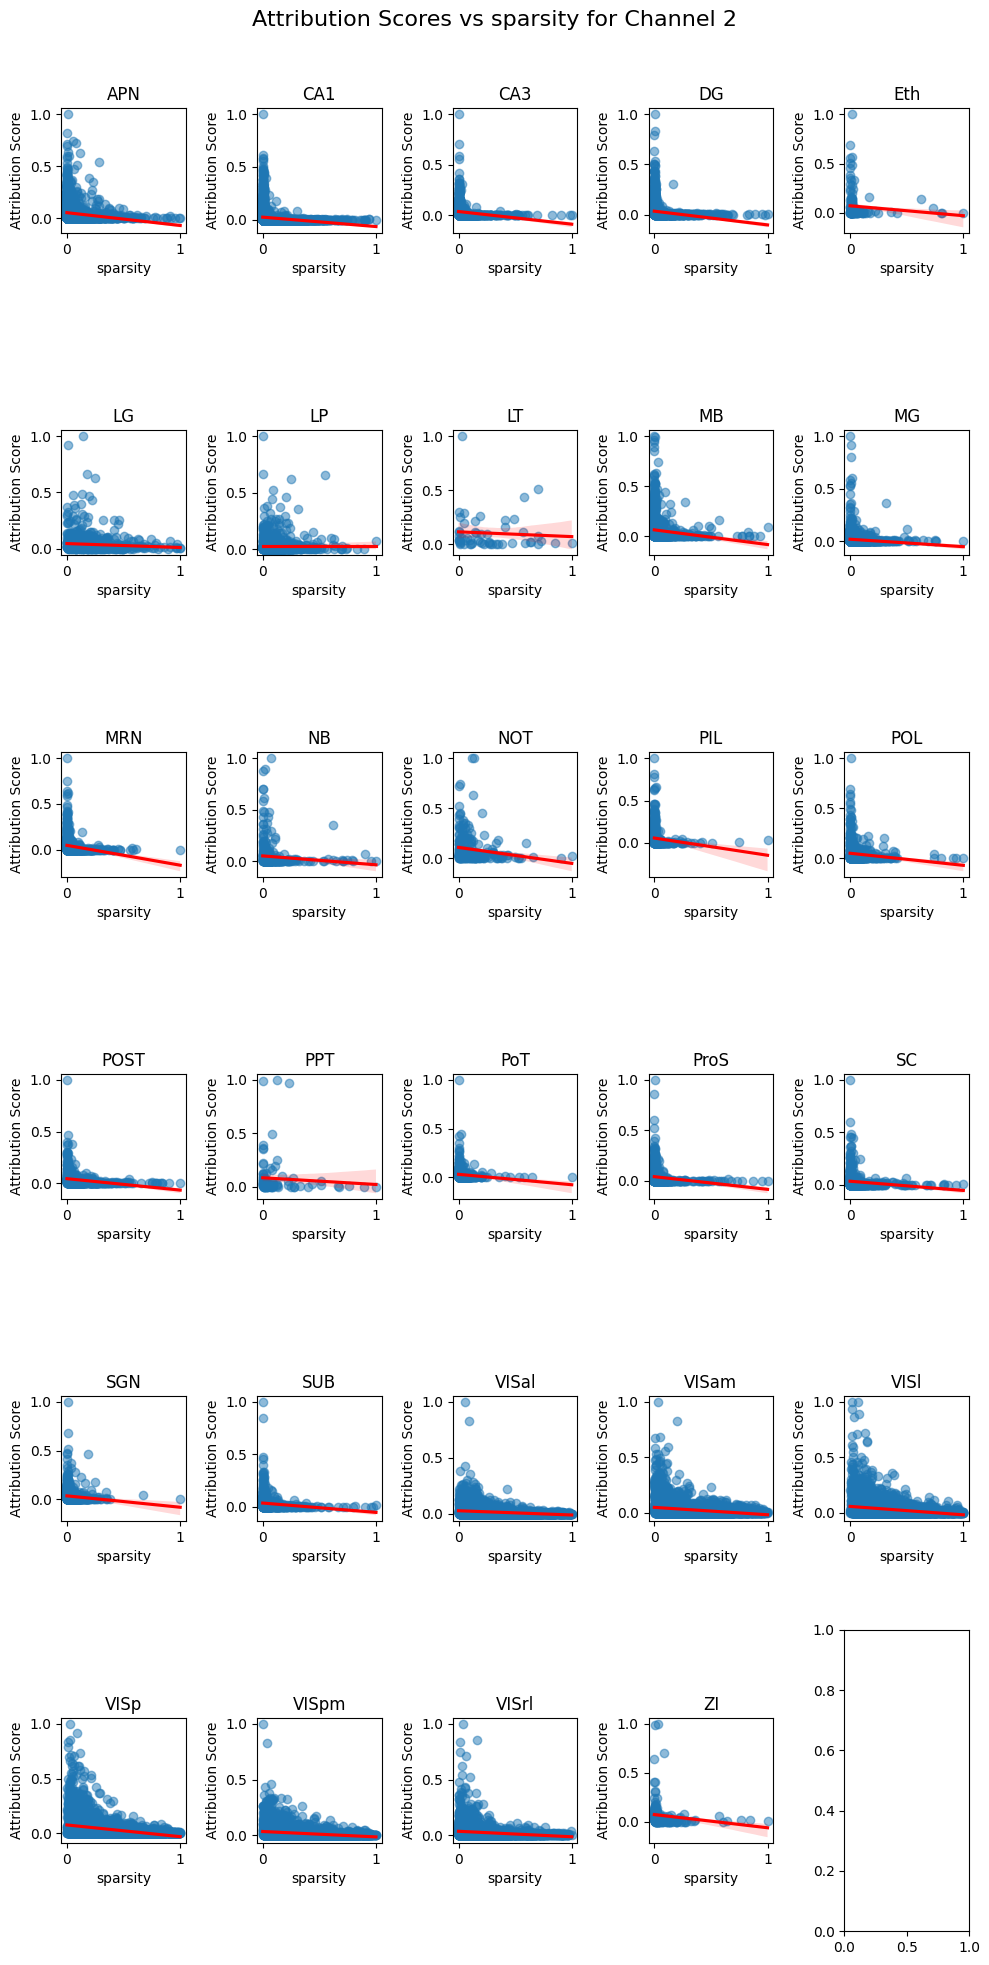

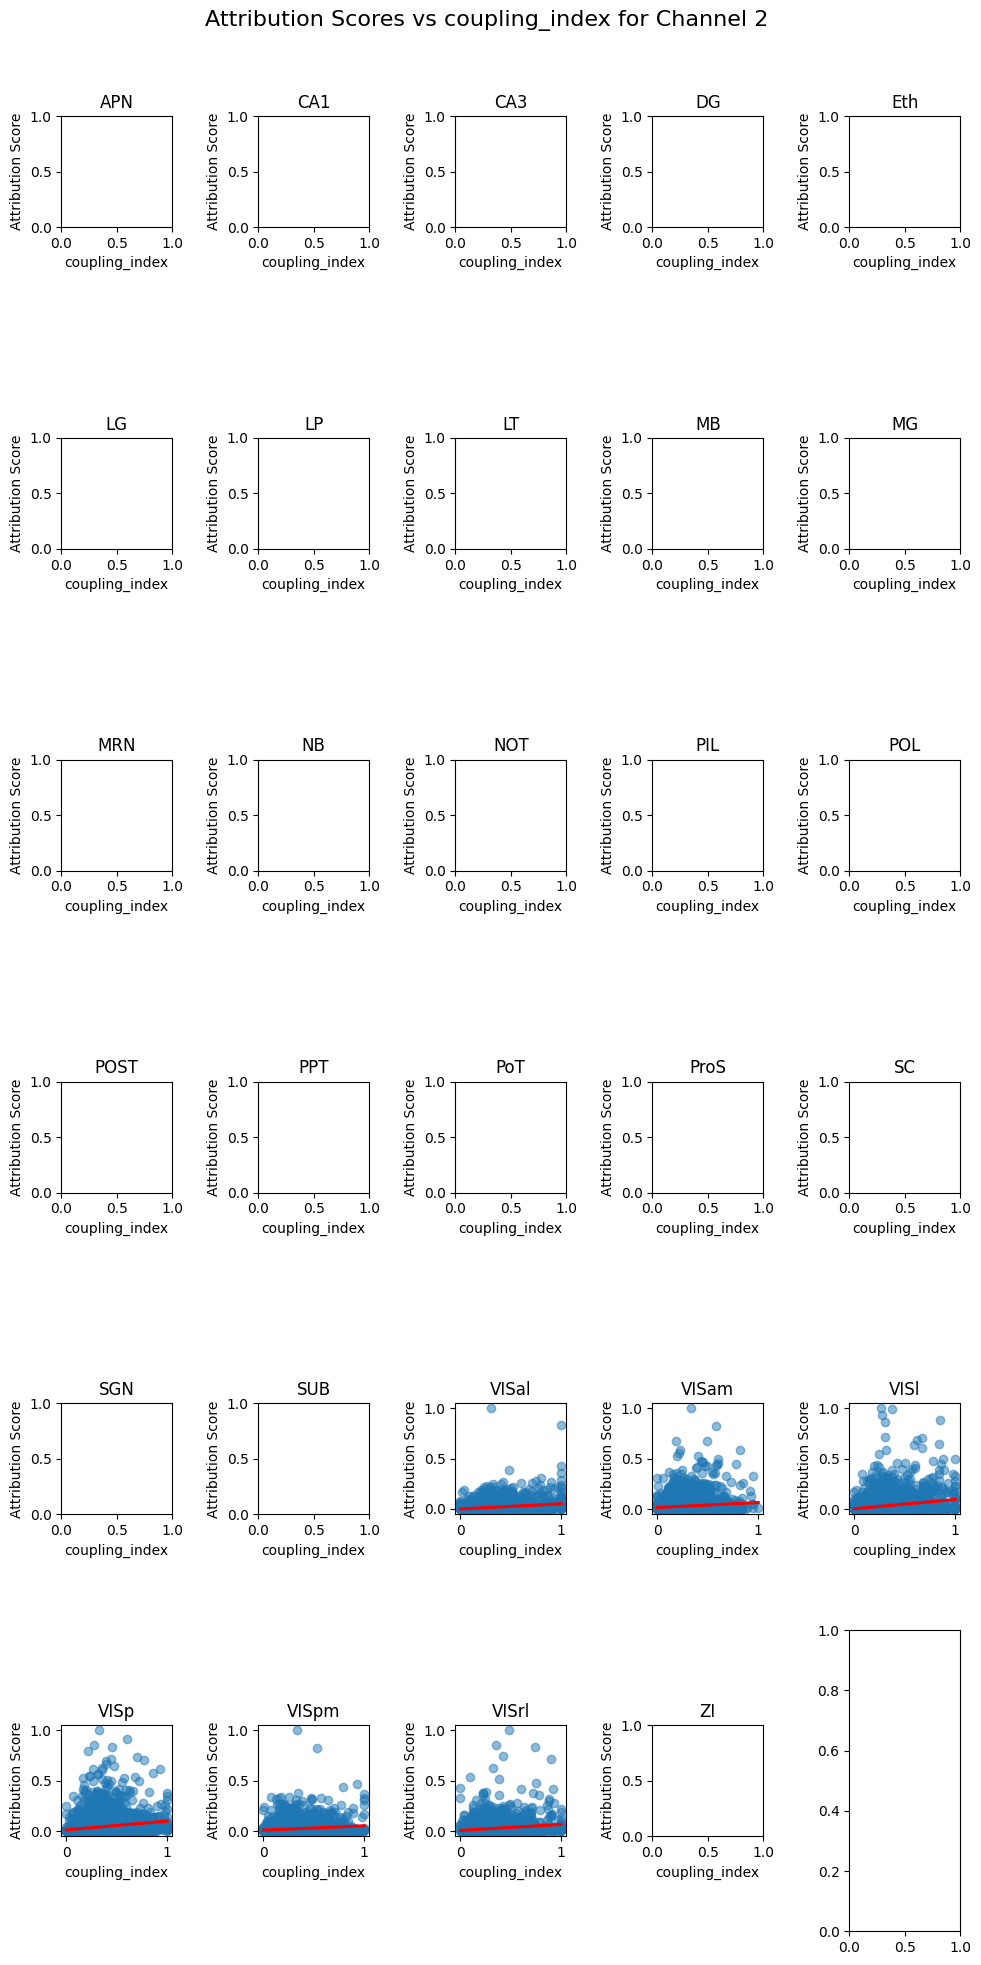

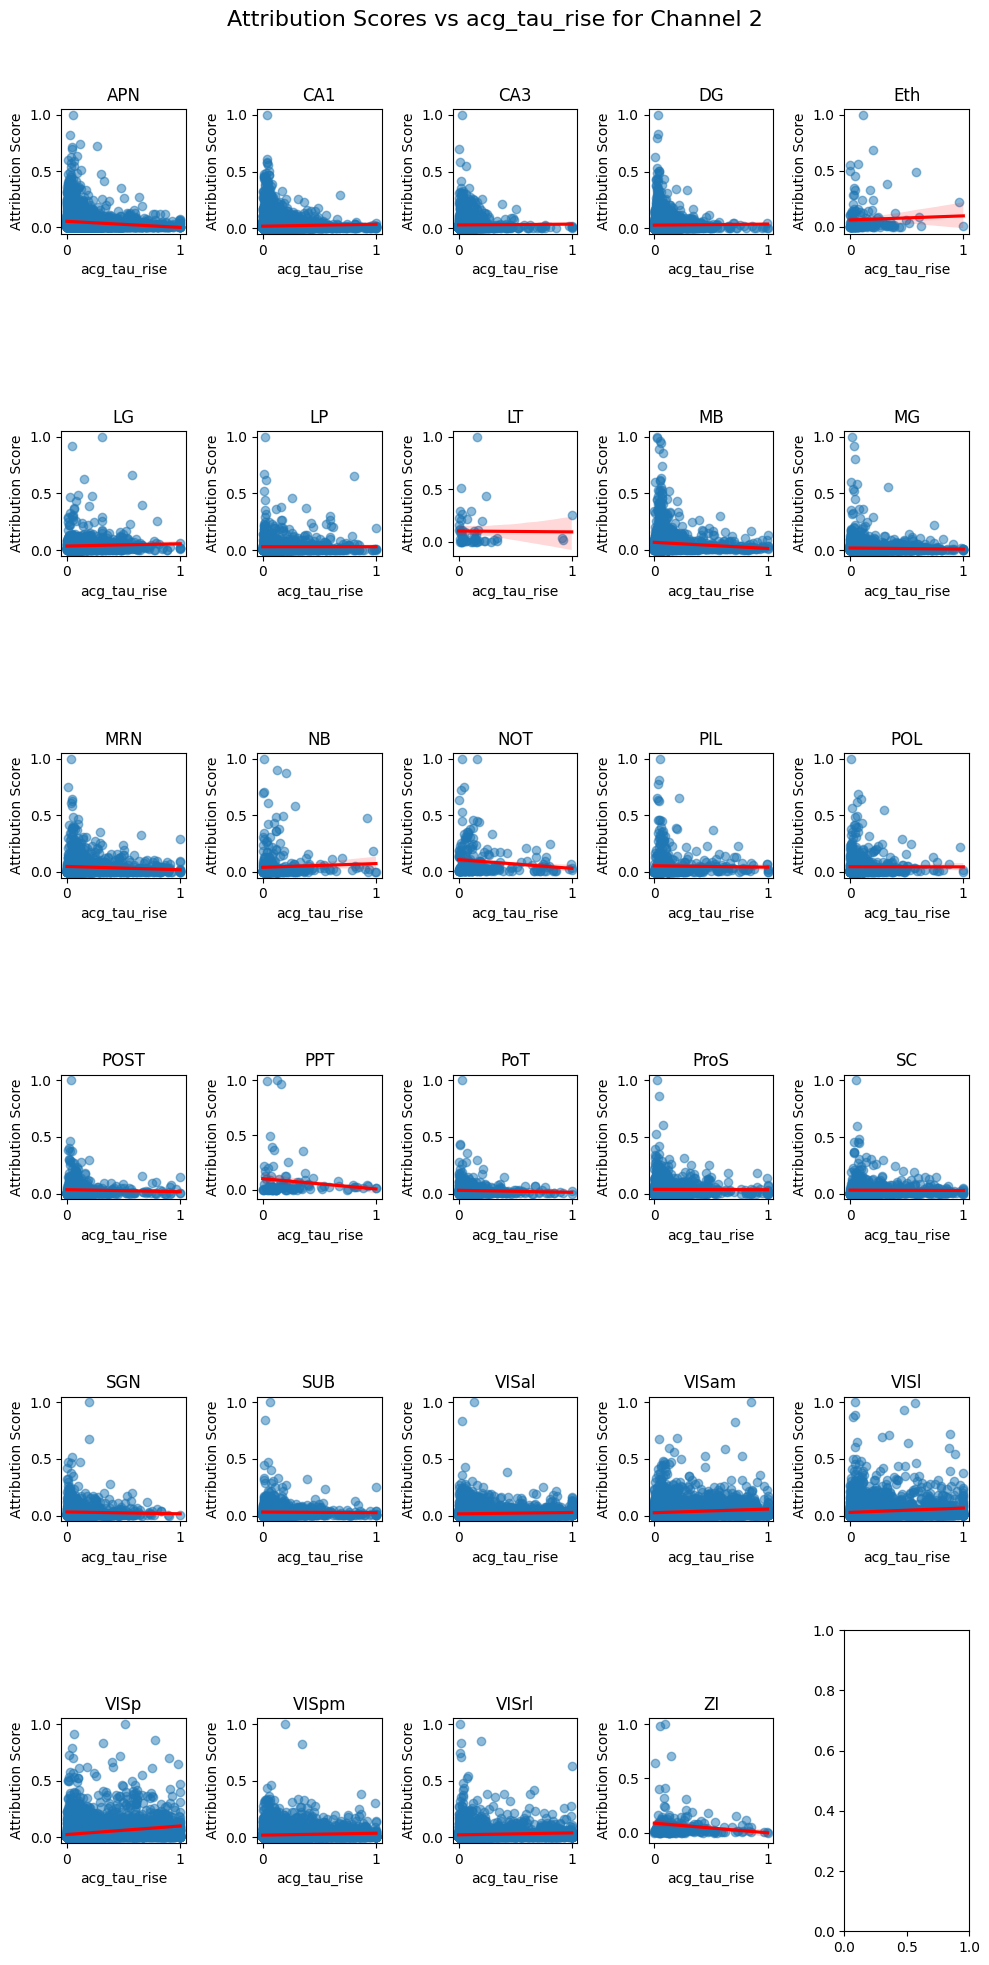

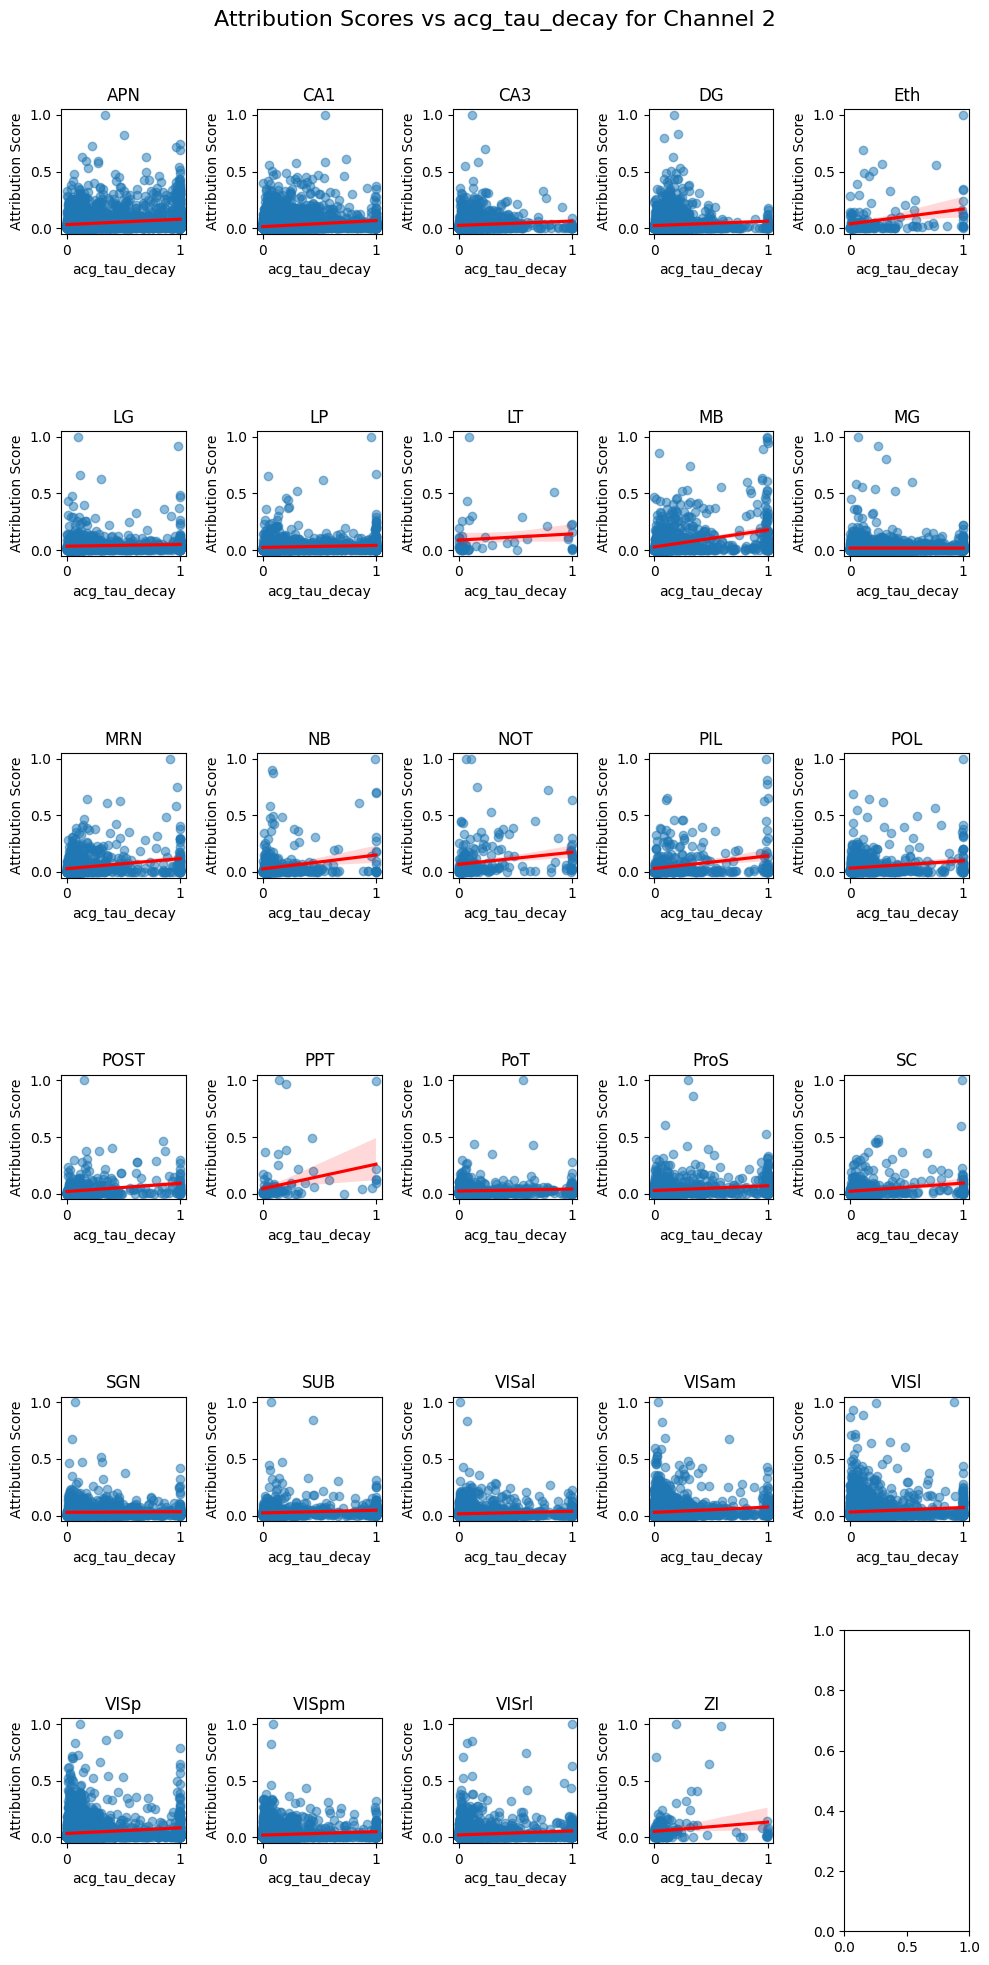

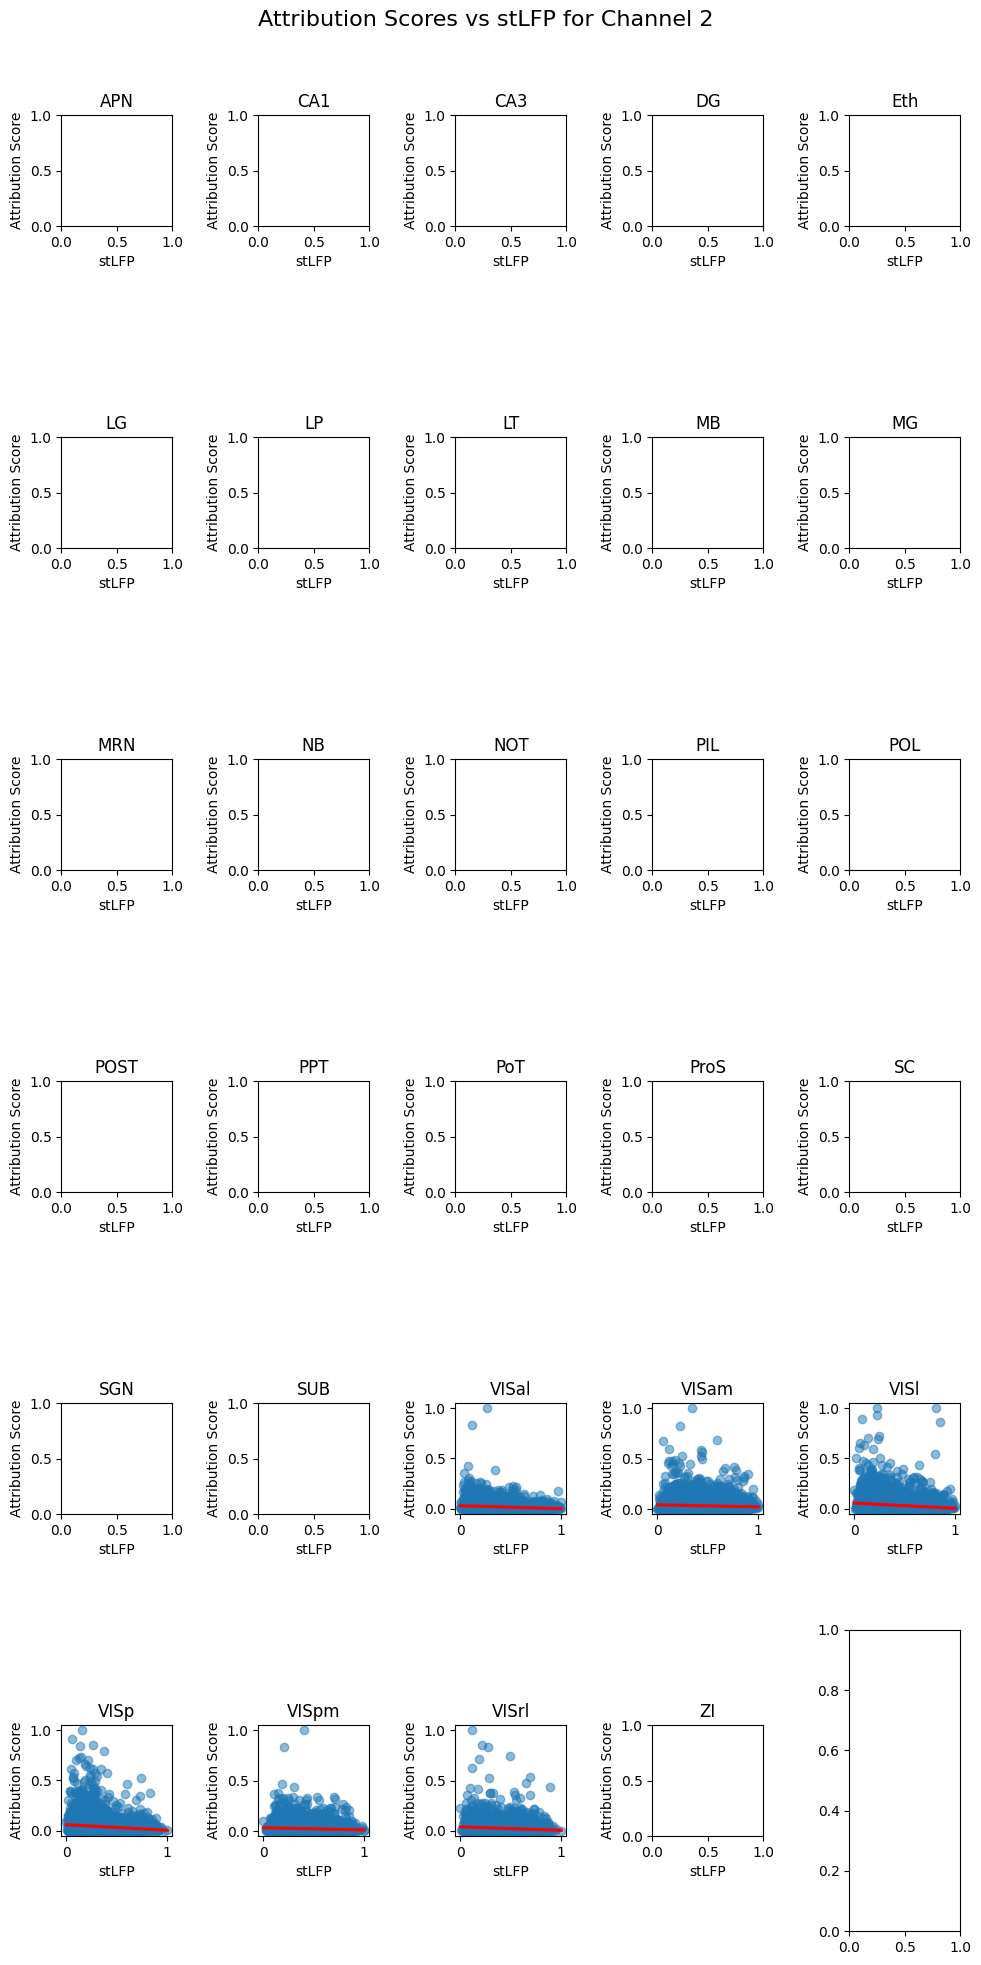

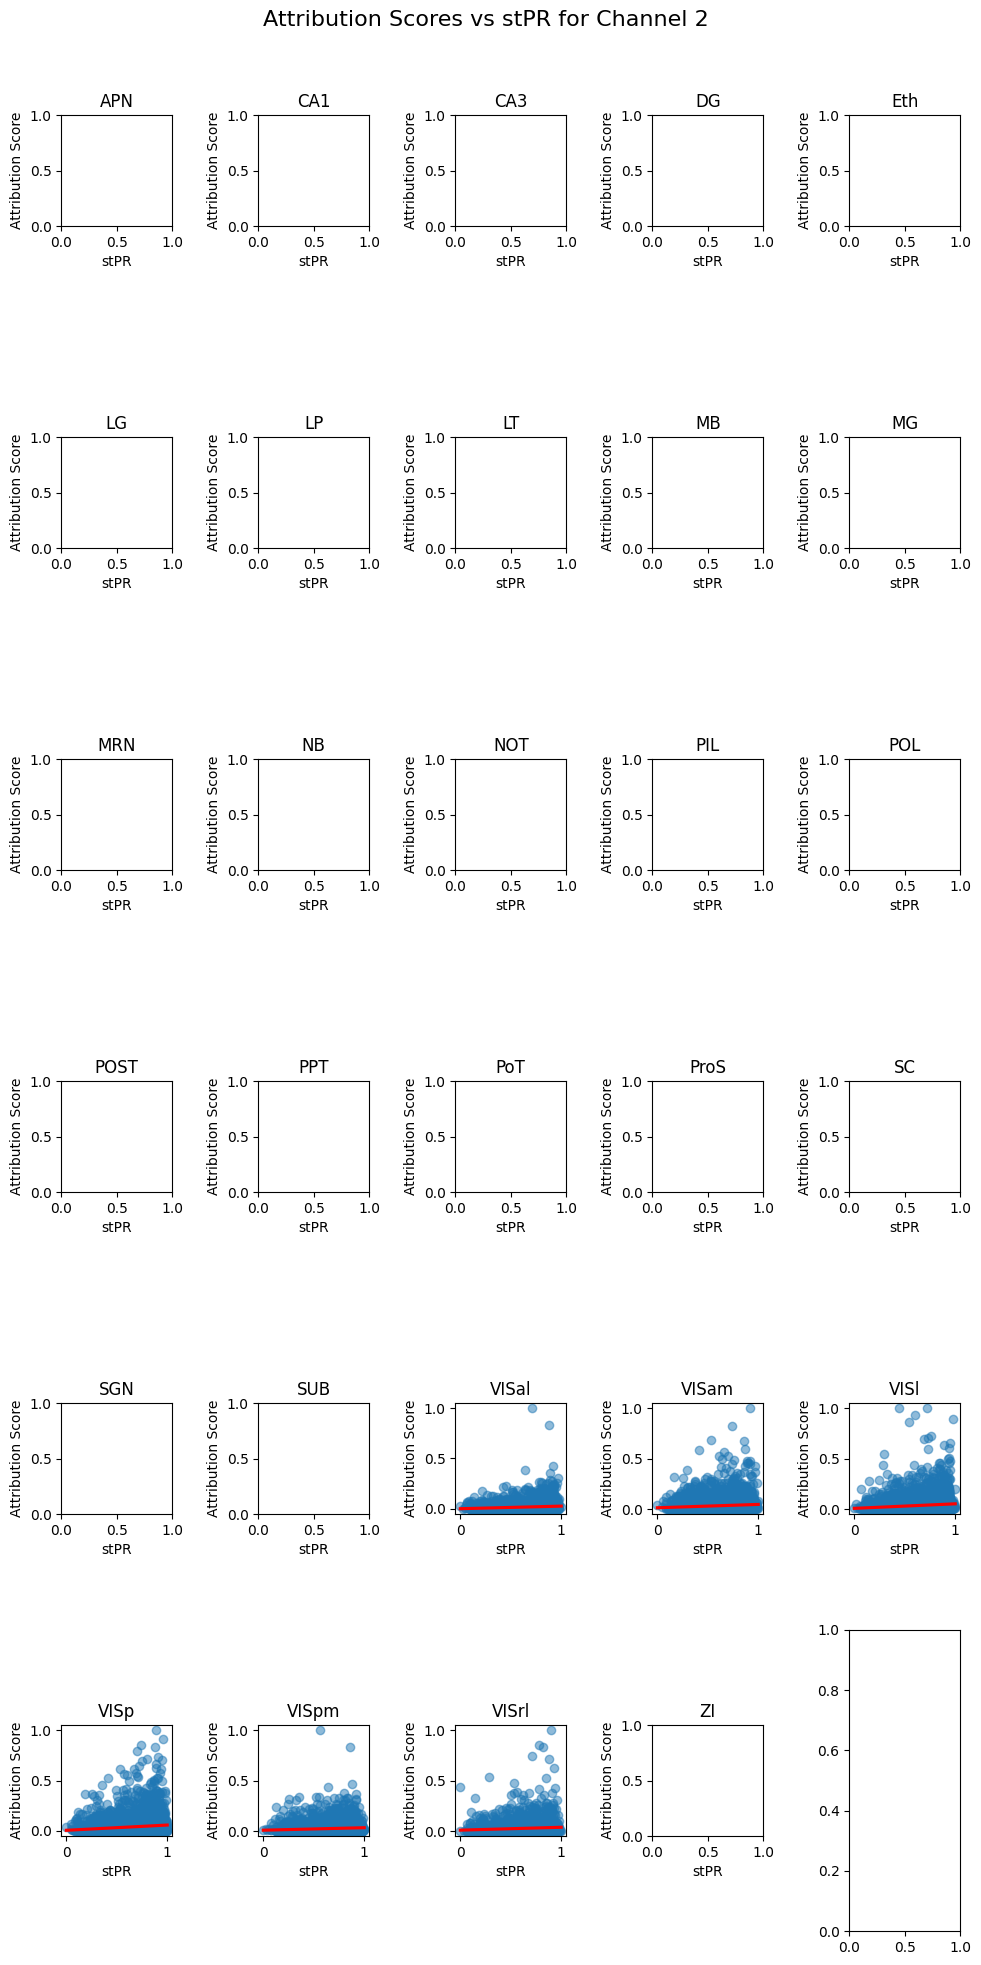

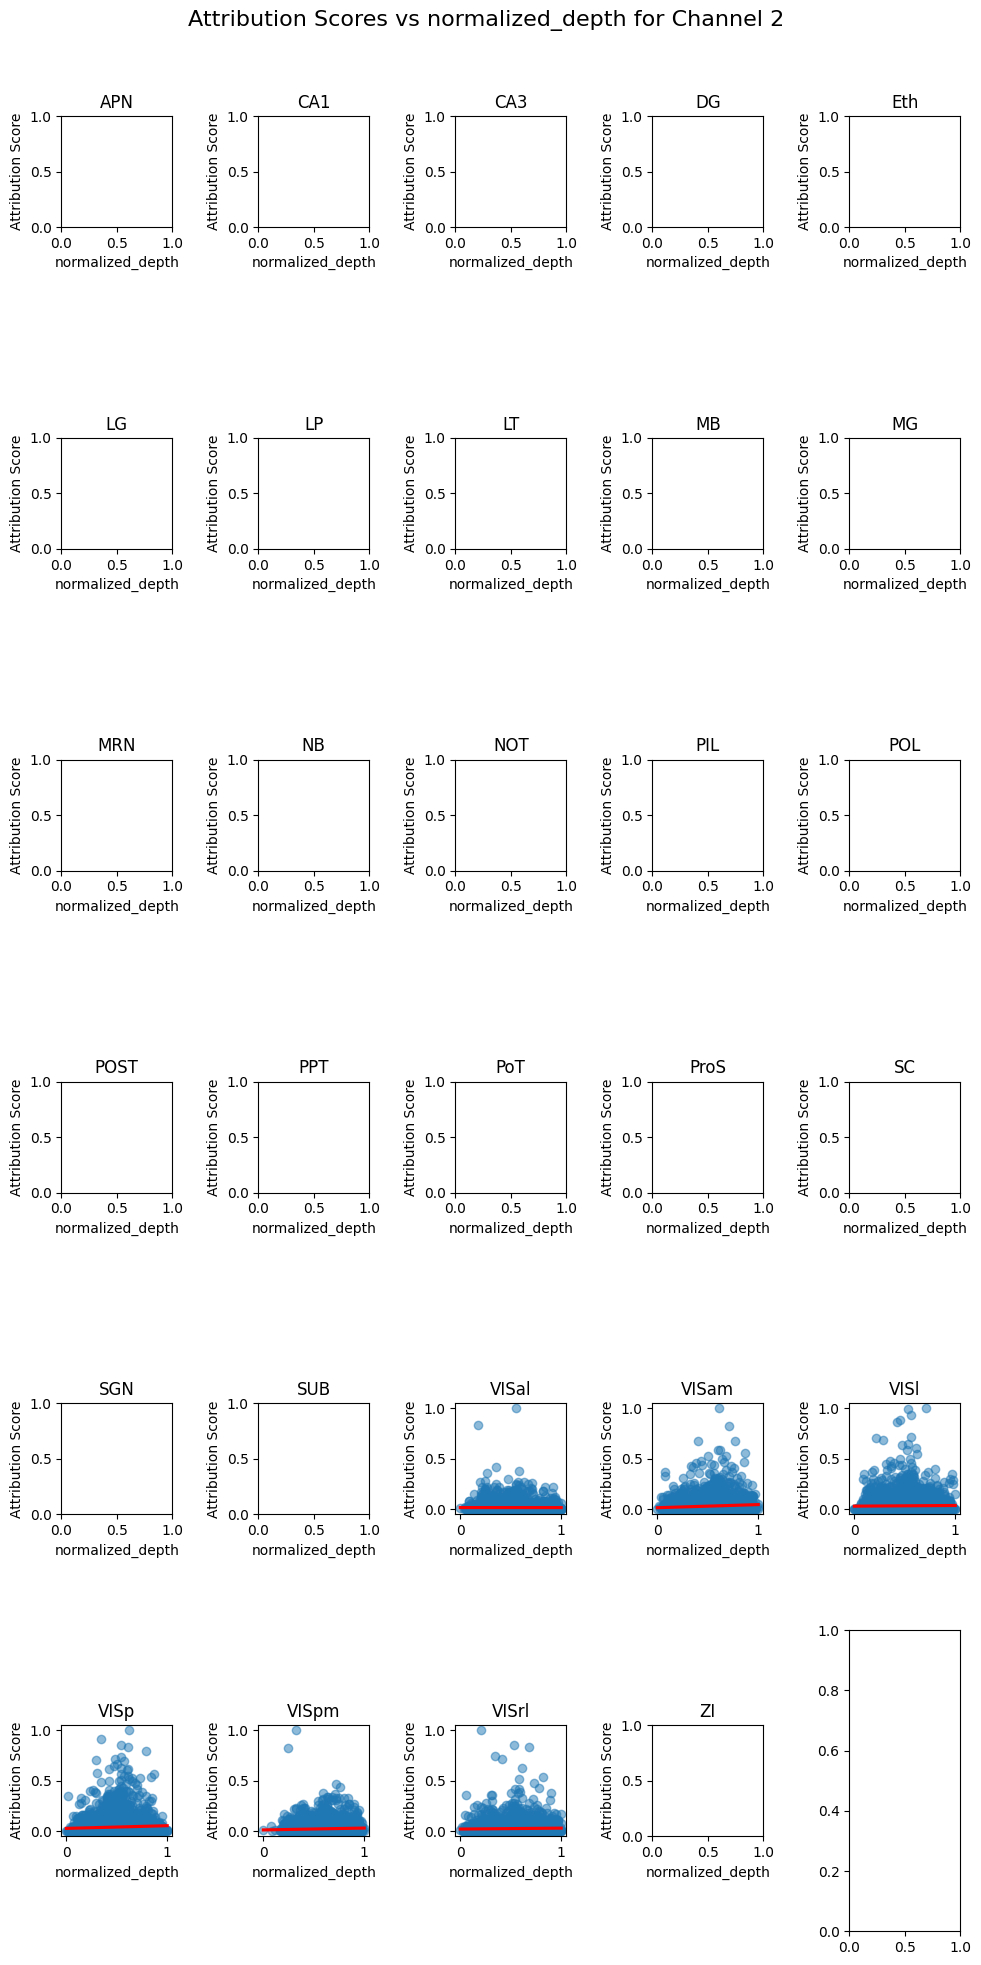

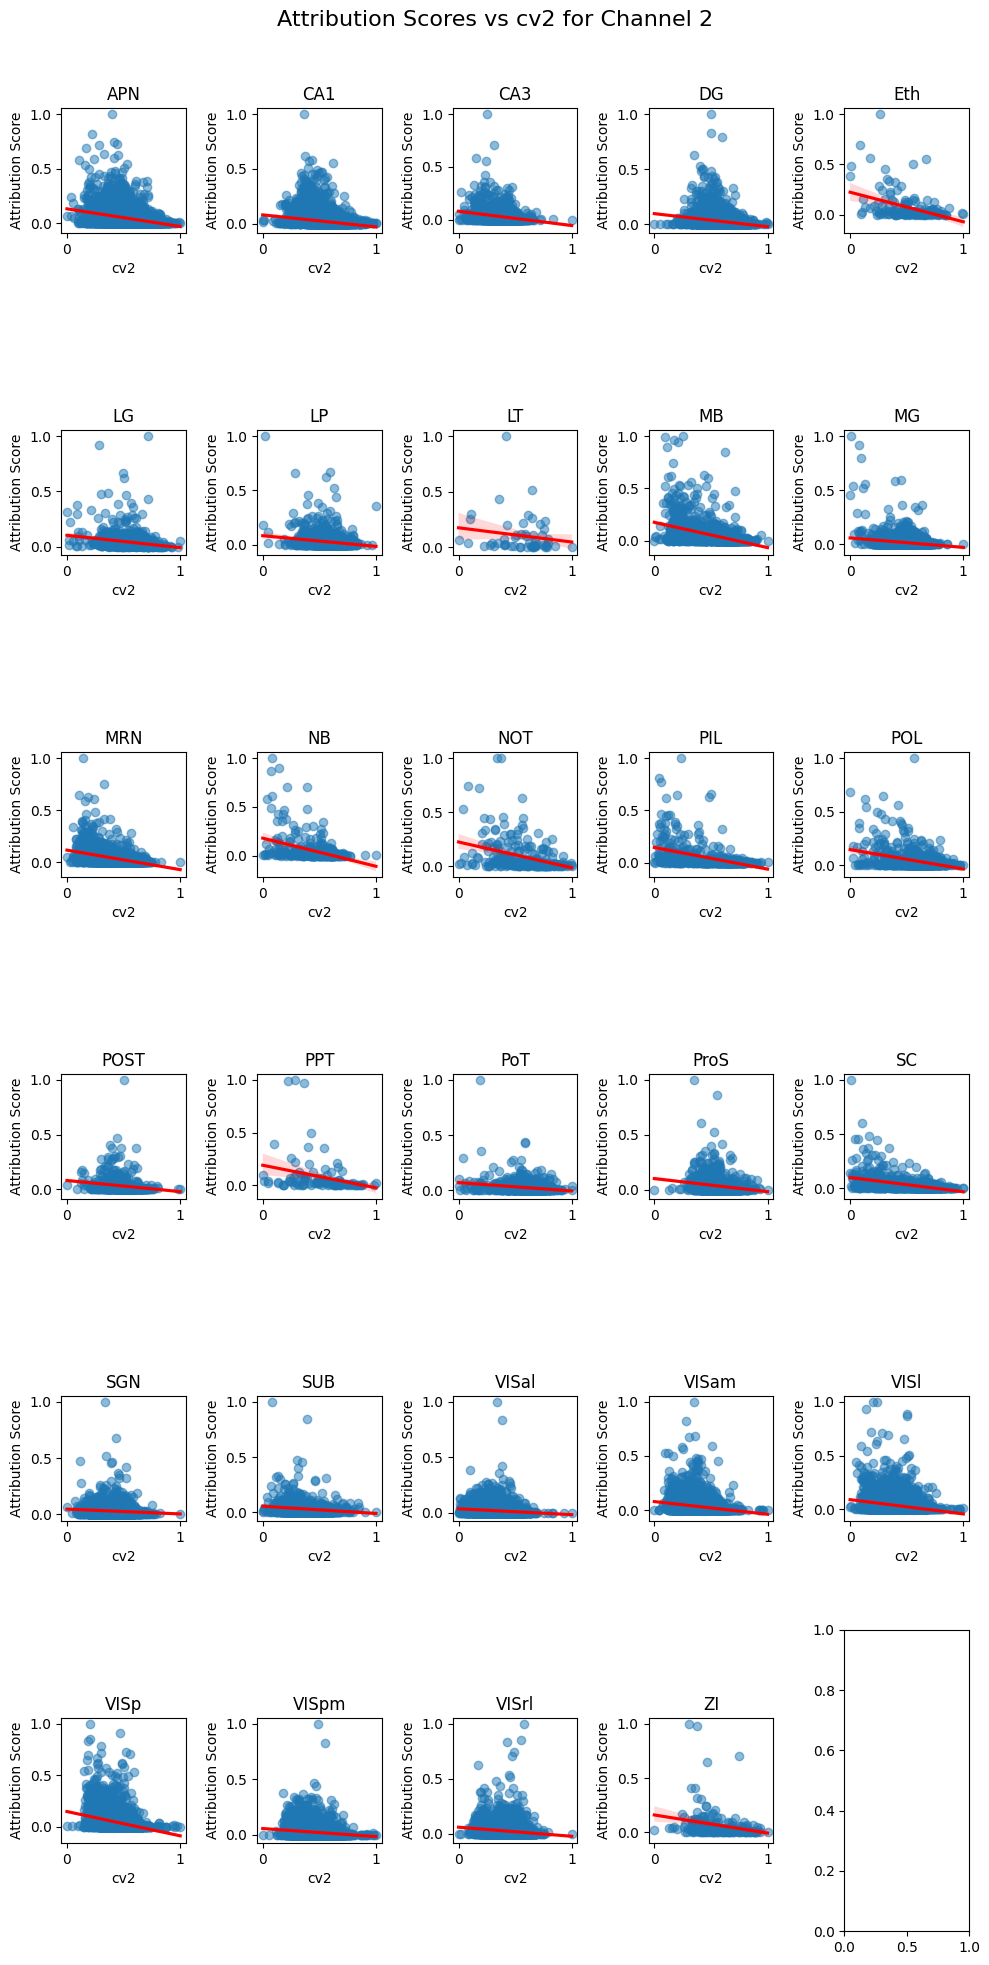

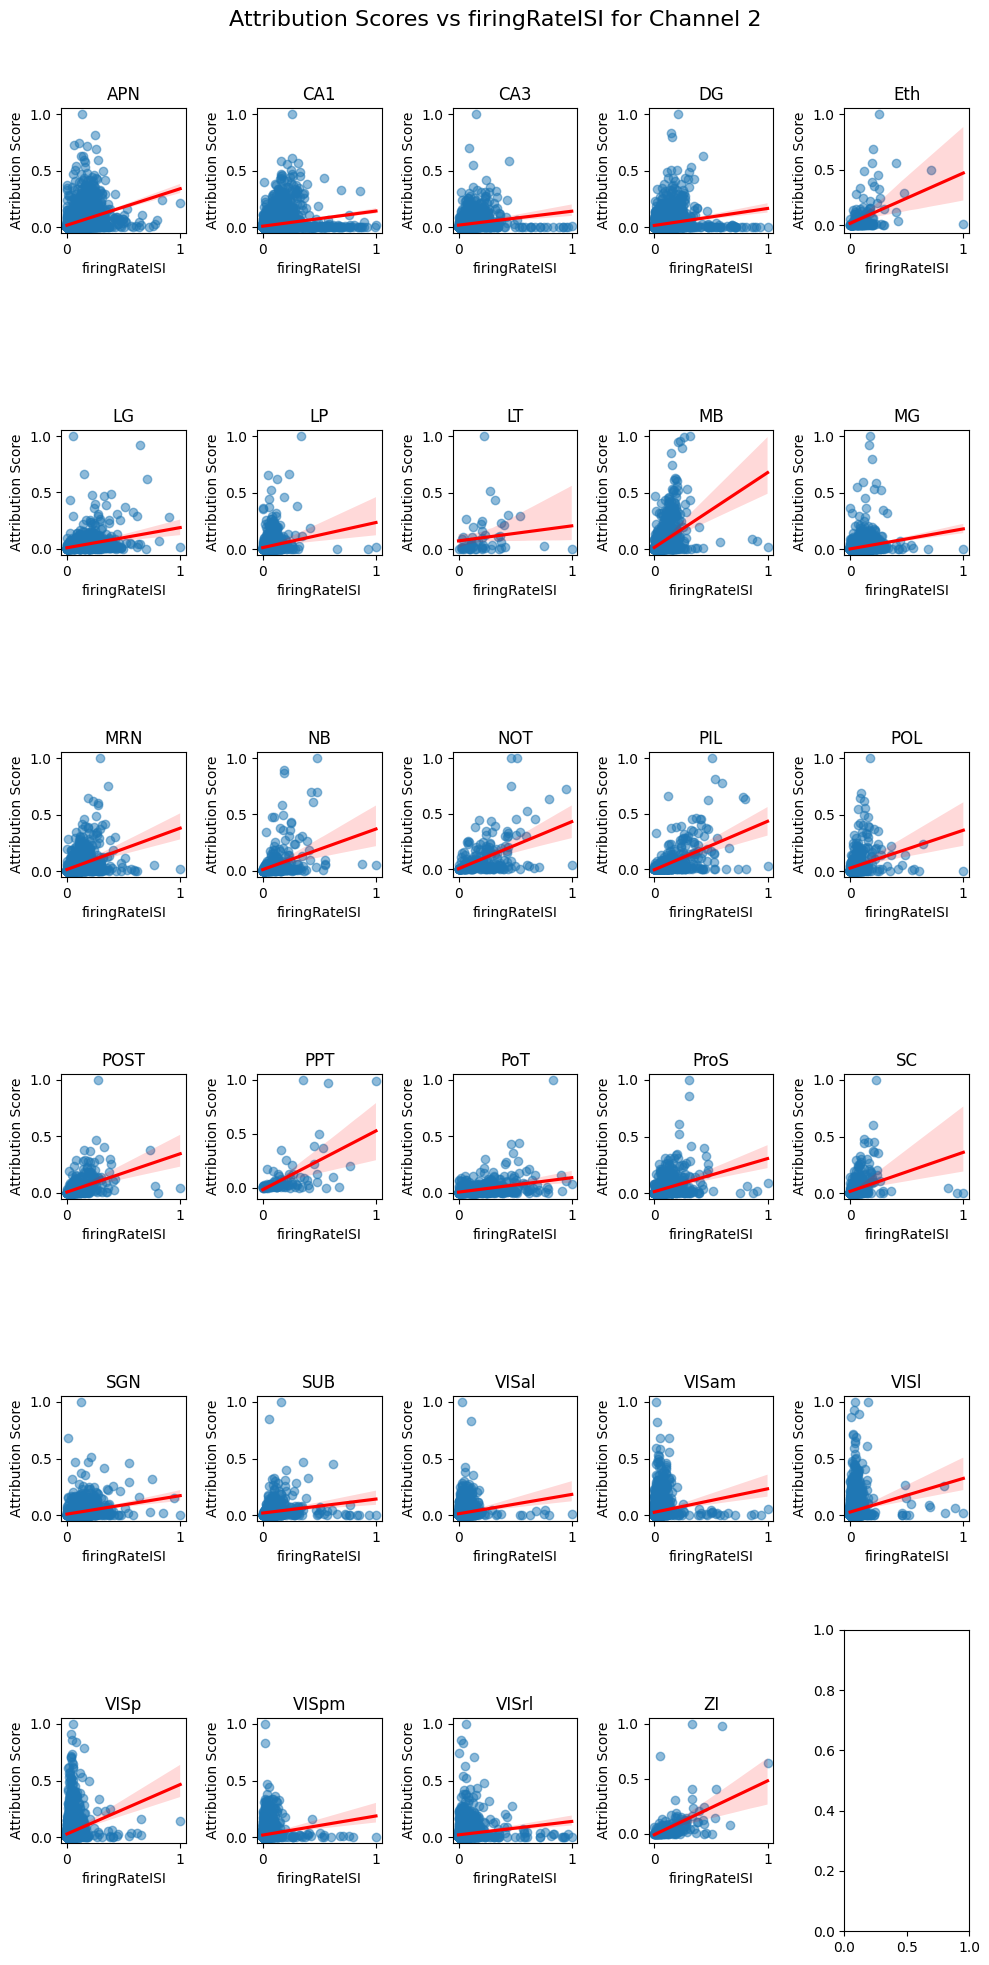

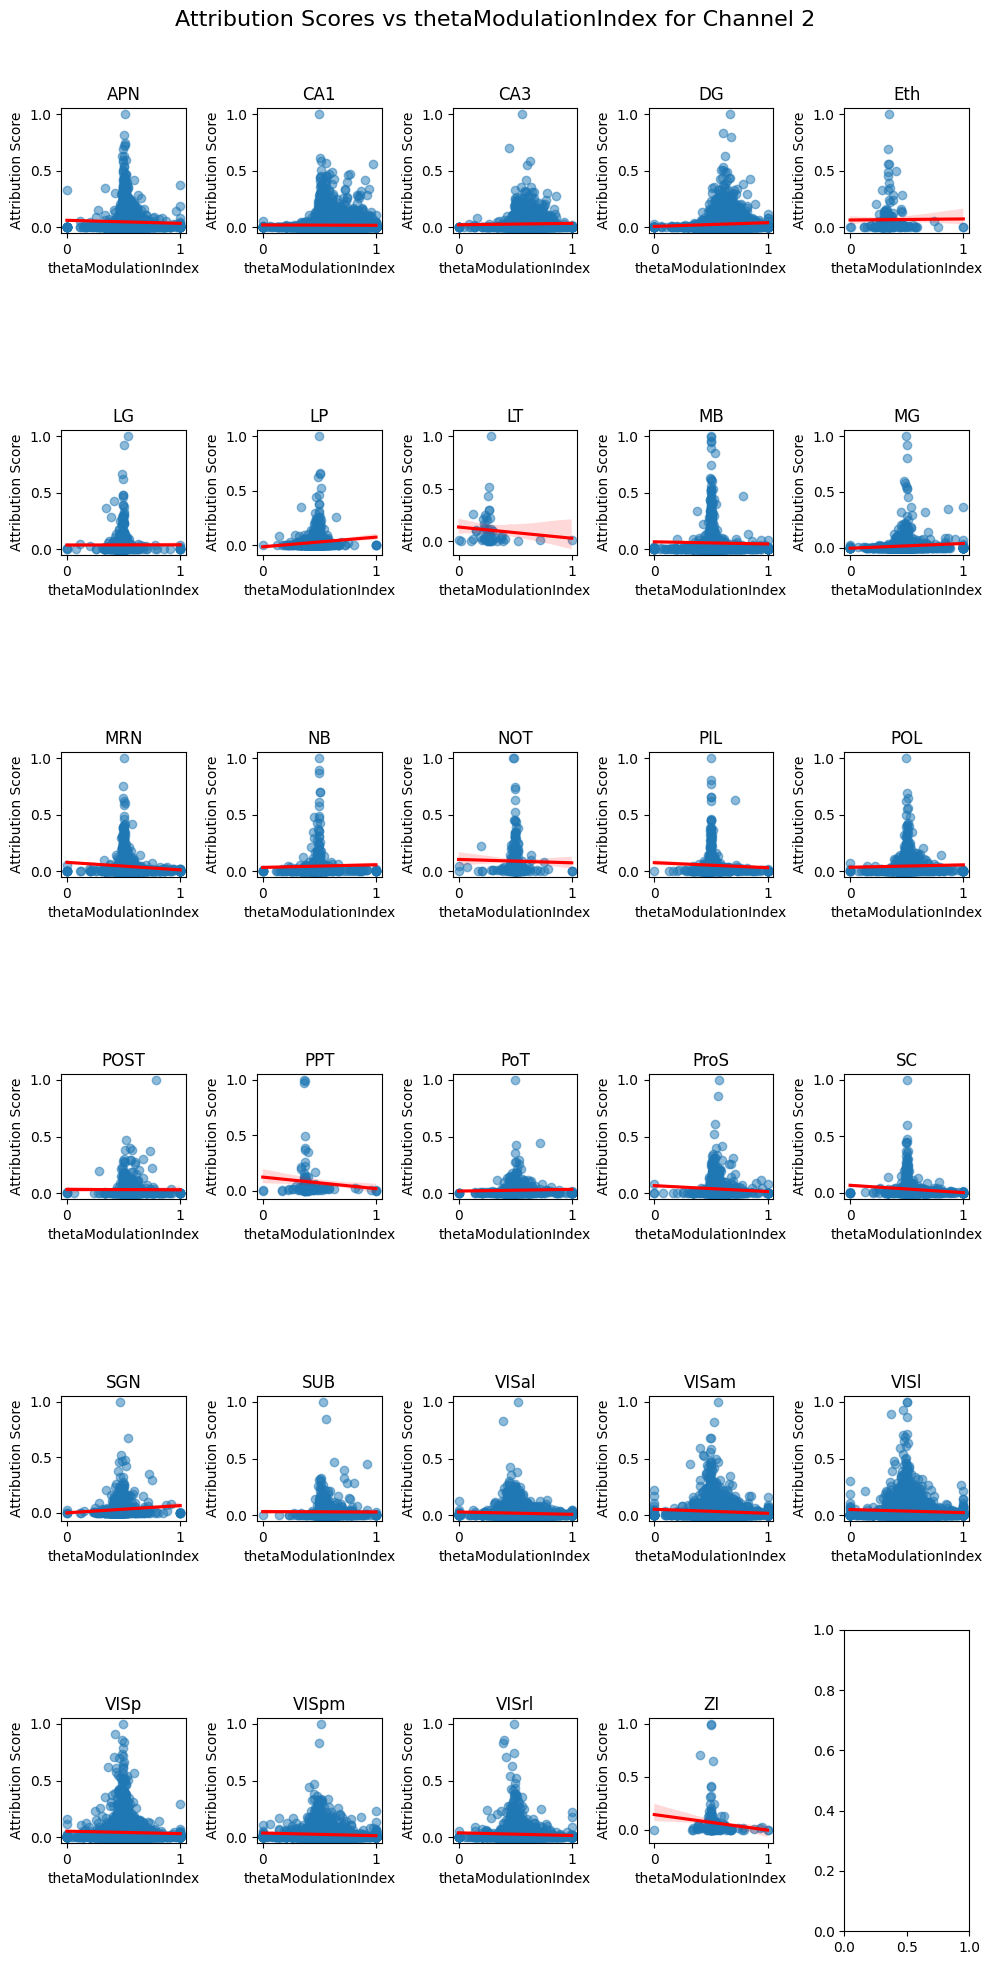

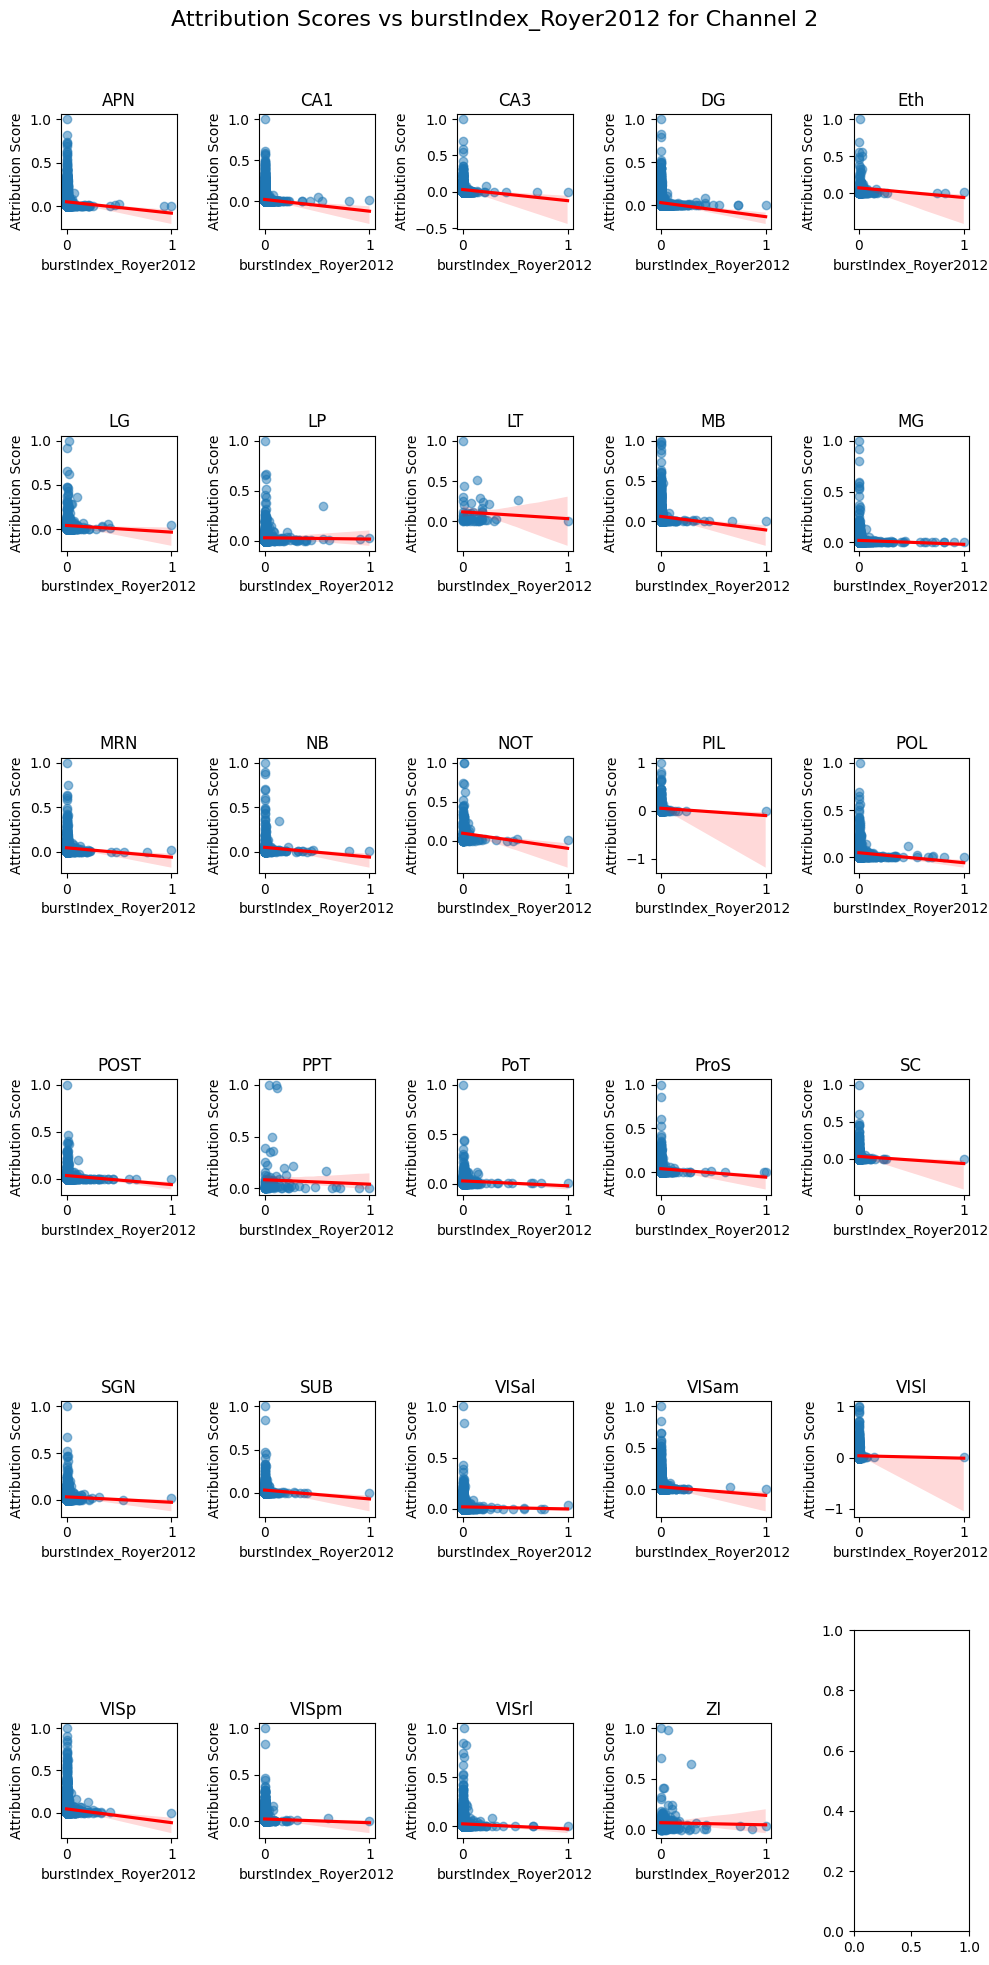

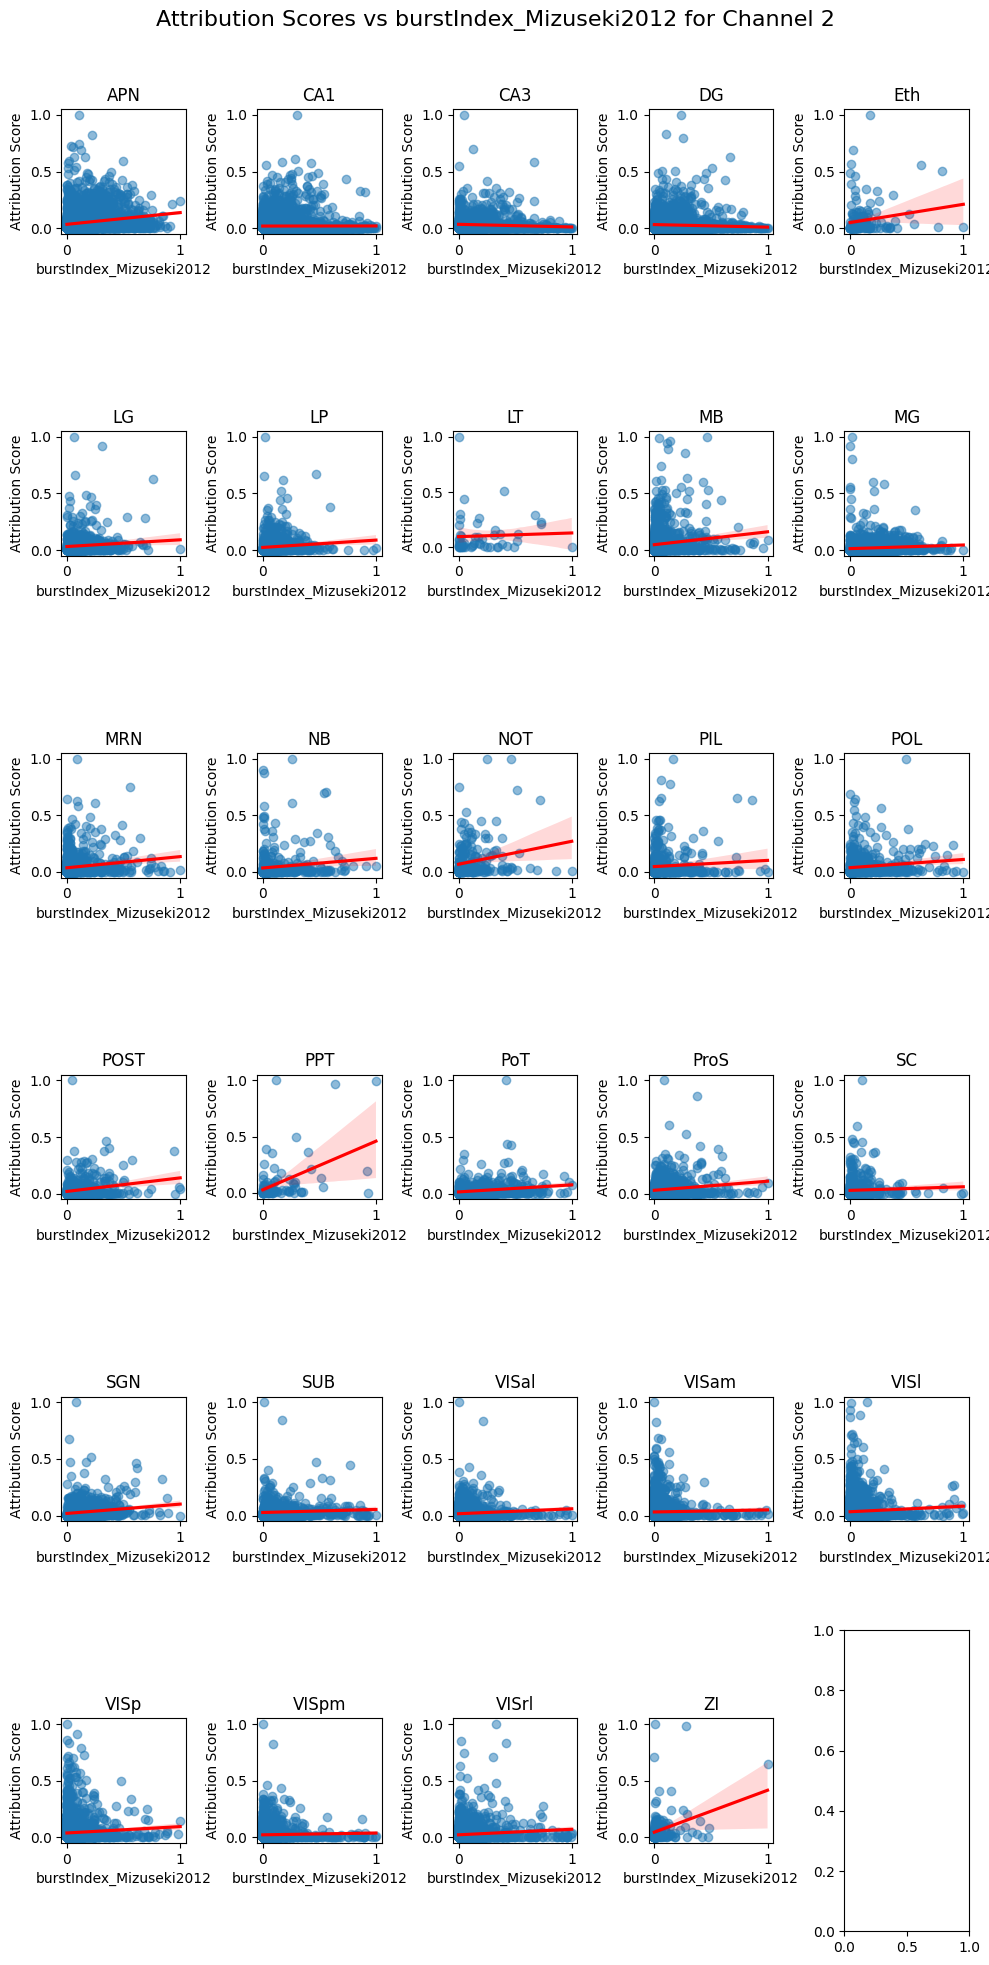

In [69]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

metrics = ['firing_rate', 'response_mag', 'sparsity', 'coupling_index', 'acg_tau_rise', 'acg_tau_decay','stLFP', 'stPR',
           'normalized_depth','cv2','firingRateISI','thetaModulationIndex','burstIndex_Royer2012','burstIndex_Mizuseki2012']

chani = 2
for metric in metrics:
    fig, ax = plt.subplots(int(np.ceil(len(unique_areas)/5)), 5, figsize=(10, 20))
    for i, regi in enumerate(unique_areas):
        regidx = df['structure_acronym'] == regi
        # get the attribution scores for the region, channel and band
        attr = np.abs(df.loc[regidx, f'attr_{chani}_{bandi}'].values)
        # get the metric values for the region
        metric_vals = df.loc[regidx, metric].values
        # remove NaN and infinite values from both arrays
        mask = (~np.isnan(attr)) & (~np.isnan(metric_vals)) & (~np.isinf(attr)) & (~np.isinf(metric_vals))
        attr = attr[mask]
        metric_vals = metric_vals[mask]
        
        if len(attr) == 0 or len(metric_vals) == 0:
            ax.flat[i].set_title(f'{regi}')
            ax.flat[i].set_xlabel(metric)
            ax.flat[i].set_ylabel('Attribution Score')
            ax.flat[i].set_aspect(1.0/ax.flat[i].get_data_ratio(), adjustable='box')
            continue
        
        # scale the metric values
        metric_vals_scaled = scaler.fit_transform(metric_vals.reshape(-1, 1)).flatten()
        # scale the attribution scores
        attr_scaled = scaler.fit_transform(attr.reshape(-1, 1)).flatten()
        
        sns.regplot(x=metric_vals_scaled, y=attr_scaled, ax=ax.flat[i], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
        ax.flat[i].set_title(f'{regi}')
        # add supertitle with the metric name
        ax.flat[i].set_xlabel(metric)
        ax.flat[i].set_ylabel('Attribution Score')
        ax.flat[i].set_aspect(1.0/ax.flat[i].get_data_ratio(), adjustable='box')
    
    # add a supertitle for the figure
    plt.suptitle(f'Attribution Scores vs {metric} for Channel {chani}', fontsize=16)
    plt.tight_layout()
    plt.show()
    

## Visual cortex correlations

For firing_rate: 25584 data points after filtering
Attr range: 0.00e+00 to 7.83e-02
Metric range: 1.00e-01 to 8.42e+01
After log filtering: 25544 data points
Correlation coefficient: 0.683, p-value: 0.00e+00


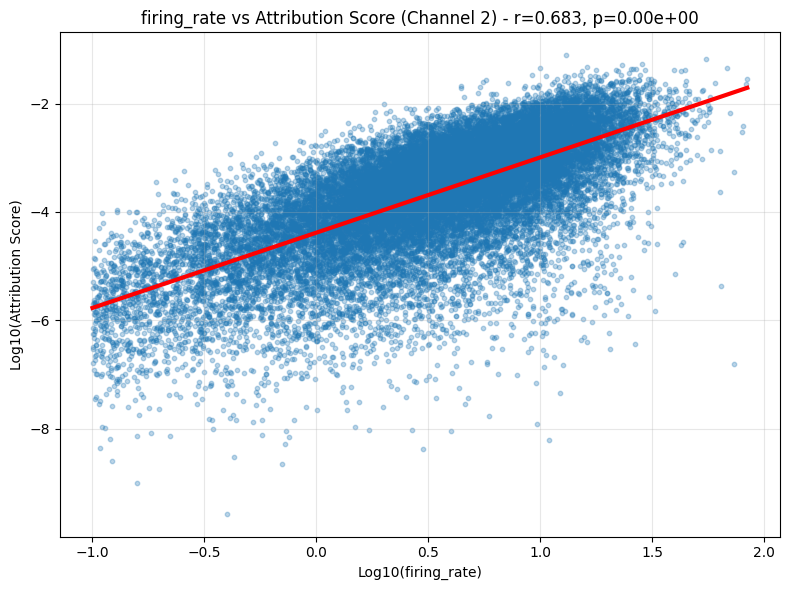

For firingRateISI: 25532 data points after filtering
Attr range: 0.00e+00 to 7.83e-02
Metric range: 8.29e-04 to 4.55e+02
After log filtering: 25492 data points
Correlation coefficient: 0.429, p-value: 0.00e+00


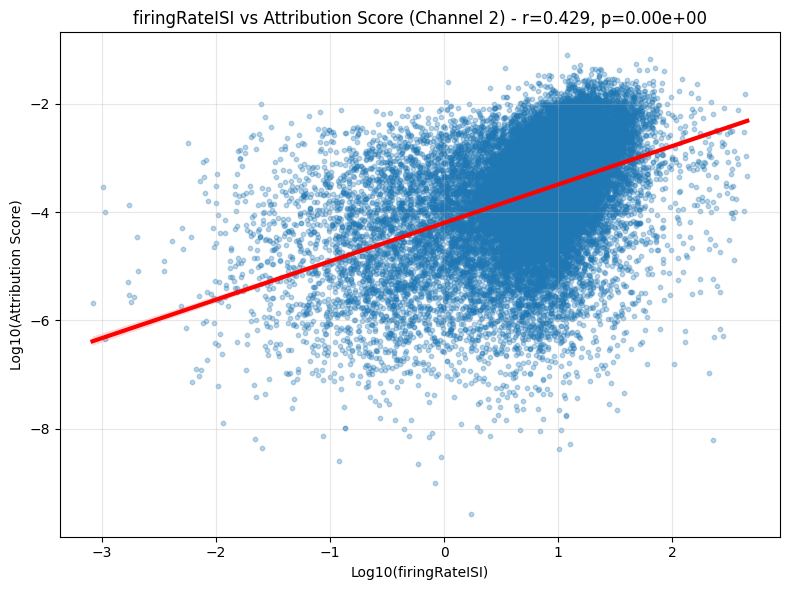

For cv2: 25472 data points after filtering
Attr range: 0.00e+00 to 7.83e-02
Metric range: 4.89e-02 to 1.94e+00
After filtering non-positive attribution values: 25432 data points
Correlation coefficient: -0.339, p-value: 0.00e+00


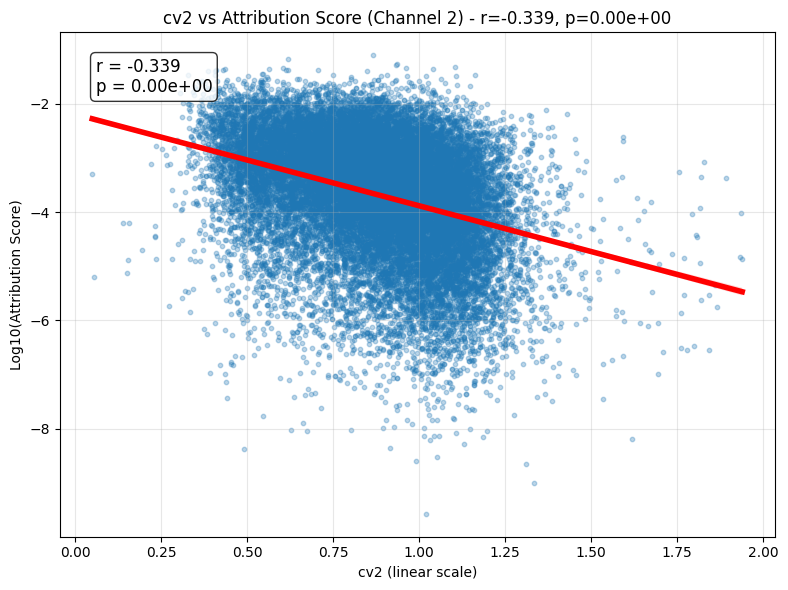

For burstIndex_Royer2012: 24417 data points after filtering
Attr range: 0.00e+00 to 7.83e-02
Metric range: 0.00e+00 to 4.75e+03
After log filtering: 16255 data points
Correlation coefficient: -0.249, p-value: 4.10e-228


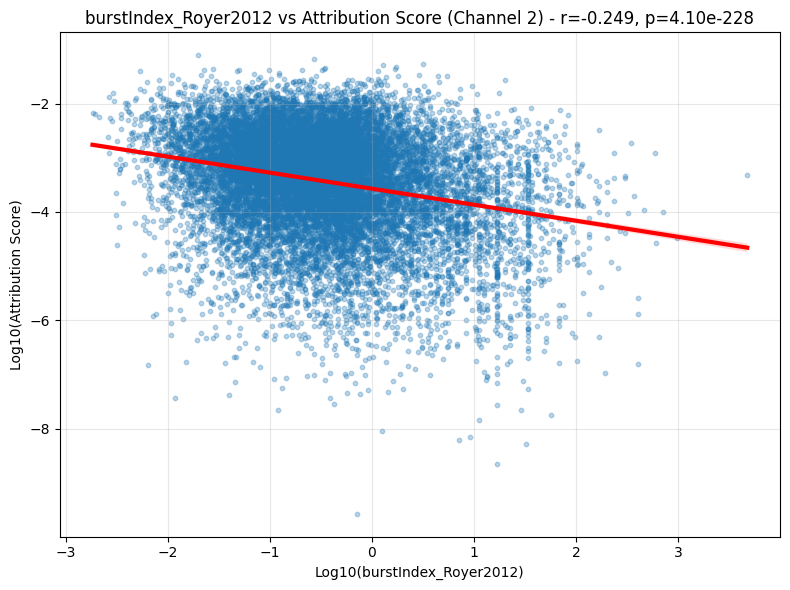

In [ ]:
# repeat the above scatter plots but for all neurons in VIS areas
# do this only for firing_rate, firingRateISI, cv2 and burstIndex_Royer2012
# this time don't scale the values 

metrics2 = ['firing_rate', 'firingRateISI', 'cv2', 'burstIndex_Royer2012']
vis_neurons = df[df['structure_acronym'].str.contains('VIS')]
chani = 2
for metric in metrics2:
    plt.figure(figsize=(8, 6))
    
    # get the attribution scores for the
    attr = np.abs(vis_neurons['attr_' + f'{chani}_0'].values)
    # get the metric values for the region
    metric_vals = vis_neurons[metric].values
    # remove NaN and infinite values from both arrays
    mask = (~np.isnan(attr)) & (~np.isnan(metric_vals)) & (~np.isinf(attr)) & (~np.isinf(metric_vals))
    attr = attr[mask]
    metric_vals = metric_vals[mask]
    
    print(f"For {metric}: {len(attr)} data points after filtering")
    if len(attr) == 0:
        print("No valid data points, skipping.")
        plt.close()
        continue
    print(f"Attr range: {np.min(attr):.2e} to {np.max(attr):.2e}")
    print(f"Metric range: {np.min(metric_vals):.2e} to {np.max(metric_vals):.2e}")
    
    from scipy.stats import pearsonr
    
    if metric == 'cv2':
        # For cv2 we want linear x and log y.
        # Remove non-positive attribution values to avoid -inf from log10.
        pos_mask = attr > 0
        attr_pos = attr[pos_mask]
        metric_pos = metric_vals[pos_mask]
        
        print(f"After filtering non-positive attribution values: {len(attr_pos)} data points")
        if len(attr_pos) == 0:
            print("No positive attribution values for log transform, skipping.")
            plt.close()
            continue
        
        log_attr = np.log10(attr_pos)
        # Also ensure metric_pos has no inf/nan (should be already handled by mask)
        finite_mask = (~np.isnan(metric_pos)) & (~np.isinf(metric_pos)) & (~np.isnan(log_attr)) & (~np.isinf(log_attr))
        metric_pos = metric_pos[finite_mask]
        log_attr = log_attr[finite_mask]
        
        if len(metric_pos) == 0:
            print("No finite data after filtering, skipping.")
            plt.close()
            continue
        
        sns.regplot(x=metric_pos, y=log_attr, 
                    scatter_kws={'alpha':0.3, 's':10}, 
                    line_kws={'color':'red', 'linewidth':4})  # Even thicker line for cv2
        
        # Calculate and print correlation coefficient (only if enough points)
        if len(metric_pos) > 2:
            corr, pval = pearsonr(metric_pos, log_attr)
            print(f"Correlation coefficient: {corr:.3f}, p-value: {pval:.2e}")
        else:
            corr, pval = np.nan, np.nan
            print("Not enough points for correlation.")
        
        plt.xlabel(f'{metric} (linear scale)')
        plt.ylabel('Log10(Attribution Score)')
        title_p = f' - r={corr:.3f}, p={pval:.2e}' if not np.isnan(corr) else ''
        plt.title(f'{metric} vs Attribution Score (Channel {chani}){title_p}')
        
        # Add text annotation with the correlation if available
        if not np.isnan(corr):
            plt.text(0.05, 0.95, f'r = {corr:.3f}\np = {pval:.2e}', 
                     transform=plt.gca().transAxes, fontsize=12, 
                     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        # Filter out values that can't be log-transformed
        log_mask = (metric_vals > 0) & (attr > 0)
        metric_vals_log = metric_vals[log_mask]
        attr_log = attr[log_mask]
        
        print(f"After log filtering: {len(attr_log)} data points")
        if len(attr_log) == 0:
            print("No data points left after log filtering, skipping.")
            plt.close()
            continue
        
        # Make sure no inf/nan remain
        finite_mask = (~np.isnan(metric_vals_log)) & (~np.isinf(metric_vals_log)) & (~np.isnan(attr_log)) & (~np.isinf(attr_log))
        metric_vals_log = metric_vals_log[finite_mask]
        attr_log = attr_log[finite_mask]
        if len(metric_vals_log) == 0:
            print("No finite data after filtering, skipping.")
            plt.close()
            continue
        
        sns.regplot(x=np.log10(metric_vals_log), y=np.log10(attr_log), 
                    scatter_kws={'alpha':0.3, 's':10}, 
                    line_kws={'color':'red', 'linewidth':3})
        
        # Calculate and print correlation coefficient (only if enough points)
        if len(metric_vals_log) > 2:
            corr, pval = pearsonr(np.log10(metric_vals_log), np.log10(attr_log))
            print(f"Correlation coefficient: {corr:.3f}, p-value: {pval:.2e}")
        else:
            corr, pval = np.nan, np.nan
            print("Not enough points for correlation.")
        
        plt.xlabel(f'Log10({metric})')
        plt.ylabel('Log10(Attribution Score)')
        title_p = f' - r={corr:.3f}, p={pval:.2e}' if not np.isnan(corr) else ''
        plt.title(f'{metric} vs Attribution Score (Channel {chani}){title_p}')
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(Path(figures_folder) / f'{metric}_vs_attribution_scores_VIS_channel_{chani}.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

## Train a decision tree model on one channel and band

In [99]:
# create a new dataframe with the columns from metrics plus structure_acronym and attribution_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import optuna 

# remove rows in df where structure_acronym is in areas2remove
df = df[~df['structure_acronym'].isin(areas2remove)]

encoder = OneHotEncoder(sparse_output=False)
structure_encoded = encoder.fit_transform(df[['structure_acronym']])

# # train a decision tree regressor on the attribution score and the metrics
X = np.hstack([structure_encoded, df[metrics + ['sst', 'vip']].values])
y = df['attr_8_0'].values

# Replace inf with nan
X[np.isinf(X)] = np.nan

# Remove rows with nan in X or y
valid_mask = (~np.isnan(X).any(axis=1)) & (~np.isnan(y)) & (~np.isinf(y))
X_clean = X[valid_mask]
y_clean = y[valid_mask]

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# Train a Random Forest Regressor with the hyperparameters from Optuna
def objective(trial):
    rf_model = RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 50, 200),
        max_depth=trial.suggest_int("max_depth", 5, 20),
        random_state=42,
        n_jobs=-1
    )
    
    train_data, valid_data, train_target, valid_target = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

    rf_model.fit(train_data, train_target)
    y_pred = rf_model.predict(valid_data)
    return r2_score(valid_target, y_pred)

study = optuna.create_study(direction='maximize')
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=100)
print("Best hyperparameters: ", study.best_params)
print("Best R2 score: ", study.best_value)
rf_model = RandomForestRegressor(
    n_estimators=study.best_params['n_estimators'],
    max_depth=study.best_params['max_depth'],
    n_jobs=-1
)

Best hyperparameters:  {'n_estimators': 196, 'max_depth': 16}
Best R2 score:  0.5075222803866288


## Plot feature importance

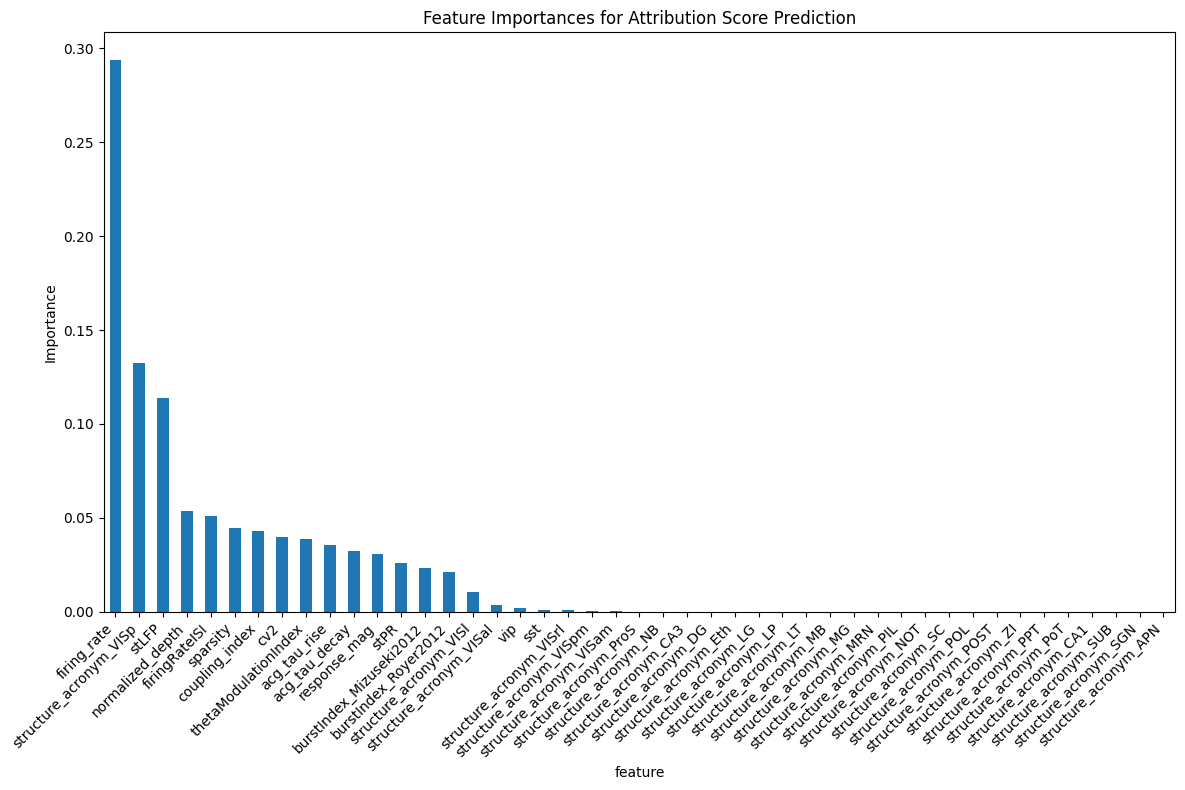

In [146]:
# regressor = DecisionTreeRegressor()
rf_model.fit(X_train, y_train)

# Evaluate the model
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'R^2 score of the regressor: {r2:.4f}')

# Get feature importances
importances = rf_model.feature_importances_
# Create a DataFrame for feature importances
feature_names = encoder.get_feature_names_out(['structure_acronym']) \
    .tolist() + metrics + ['sst', 'vip'] 
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Plot feature importances
fig, ax = plt.subplots(figsize=(12, 8))
importance_df.plot(kind='bar', x='feature', y='importance', ax=ax, legend=False)
ax.set_title('Feature Importances for Attribution Score Prediction')
ax.set_ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(Path(figures_folder) / 'feature_importances_attribution_score_prediction.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Repeat the above process for each channel and band 


In [ ]:
import tqdm
importance_df = pd.DataFrame({
    'feature': feature_names})
r2_df = pd.DataFrame(index=range(chans2keep), columns=[f'model_fit_{bandi}' for bandi in range(len(bands)+1)])

X = np.hstack([structure_encoded, df[metrics + ['sst', 'vip']].values])
X[np.isinf(X)] = np.nan

for bandi in tqdm.tqdm(range(len(bands)+1), desc='Processing Bands'):
    for chani in range(chans2keep):
        # get the attribution scores for the channel and band
        y = df[f'attr_{chani}_{bandi}'].values
        
        # Remove rows with nan in y
        valid_mask = (~np.isnan(X).any(axis=1)) & (~np.isnan(y)) & (~np.isinf(y))
        y_clean = y[valid_mask]
        X_clean = X[valid_mask]
        
        X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)
        study.optimize(objective, n_trials=20)
        rf_model = RandomForestRegressor(
            n_estimators=study.best_params['n_estimators'],
            max_depth=study.best_params['max_depth'],
            n_jobs=-1
        )
        rf_model.fit(X_train, y_train)
        # Evaluate the model
        y_pred = rf_model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        importances = rf_model.feature_importances_
        importance_df[f'importance_{chani}_{bandi}'] = importances
        r2_df.at[chani, f'model_fit_{bandi}'] = r2


Processing Bands: 100%|██████████| 9/9 [1:03:49<00:00, 425.51s/it]


## Plot the r2 scores of all channels and bands in a heatmap


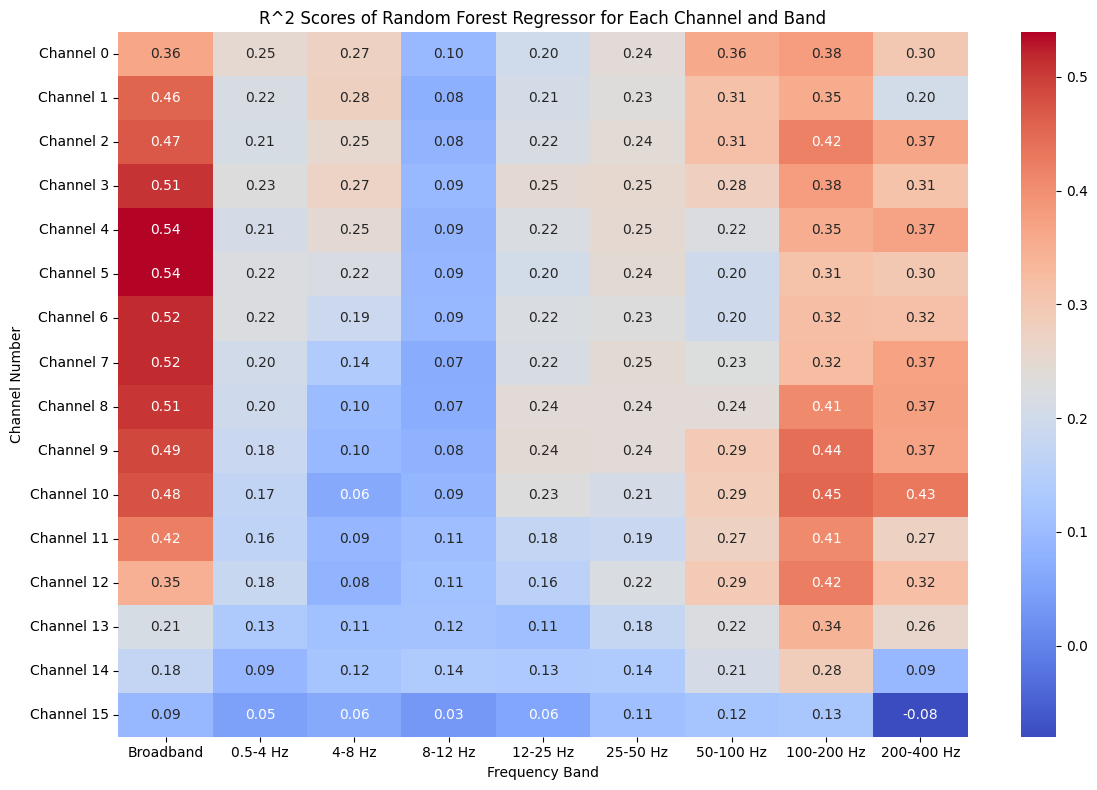

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
heatmap_data = r2_df.astype(float).values  # Convert to float
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='coolwarm', ax=ax,
           xticklabels=['Broadband'] + [f'{band[0]}-{band[1]} Hz' for band in bands] ,
           yticklabels=[f'Channel {i}' for i in range(chans2keep)])
ax.set_title('R^2 Scores of Random Forest Regressor for Each Channel and Band')
ax.set_xlabel('Frequency Band') 
ax.set_ylabel('Channel Number')
plt.tight_layout()
plt.show()

## Loop through the bands and plot the feature importances for all channels using a heatmap


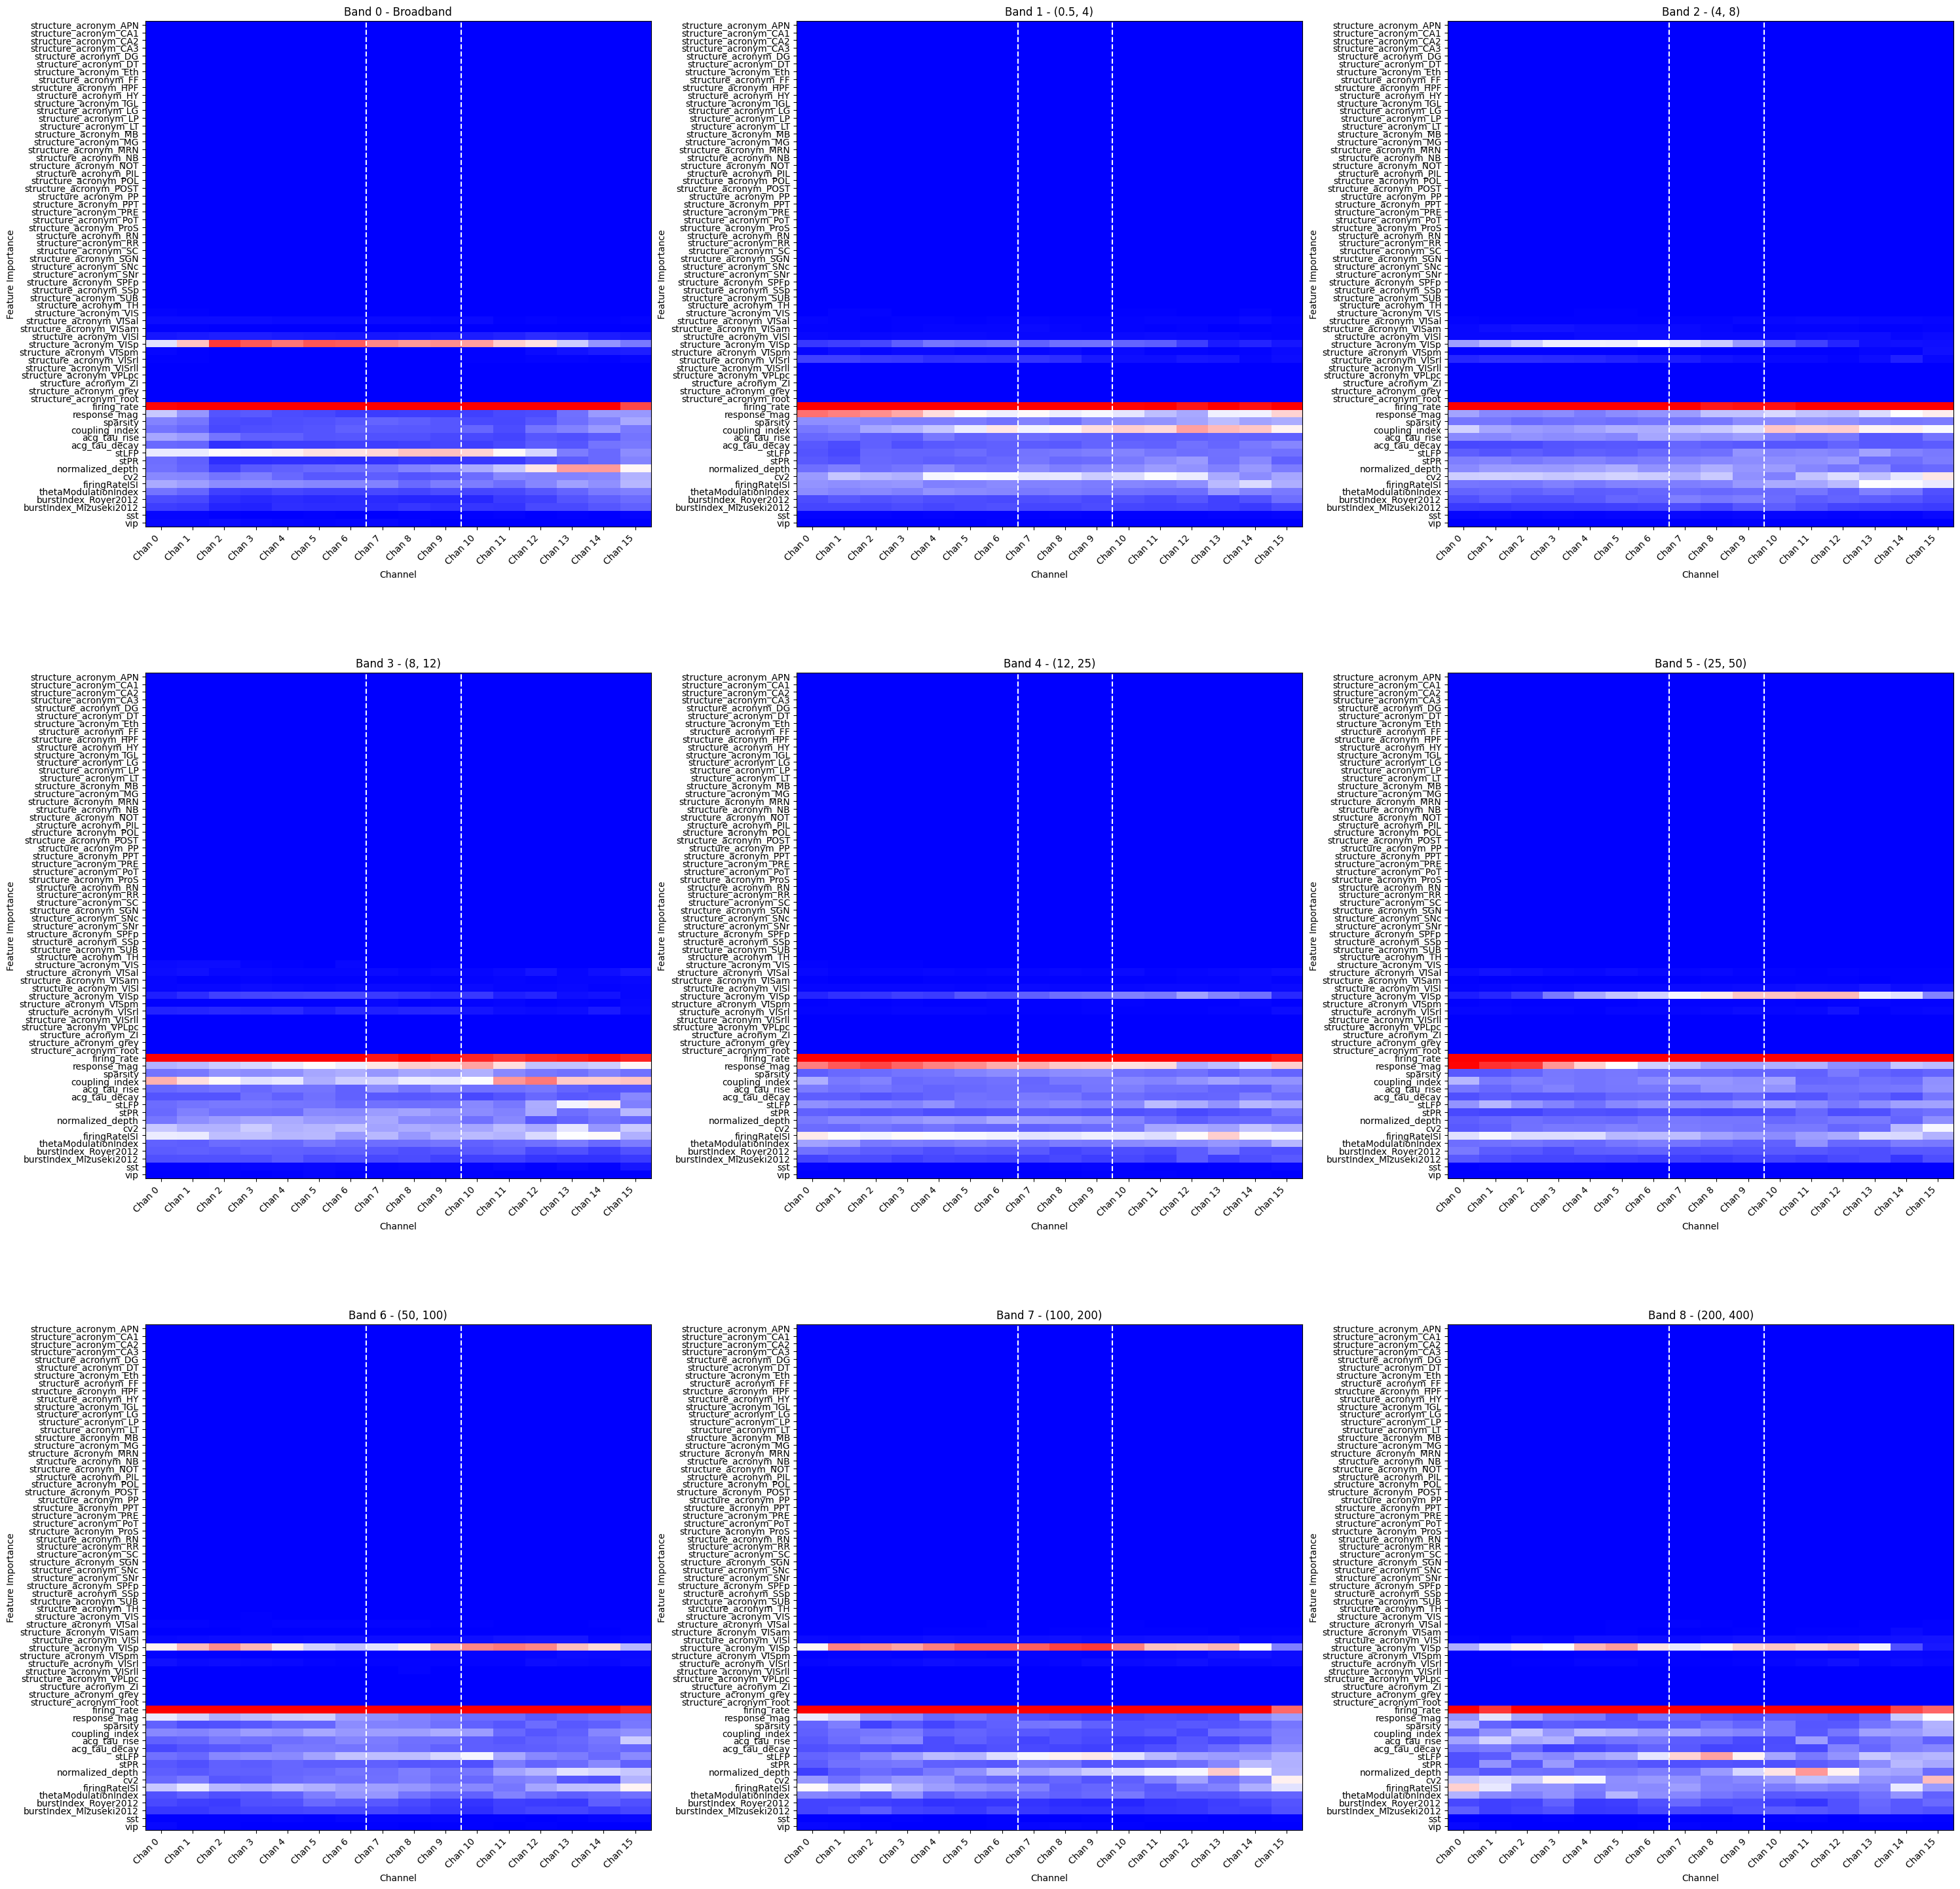

In [ ]:
fig, ax = plt.subplots(3,3, figsize=(30, 30))

for bandi in range(len(bands)+1):
    data = importance_df[[f'importance_{chani}_{bandi}' for chani in range(chans2keep)]].values
    ax.flat[bandi].imshow(data, aspect='auto', cmap='bwr', vmin = 0, vmax=.2)
    ax.flat[bandi].set_xticks(range(chans2keep))
    ax.flat[bandi].set_xticklabels([f'Chan {i}' for i in range(chans2keep)], rotation=45, ha='right')
    ax.flat[bandi].set_yticks(range(len(feature_names)))
    ax.flat[bandi].set_yticklabels(feature_names)
    ax.flat[bandi].set_title(f'Band {bandi} - {bands[bandi-1] if bandi > 0 else "Broadband"}')
    ax.flat[bandi].set_ylabel('Feature Importance')
    ax.flat[bandi].set_xlabel('Channel')
    ax.flat[bandi].set_aspect(1.0/ax.flat[bandi].get_data_ratio(), adjustable='box')
    ax.flat[bandi].axvline(x=6.5, color='w', linestyle='--')
    ax.flat[bandi].axvline(x=9.5, color='w', linestyle='--')

    
plt.tight_layout()
plt.show()